In [ ]:
# import sys
# import subprocess

# print("=== 🖥️ 1. 시스템 및 그래픽카드 정보 (nvidia-smi) ===")
# try:
#     # 윈도우에 설치된 NVIDIA 드라이버 정보 출력
#     result = subprocess.run(['nvidia-smi'], stdout=subprocess.PIPE, text=True)
#     print(result.stdout)
# except FileNotFoundError:
#     print("⚠️ nvidia-smi 명령어를 찾을 수 없습니다. NVIDIA 드라이버가 없거나 환경변수에 등록되지 않았습니다.")

# print("\n=== 🧠 2. 현재 파이썬 및 파이토치 환경 ===")
# print(f"Python 실행 경로: {sys.executable}")
# print(f"Python 버전: {sys.version.split(' ')[0]}")

# try:
#     import torch
#     print(f"\nPyTorch 패키지 위치: {torch.__file__}")
#     print(f"PyTorch 버전: {torch.__version__}")
#     print(f"PyTorch 내장 CUDA 버전: {torch.version.cuda}")
#     print(f"CUDA (GPU) 활성화 여부: {torch.cuda.is_available()}")
    
#     if torch.cuda.is_available():
#         print(f"사용 가능한 GPU: {torch.cuda.get_device_name(0)}")
#     else:
#         print("⚠️ 진단 결과: 현재 파이토치는 GPU를 인식하지 못하는 'CPU 전용 버전'입니다.")
# except ImportError:
#     print("\n⚠️ 현재 환경에 파이토치(torch)가 설치되어 있지 않습니다.")

### **쿠다 설치 위치 확인**
* 만약 쿠다 설치가 잘못되었다고 생각되면 위에 셀을 통해서 위치랑 실행 위치 확인하기
* 다시 설치후, VSCODE 재실행

In [1]:
# scipy.ndimage.median_filter
import os
import yaml
import numpy as np
import cv2
import pyrealsense2 as rs
import matplotlib.pyplot as plt
import pprint
import open3d as o3d
from sklearn.cluster import DBSCAN
from ultralytics import YOLO
import torch

import INUVisionLib as ivl

print("\n라이브러리 로드")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.

라이브러리 로드


<hr style="height: 5px; background-color: #39FF14; border: none;">

# **현재 RealSense 모든 설정 출력 코드 = 장치가 지원하는 전체 옵션**

In [1]:
import pyrealsense2 as rs
import json
from datetime import datetime
from pathlib import Path


def safe_call(fn, default=None):
    try:
        return fn()
    except Exception as e:
        return f"[ERROR] {type(e).__name__}: {e}" if default is None else default


def rs_info_name(info_enum):
    try:
        return str(info_enum).split(".")[-1]
    except Exception:
        return str(info_enum)


def rs_option_name(opt):
    try:
        return str(opt).split(".")[-1]
    except Exception:
        return str(opt)


def dump_realsense_all_settings(output_dir="realsense_settings_dump"):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    ctx = rs.context()
    devices = ctx.query_devices()

    dump = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "device_count": len(devices),
        "devices": []
    }

    if len(devices) == 0:
        print("[ERROR] No RealSense device found.")
        return dump

    for dev_idx, dev in enumerate(devices):
        print(f"\n================ DEVICE {dev_idx} ================")

        dev_info = {}
        for info in [
            rs.camera_info.name,
            rs.camera_info.serial_number,
            rs.camera_info.firmware_version,
            rs.camera_info.recommended_firmware_version,
            rs.camera_info.physical_port,
            rs.camera_info.product_id,
            rs.camera_info.product_line,
            rs.camera_info.usb_type_descriptor,
        ]:
            key = rs_info_name(info)
            if dev.supports(info):
                val = dev.get_info(info)
            else:
                val = None
            dev_info[key] = val
            print(f"{key:30s}: {val}")

        # Advanced mode JSON
        advanced_json = None
        try:
            adv = rs.rs400_advanced_mode(dev)
            adv_enabled = adv.is_enabled()
            dev_info["advanced_mode_enabled"] = adv_enabled
            print(f"{'advanced_mode_enabled':30s}: {adv_enabled}")

            if adv_enabled:
                advanced_json = adv.serialize_json()
                adv_path = output_dir / f"device_{dev_idx}_advanced_mode.json"
                adv_path.write_text(advanced_json, encoding="utf-8")
                print(f"[SAVE] Advanced mode JSON -> {adv_path}")
            else:
                print("[INFO] Advanced mode is disabled. Enable it in Viewer or with code if needed.")

        except Exception as e:
            dev_info["advanced_mode_error"] = f"{type(e).__name__}: {e}"
            print(f"[WARN] Advanced mode dump failed: {e}")

        sensors_dump = []

        for sensor_idx, sensor in enumerate(dev.query_sensors()):
            sensor_name = safe_call(lambda: sensor.get_info(rs.camera_info.name), f"sensor_{sensor_idx}")
            print(f"\n------------ SENSOR {sensor_idx}: {sensor_name} ------------")

            sensor_dump = {
                "sensor_index": sensor_idx,
                "sensor_name": sensor_name,
                "options": {},
                "stream_profiles": []
            }

            # sensor options
            supported_options = sensor.get_supported_options()

            for opt in supported_options:
                opt_key = rs_option_name(opt)

                opt_data = {
                    "current_value": None,
                    "description": None,
                    "range": None,
                    "value_descriptions": {}
                }

                opt_data["current_value"] = safe_call(lambda opt=opt: sensor.get_option(opt))
                opt_data["description"] = safe_call(lambda opt=opt: sensor.get_option_description(opt))

                rng = safe_call(lambda opt=opt: sensor.get_option_range(opt))
                if not isinstance(rng, str) and rng is not None:
                    opt_data["range"] = {
                        "min": rng.min,
                        "max": rng.max,
                        "step": rng.step,
                        "default": rng.default
                    }

                    # visual_preset 같은 enum형 option은 값 설명도 출력
                    if abs(rng.step - 1.0) < 1e-9 and (rng.max - rng.min) <= 30:
                        for v in range(int(rng.min), int(rng.max) + 1):
                            desc = safe_call(
                                lambda opt=opt, v=v: sensor.get_option_value_description(opt, float(v)),
                                default=""
                            )
                            if desc:
                                opt_data["value_descriptions"][str(v)] = desc

                sensor_dump["options"][opt_key] = opt_data

                cur = opt_data["current_value"]
                rr = opt_data["range"]
                descs = opt_data["value_descriptions"]

                if rr:
                    print(
                        f"{opt_key:35s} "
                        f"cur={cur} | min={rr['min']} max={rr['max']} "
                        f"step={rr['step']} default={rr['default']}"
                    )
                else:
                    print(f"{opt_key:35s} cur={cur}")

                if descs:
                    print("    value descriptions:")
                    for k, v in descs.items():
                        print(f"      {k}: {v}")

            # stream profiles
            print("\n[Stream Profiles]")
            profiles = safe_call(lambda: sensor.get_stream_profiles(), default=[])

            for p in profiles:
                p_info = {
                    "stream_type": str(p.stream_type()).split(".")[-1],
                    "format": str(p.format()).split(".")[-1],
                    "fps": p.fps(),
                    "is_video_profile": False
                }

                try:
                    vp = p.as_video_stream_profile()
                    p_info.update({
                        "is_video_profile": True,
                        "width": vp.width(),
                        "height": vp.height(),
                        "intrinsics": None
                    })

                    try:
                        intr = vp.get_intrinsics()
                        p_info["intrinsics"] = {
                            "width": intr.width,
                            "height": intr.height,
                            "fx": intr.fx,
                            "fy": intr.fy,
                            "ppx": intr.ppx,
                            "ppy": intr.ppy,
                            "model": str(intr.model),
                            "coeffs": list(intr.coeffs)
                        }
                    except Exception:
                        pass

                    print(
                        f"  {p_info['stream_type']:12s} "
                        f"{p_info['format']:8s} "
                        f"{p_info['width']}x{p_info['height']} @ {p_info['fps']}fps"
                    )

                except Exception:
                    print(
                        f"  {p_info['stream_type']:12s} "
                        f"{p_info['format']:8s} @ {p_info['fps']}fps"
                    )

                sensor_dump["stream_profiles"].append(p_info)

            sensors_dump.append(sensor_dump)

        dev_info["sensors"] = sensors_dump
        if advanced_json is not None:
            dev_info["advanced_mode_json_saved"] = str(output_dir / f"device_{dev_idx}_advanced_mode.json")

        dump["devices"].append(dev_info)

    out_path = output_dir / "realsense_all_settings.json"
    out_path.write_text(json.dumps(dump, indent=2, ensure_ascii=False), encoding="utf-8")

    print(f"\n================ DONE ================")
    print(f"[SAVE] All settings JSON -> {out_path}")

    return dump


settings = dump_realsense_all_settings()


================ DEVICE 0 ================
name                          : Intel RealSense D435IF
serial_number                 : 327122072783
firmware_version              : 5.17.0.10
recommended_firmware_version  : 5.17.0.10
physical_port                 : \\?\usb#vid_8086&pid_0b3a&mi_00#9&318fd29f&0&0000#{e5323777-f976-4f5b-9b55-b94699c46e44}\global
product_id                    : 0B3A
product_line                  : D400
usb_type_descriptor           : 3.2
advanced_mode_enabled         : True
[SAVE] Advanced mode JSON -> realsense_settings_dump\device_0_advanced_mode.json

------------ SENSOR 0: Stereo Module ------------
Exposure                            cur=80000.0 | min=1.0 max=165000.0 step=1.0 default=8500.0
Gain                                cur=16.0 | min=16.0 max=248.0 step=1.0 default=16.0
Enable Auto Exposure                cur=0.0 | min=0.0 max=1.0 step=1.0 default=1.0
Visual Preset                       cur=0.0 | min=0.0 max=5.0 step=1.0 default=0.0
    value descri

# **실제로 네가 켠 stream이 뭔지 확인**

In [7]:
import pyrealsense2 as rs
import json

pipeline = rs.pipeline()
config = rs.config()

# 네가 실제로 쓰는 설정으로 바꿔도 됨
config.enable_stream(rs.stream.depth, 848, 480, rs.format.z16, 30)
config.enable_stream(rs.stream.color, 848, 480, rs.format.bgr8, 30)

profile = pipeline.start(config)

try:
    print("\n[ACTIVE STREAMS]")
    for sp in profile.get_streams():
        vsp = sp.as_video_stream_profile()
        intr = vsp.get_intrinsics()

        print("--------------------------------")
        print("stream :", sp.stream_type())
        print("format :", sp.format())
        print("fps    :", sp.fps())
        print("size   :", vsp.width(), "x", vsp.height())
        print("fx, fy :", intr.fx, intr.fy)
        print("ppx,ppy:", intr.ppx, intr.ppy)
        print("model  :", intr.model)
        print("coeffs :", intr.coeffs)

    dev = profile.get_device()
    depth_sensor = dev.first_depth_sensor()

    print("\n[DEPTH SCALE]")
    print(depth_sensor.get_depth_scale())

    print("\n[DEPTH SENSOR CURRENT OPTIONS]")
    for opt in depth_sensor.get_supported_options():
        name = str(opt).split(".")[-1]
        val = depth_sensor.get_option(opt)
        print(f"{name:35s}: {val}")

finally:
    pipeline.stop()


[ACTIVE STREAMS]
--------------------------------
stream : stream.depth
format : format.z16
fps    : 30
size   : 848 x 480
fx, fy : 425.64202880859375 425.64202880859375
ppx,ppy: 429.978271484375 243.2578582763672
model  : distortion.brown_conrady
coeffs : [0.0, 0.0, 0.0, 0.0, 0.0]
--------------------------------
stream : stream.color
format : format.bgr8
fps    : 30
size   : 848 x 480
fx, fy : 606.1939697265625 606.0857543945312
ppx,ppy: 433.0955810546875 247.07073974609375
model  : distortion.inverse_brown_conrady
coeffs : [0.0, 0.0, 0.0, 0.0, 0.0]

[DEPTH SCALE]
9.999999747378752e-06

[DEPTH SENSOR CURRENT OPTIONS]
Exposure                           : 18103.0
Gain                               : 16.0
Enable Auto Exposure               : 1.0
Visual Preset                      : 0.0
Laser Power                        : 150.0
Emitter Enabled                    : 1.0
Frames Queue Size                  : 16.0
Asic Temperature                   : 47.0
Error Polling Enabled              

# **후처리 필터 설정값도 같이 출력하는 코드**

In [3]:
import pyrealsense2 as rs


def print_filter_options(filter_obj, name):
    print(f"\n========== FILTER: {name} ==========")

    for opt in filter_obj.get_supported_options():
        opt_name = str(opt).split(".")[-1]

        try:
            val = filter_obj.get_option(opt)
        except Exception as e:
            val = f"[ERROR] {e}"

        try:
            rng = filter_obj.get_option_range(opt)
            print(
                f"{opt_name:35s} "
                f"cur={val} | min={rng.min} max={rng.max} step={rng.step} default={rng.default}"
            )
        except Exception:
            print(f"{opt_name:35s} cur={val}")

        try:
            desc = filter_obj.get_option_description(opt)
            if desc:
                print(f"    desc: {desc}")
        except Exception:
            pass


decimation = rs.decimation_filter()
spatial = rs.spatial_filter()
temporal = rs.temporal_filter()
hole_filling = rs.hole_filling_filter()
disparity = rs.disparity_transform(True)
depth_back = rs.disparity_transform(False)

print_filter_options(decimation, "decimation_filter")
print_filter_options(spatial, "spatial_filter")
print_filter_options(temporal, "temporal_filter")
print_filter_options(hole_filling, "hole_filling_filter")
print_filter_options(disparity, "disparity_transform_true")
print_filter_options(depth_back, "disparity_transform_false")


========== FILTER: decimation_filter ==========
Frames Queue Size                   cur=16.0 | min=0.0 max=32.0 step=1.0 default=16.0
    desc: Max number of frames you can hold at a given time. Increasing this number will reduce frame drops but increase latency, and vice versa
Filter Magnitude                    cur=2.0 | min=1.0 max=8.0 step=1.0 default=2.0
    desc: Decimation scale
Stream Filter                       cur=1.0 | min=0.0 max=11.0 step=1.0 default=0.0
    desc: Stream type
Stream Format Filter                cur=1.0 | min=0.0 max=34.0 step=1.0 default=0.0
    desc: Stream format
Stream Index Filter                 cur=-1.0 | min=-1.0 max=16.0 step=1.0 default=-1.0
    desc: Stream index

========== FILTER: spatial_filter ==========
Frames Queue Size                   cur=16.0 | min=0.0 max=32.0 step=1.0 default=16.0
    desc: Max number of frames you can hold at a given time. Increasing this number will reduce frame drops but increase latency, and vice versa
Filter Ma

# **센서 설정**

In [4]:
import pyrealsense2 as rs

decimation = rs.decimation_filter()
spatial = rs.spatial_filter()
temporal = rs.temporal_filter()
hole_filling = rs.hole_filling_filter()

disparity = rs.disparity_transform(True)
depth_back = rs.disparity_transform(False)

# Decimation
decimation.set_option(rs.option.filter_magnitude, 1)
# 1: 거의 원본 유지
# 2: 계산량 감소 + 약간 안정화

# Spatial Filter - 직각 보존용 약한 설정
spatial.set_option(rs.option.filter_magnitude, 1)
spatial.set_option(rs.option.filter_smooth_alpha, 0.75)
spatial.set_option(rs.option.filter_smooth_delta, 12)
spatial.set_option(rs.option.holes_fill, 0)

# Temporal Filter
temporal.set_option(rs.option.filter_smooth_alpha, 0.4)
temporal.set_option(rs.option.filter_smooth_delta, 20)

# persistence_control이 지원되는 경우에만
try:
    temporal.set_option(rs.option.persistence_control, 0)
except Exception:
    pass

# Hole filling은 처음에는 아예 빼고 테스트 추천
use_hole_filling = False


def process_depth_frame(depth_frame):
    frame = depth_frame

    frame = decimation.process(frame)
    frame = disparity.process(frame)
    frame = spatial.process(frame)
    frame = temporal.process(frame)
    frame = depth_back.process(frame)

    if use_hole_filling:
        frame = hole_filling.process(frame)

    return frame

---

# **시작**

In [61]:
import pyrealsense2 as rs
import numpy as np
import cv2
import matplotlib.pyplot as plt
import json
from pathlib import Path
import time
import pprint


# ============================================================
# 0. 사용자 설정
# ============================================================

CONFIG = {
    # RealSense Viewer에서 저장한 Advanced Mode JSON 경로
    # 사용하지 않으려면 None
    # "advanced_json_path": None,
    # 예: "camset.json"
    # "advanced_json_path": "camset.json",
    "advanced_json_path": "view_short.json",

    # 스트림 설정
    "depth_width": 848,
    "depth_height": 480,
    "depth_fps": 30,

    # color는 BGR8 640x480이 가장 무난함
    # align_to_color를 하면 aligned_depth도 color 해상도인 640x480이 됨
    "color_width": 640,
    "color_height": 480,
    "color_fps": 30,

    # 카메라 직접 설정
    "use_depth_auto_exposure": True,
    "depth_exposure_us": 18000,   # auto exposure OFF일 때만 의미 있음
    "depth_gain": 16,

    "emitter_enabled": 1,         # 0=off, 1=laser on, 2=auto
    "laser_power": 150,

    # Depth Units
    # 0.001   = 1mm/count, 기본 안정값
    # 0.0001  = 0.1mm/count, 근거리 타협값
    # 0.00001 = 0.01mm/count, 65cm 근거리 강제 느낌
    "depth_units_m": 0.00001,

    # ROI 기반 Auto Exposure 영역
    # depth stream 기준 픽셀 좌표
    # None이면 중앙 ROI 자동 생성
    "depth_ae_roi": None,
    # 예:
    # "depth_ae_roi": {"min_x": 180, "min_y": 120, "max_x": 680, "max_y": 420},

    # 중앙 ROI 비율
    "roi_ratio_x": 0.55,
    "roi_ratio_y": 0.65,

    # Color 설정
    "use_color_auto_exposure": True,
    "use_color_auto_white_balance": True,

    # Pre-process filter ON/OFF
    "enable_threshold": True,
    "threshold_min_m": 0.15,
    "threshold_max_m": 0.60,

    "enable_disparity_spatial": False,
    "enable_temporal": False,
    "enable_hole_filling": True,

    # Spatial Filter 설정
    # 직각/얇은 엣지 보존 목적이면 약하게
    "spatial_magnitude": 1,
    "spatial_alpha": 0.85,
    "spatial_delta": 8,
    "spatial_holes_fill": 0,

    # Temporal Filter 설정
    "temporal_alpha": 0.7,
    "temporal_delta": 10,
    "temporal_persistency": 0,

    # Hole Filling 설정
    # 0,1,2 중 선택. 보통 1부터
    "hole_filling_mode": 1,

    # warmup frame
    "warmup_frames": 30,
}


def print_title(title):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)


def set_option_if_supported(sensor, option, value, name=None):
    name = name or str(option)
    try:
        if sensor.supports(option):
            sensor.set_option(option, float(value))
            print(f"[SET] {name}: {value}")
        else:
            print(f"[SKIP] {name}: not supported")
    except Exception as e:
        print(f"[ERROR] {name}: {e}")


def get_sensor_by_name(device, keyword):
    keyword = keyword.lower()
    for sensor in device.query_sensors():
        try:
            name = sensor.get_info(rs.camera_info.name).lower()
        except Exception:
            name = ""
        if keyword in name:
            return sensor
    return None


def make_center_roi(width, height, ratio_x=0.55, ratio_y=0.65):
    roi_w = int(width * ratio_x)
    roi_h = int(height * ratio_y)
    x0 = (width - roi_w) // 2
    y0 = (height - roi_h) // 2
    x1 = x0 + roi_w
    y1 = y0 + roi_h
    return {
        "min_x": x0,
        "min_y": y0,
        "max_x": x1,
        "max_y": y1,
    }


def clean_advanced_json_for_device(json_path):
    """
    RealSense Viewer 저장 JSON 중 device/parameters/schema version만 남긴다.
    filters, viewer 같은 키가 있으면 rs2_load_json에서 에러날 수 있음.
    """
    json_path = Path(json_path)
    data = json.loads(json_path.read_text(encoding="utf-8"))

    cleaned = {}
    if "device" in data:
        cleaned["device"] = data["device"]
    if "parameters" in data:
        cleaned["parameters"] = data["parameters"]
    if "schema version" in data:
        cleaned["schema version"] = data["schema version"]
    else:
        cleaned["schema version"] = 1

    return json.dumps(cleaned, indent=4)


def intrinsics_to_dict(intr):
    return {
        "width": intr.width,
        "height": intr.height,
        "fx": intr.fx,
        "fy": intr.fy,
        "ppx": intr.ppx,
        "ppy": intr.ppy,
        "model": str(intr.model),
        "coeffs": list(intr.coeffs),
    }

In [62]:
# ============================================================
# 1. 카메라 시작 및 설정 적용
# ============================================================

print_title("START REALSENSE")

pipeline = rs.pipeline()
config = rs.config()

config.enable_stream(
    rs.stream.depth,
    CONFIG["depth_width"],
    CONFIG["depth_height"],
    rs.format.z16,
    CONFIG["depth_fps"],
)

config.enable_stream(
    rs.stream.color,
    CONFIG["color_width"],
    CONFIG["color_height"],
    rs.format.bgr8,
    CONFIG["color_fps"],
)

# ------------------------------------------------------------
# Advanced JSON 로드
# pipeline start 전에 장치에 직접 로드
# ------------------------------------------------------------
ctx = rs.context()
devices = ctx.query_devices()

if len(devices) == 0:
    raise RuntimeError("RealSense device not found.")

device_for_json = devices[0]

if CONFIG["advanced_json_path"] is not None:
    json_path = Path(CONFIG["advanced_json_path"])
    if json_path.exists():
        print(f"[LOAD JSON] {json_path}")
        adv = rs.rs400_advanced_mode(device_for_json)
        cleaned_json = clean_advanced_json_for_device(json_path)
        adv.load_json(cleaned_json)
        time.sleep(1.0)
        print("[OK] Advanced Mode JSON loaded.")
    else:
        print(f"[WARN] JSON path not found: {json_path}")

# ------------------------------------------------------------
# pipeline start
# ------------------------------------------------------------
profile = pipeline.start(config)
device = profile.get_device()

depth_sensor = device.first_depth_sensor()
stereo_sensor = get_sensor_by_name(device, "stereo")
color_sensor = get_sensor_by_name(device, "rgb")

if stereo_sensor is None:
    stereo_sensor = depth_sensor

print("\n[DEVICE INFO]")
for info in [
    rs.camera_info.name,
    rs.camera_info.serial_number,
    rs.camera_info.firmware_version,
    rs.camera_info.usb_type_descriptor,
]:
    if device.supports(info):
        print(f"{str(info):35s}: {device.get_info(info)}")

# ------------------------------------------------------------
# Depth 카메라 직접 설정
# ------------------------------------------------------------
print_title("APPLY DEPTH CAMERA SETTINGS")

set_option_if_supported(
    depth_sensor,
    rs.option.enable_auto_exposure,
    1 if CONFIG["use_depth_auto_exposure"] else 0,
    "depth enable_auto_exposure",
)

if not CONFIG["use_depth_auto_exposure"]:
    set_option_if_supported(
        depth_sensor,
        rs.option.exposure,
        CONFIG["depth_exposure_us"],
        "depth exposure_us",
    )

set_option_if_supported(
    depth_sensor,
    rs.option.gain,
    CONFIG["depth_gain"],
    "depth gain",
)

set_option_if_supported(
    depth_sensor,
    rs.option.emitter_enabled,
    CONFIG["emitter_enabled"],
    "emitter_enabled",
)

set_option_if_supported(
    depth_sensor,
    rs.option.laser_power,
    CONFIG["laser_power"],
    "laser_power",
)

set_option_if_supported(
    depth_sensor,
    rs.option.depth_units,
    CONFIG["depth_units_m"],
    "depth_units_m",
)

# ------------------------------------------------------------
# ROI 기반 Auto Exposure 설정
# ------------------------------------------------------------
print_title("APPLY DEPTH AUTO EXPOSURE ROI")

depth_roi = CONFIG["depth_ae_roi"]

if depth_roi is None:
    depth_roi = make_center_roi(
        CONFIG["depth_width"],
        CONFIG["depth_height"],
        CONFIG["roi_ratio_x"],
        CONFIG["roi_ratio_y"],
    )

print("[ROI]", depth_roi)

try:
    roi_sensor = stereo_sensor.as_roi_sensor()

    roi = rs.region_of_interest()
    roi.min_x = int(depth_roi["min_x"])
    roi.min_y = int(depth_roi["min_y"])
    roi.max_x = int(depth_roi["max_x"])
    roi.max_y = int(depth_roi["max_y"])

    roi_sensor.set_region_of_interest(roi)
    print("[OK] Depth Auto Exposure ROI applied.")

except Exception as e:
    print("[WARN] ROI setting failed.")
    print(e)

# ------------------------------------------------------------
# Color 설정
# 화이트밸런스는 자동 유지
# ------------------------------------------------------------
print_title("APPLY COLOR SETTINGS")

if color_sensor is not None:
    set_option_if_supported(
        color_sensor,
        rs.option.enable_auto_exposure,
        1 if CONFIG["use_color_auto_exposure"] else 0,
        "color enable_auto_exposure",
    )

    set_option_if_supported(
        color_sensor,
        rs.option.enable_auto_white_balance,
        1 if CONFIG["use_color_auto_white_balance"] else 0,
        "color enable_auto_white_balance",
    )
else:
    print("[WARN] RGB sensor not found.")

# ------------------------------------------------------------
# Align 객체
# color 기준으로 depth align
# 결과 aligned_depth shape는 color 해상도와 같아짐
# ------------------------------------------------------------
align_to_color = rs.align(rs.stream.color)

# ------------------------------------------------------------
# Pre-process filter 객체 생성
# ------------------------------------------------------------
print_title("CREATE PREPROCESS FILTERS")

threshold_filter = rs.threshold_filter()
threshold_filter.set_option(rs.option.min_distance, CONFIG["threshold_min_m"])
threshold_filter.set_option(rs.option.max_distance, CONFIG["threshold_max_m"])

spatial_filter = rs.spatial_filter()
spatial_filter.set_option(rs.option.filter_magnitude, CONFIG["spatial_magnitude"])
spatial_filter.set_option(rs.option.filter_smooth_alpha, CONFIG["spatial_alpha"])
spatial_filter.set_option(rs.option.filter_smooth_delta, CONFIG["spatial_delta"])
spatial_filter.set_option(rs.option.holes_fill, CONFIG["spatial_holes_fill"])

temporal_filter = rs.temporal_filter()
temporal_filter.set_option(rs.option.filter_smooth_alpha, CONFIG["temporal_alpha"])
temporal_filter.set_option(rs.option.filter_smooth_delta, CONFIG["temporal_delta"])
temporal_filter.set_option(rs.option.holes_fill, CONFIG["temporal_persistency"])

hole_filling_filter = rs.hole_filling_filter()
hole_filling_filter.set_option(rs.option.holes_fill, CONFIG["hole_filling_mode"])

disparity_transform = rs.disparity_transform(True)
depth_transform = rs.disparity_transform(False)


def preprocess_depth_frame(depth_frame):
    """
    aligned_depth_frame을 입력받아 threshold / spatial / temporal / hole filling 적용.
    직각/외곽 검출 목적이면 spatial, temporal, hole filling은 약하게 쓰거나 OFF 추천.
    """
    frame = depth_frame

    if CONFIG["enable_threshold"]:
        frame = threshold_filter.process(frame)

    if CONFIG["enable_disparity_spatial"]:
        frame = disparity_transform.process(frame)
        frame = spatial_filter.process(frame)
        frame = depth_transform.process(frame)

    if CONFIG["enable_temporal"]:
        frame = temporal_filter.process(frame)

    if CONFIG["enable_hole_filling"]:
        frame = hole_filling_filter.process(frame)

    return frame


# ------------------------------------------------------------
# 현재 적용값 확인
# ------------------------------------------------------------
print_title("CURRENT SENSOR OPTIONS")

print("[DEPTH SCALE]", depth_sensor.get_depth_scale())

for opt, name in [
    (rs.option.enable_auto_exposure, "depth enable_auto_exposure"),
    (rs.option.exposure, "depth exposure"),
    (rs.option.gain, "depth gain"),
    (rs.option.emitter_enabled, "emitter_enabled"),
    (rs.option.laser_power, "laser_power"),
    (rs.option.depth_units, "depth_units"),
]:
    if depth_sensor.supports(opt):
        try:
            print(f"{name:35s}: {depth_sensor.get_option(opt)}")
        except Exception as e:
            print(f"{name:35s}: {e}")

print("\n[WARMUP]")
for _ in range(CONFIG["warmup_frames"]):
    pipeline.wait_for_frames()

print("[OK] Camera ready.")


START REALSENSE
[WARN] JSON path not found: view_short.json

[DEVICE INFO]
camera_info.name                   : Intel RealSense D435IF
camera_info.serial_number          : 327122072783
camera_info.firmware_version       : 5.17.0.10
camera_info.usb_type_descriptor    : 3.2

APPLY DEPTH CAMERA SETTINGS
[SET] depth enable_auto_exposure: 1
[SET] depth gain: 16
[SET] emitter_enabled: 1
[SET] laser_power: 150
[SET] depth_units_m: 1e-05

APPLY DEPTH AUTO EXPOSURE ROI
[ROI] {'min_x': 191, 'min_y': 84, 'max_x': 657, 'max_y': 396}
[OK] Depth Auto Exposure ROI applied.

APPLY COLOR SETTINGS
[SET] color enable_auto_exposure: 1
[SET] color enable_auto_white_balance: 1

CREATE PREPROCESS FILTERS

CURRENT SENSOR OPTIONS
[DEPTH SCALE] 9.999999747378752e-06
depth enable_auto_exposure         : 0.0
depth exposure                     : 18103.0
depth gain                         : 16.0
emitter_enabled                    : 1.0
laser_power                        : 150.0
depth_units                        :


CAPTURE ALIGNED FRAME
color_img shape             : (480, 640, 3) uint8
aligned_depth_raw shape     : (480, 640) uint16
aligned_depth_processed shape: (480, 640) uint16
depth_scale                 : 9.999999747378752e-06

INTRINSICS
{'aligned_to': 'color',
 'color_intrinsics_for_aligned_depth': {'width': 640,
                                        'height': 480,
                                        'fx': 606.1939697265625,
                                        'fy': 606.0857543945312,
                                        'ppx': 329.0955810546875,
                                        'ppy': 247.07073974609375,
                                        'model': 'distortion.inverse_brown_conrady',
                                        'coeffs': [0.0, 0.0, 0.0, 0.0, 0.0]},
 'raw_depth_intrinsics': {'width': 848,
                          'height': 480,
                          'fx': 425.64202880859375,
                          'fy': 425.64202880859375,
                      

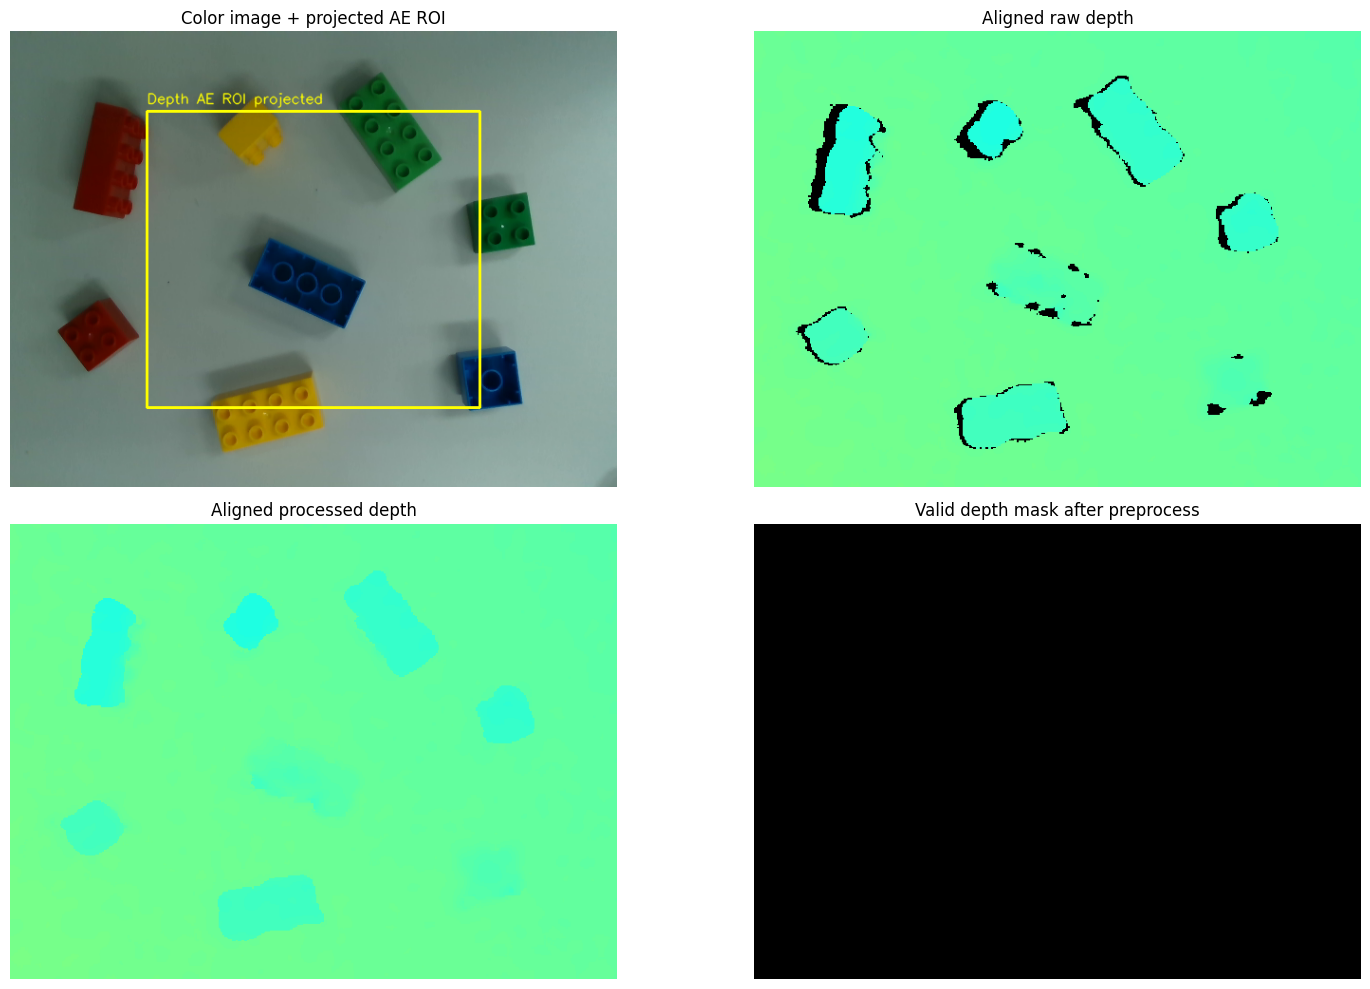

[OK] rs_output 변수에 color/depth/intrinsics 저장됨.


In [63]:
# ============================================================
# 2. 프레임 획득 + aligned depth/color + intrinsics 출력
# ============================================================

print_title("CAPTURE ALIGNED FRAME")

frames = pipeline.wait_for_frames()
aligned_frames = align_to_color.process(frames)

aligned_depth_frame_raw = aligned_frames.get_depth_frame()
color_frame = aligned_frames.get_color_frame()

if not aligned_depth_frame_raw:
    raise RuntimeError("No aligned depth frame.")
if not color_frame:
    raise RuntimeError("No color frame.")

# pre-process 적용된 aligned depth
aligned_depth_frame = preprocess_depth_frame(aligned_depth_frame_raw)

aligned_depth_img = np.asanyarray(aligned_depth_frame.get_data())
aligned_depth_raw_img = np.asanyarray(aligned_depth_frame_raw.get_data())
color_img = np.asanyarray(color_frame.get_data())

depth_scale = depth_sensor.get_depth_scale()
aligned_depth_m = aligned_depth_img.astype(np.float32) * depth_scale
aligned_depth_raw_m = aligned_depth_raw_img.astype(np.float32) * depth_scale

print("color_img shape             :", color_img.shape, color_img.dtype)
print("aligned_depth_raw shape     :", aligned_depth_raw_img.shape, aligned_depth_raw_img.dtype)
print("aligned_depth_processed shape:", aligned_depth_img.shape, aligned_depth_img.dtype)
print("depth_scale                 :", depth_scale)

# ------------------------------------------------------------
# Intrinsics
# aligned_depth는 color 좌표계로 align 되었으므로
# aligned_depth 픽셀을 3D로 deproject할 때는 color intrinsics를 쓰는 게 맞음
# ------------------------------------------------------------
color_profile = color_frame.profile.as_video_stream_profile()
color_intr = color_profile.get_intrinsics()

raw_depth_profile = profile.get_stream(rs.stream.depth).as_video_stream_profile()
raw_depth_intr = raw_depth_profile.get_intrinsics()

intrinsics = {
    "aligned_to": "color",
    "color_intrinsics_for_aligned_depth": intrinsics_to_dict(color_intr),
    "raw_depth_intrinsics": intrinsics_to_dict(raw_depth_intr),
    "depth_scale": depth_scale,
    "depth_units_option": depth_sensor.get_option(rs.option.depth_units)
        if depth_sensor.supports(rs.option.depth_units) else None,
    "depth_ae_roi": depth_roi,
    "preprocess_config": {
        "threshold": {
            "enabled": CONFIG["enable_threshold"],
            "min_m": CONFIG["threshold_min_m"],
            "max_m": CONFIG["threshold_max_m"],
        },
        "disparity_spatial": {
            "enabled": CONFIG["enable_disparity_spatial"],
            "spatial_magnitude": CONFIG["spatial_magnitude"],
            "spatial_alpha": CONFIG["spatial_alpha"],
            "spatial_delta": CONFIG["spatial_delta"],
            "spatial_holes_fill": CONFIG["spatial_holes_fill"],
        },
        "temporal": {
            "enabled": CONFIG["enable_temporal"],
            "temporal_alpha": CONFIG["temporal_alpha"],
            "temporal_delta": CONFIG["temporal_delta"],
            "temporal_persistency": CONFIG["temporal_persistency"],
        },
        "hole_filling": {
            "enabled": CONFIG["enable_hole_filling"],
            "mode": CONFIG["hole_filling_mode"],
        },
    },
}

print_title("INTRINSICS")
pprint.pprint(intrinsics, sort_dicts=False)

# ------------------------------------------------------------
# Depth visualization
# ------------------------------------------------------------
def colorize_depth_for_view(depth_m, min_m=None, max_m=None):
    valid = depth_m > 0

    if min_m is None:
        min_m = CONFIG["threshold_min_m"]

    if max_m is None:
        max_m = CONFIG["threshold_max_m"]

    vis = np.zeros(depth_m.shape, dtype=np.uint8)
    valid_range = valid & (depth_m >= min_m) & (depth_m <= max_m)

    clipped = np.clip(depth_m, min_m, max_m)
    vis[valid_range] = (
        (clipped[valid_range] - min_m) / (max_m - min_m + 1e-9) * 255
    ).astype(np.uint8)

    colorized = cv2.applyColorMap(vis, cv2.COLORMAP_JET)
    colorized[~valid_range] = 0
    return colorized


depth_raw_vis = colorize_depth_for_view(
    aligned_depth_raw_m,
    CONFIG["threshold_min_m"],
    CONFIG["threshold_max_m"],
)

depth_proc_vis = colorize_depth_for_view(
    aligned_depth_m,
    CONFIG["threshold_min_m"],
    CONFIG["threshold_max_m"],
)

# ROI 표시: depth ROI는 raw depth 기준이라 color aligned 화면과 해상도가 다를 수 있음.
# 여기서는 color 화면 중앙에 참고용으로 비율 변환해서 표시.
color_vis = color_img.copy()

sx = CONFIG["color_width"] / CONFIG["depth_width"]
sy = CONFIG["color_height"] / CONFIG["depth_height"]

rx0 = int(depth_roi["min_x"] * sx)
ry0 = int(depth_roi["min_y"] * sy)
rx1 = int(depth_roi["max_x"] * sx)
ry1 = int(depth_roi["max_y"] * sy)

cv2.rectangle(color_vis, (rx0, ry0), (rx1, ry1), (0, 255, 255), 2)
cv2.putText(
    color_vis,
    "Depth AE ROI projected",
    (rx0, max(20, ry0 - 8)),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.5,
    (0, 255, 255),
    1,
    cv2.LINE_AA,
)

plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(color_vis, cv2.COLOR_BGR2RGB))
plt.title("Color image + projected AE ROI")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(cv2.cvtColor(depth_raw_vis, cv2.COLOR_BGR2RGB))
plt.title("Aligned raw depth")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(cv2.cvtColor(depth_proc_vis, cv2.COLOR_BGR2RGB))
plt.title("Aligned processed depth")
plt.axis("off")

plt.subplot(2, 2, 4)
valid_mask = (aligned_depth_m > 0).astype(np.uint8) * 255
plt.imshow(valid_mask, cmap="gray")
plt.title("Valid depth mask after preprocess")
plt.axis("off")

plt.tight_layout()
plt.show()


# 이후 다른 셀에서 쓸 수 있게 변수 유지
rs_output = {
    "color_img_bgr": color_img,
    "aligned_depth_raw_uint16": aligned_depth_raw_img,
    "aligned_depth_processed_uint16": aligned_depth_img,
    "aligned_depth_raw_m": aligned_depth_raw_m,
    "aligned_depth_processed_m": aligned_depth_m,
    "intrinsics": intrinsics,
    "depth_scale": depth_scale,
}

print("[OK] rs_output 변수에 color/depth/intrinsics 저장됨.")

In [31]:
pipeline.stop()
print("RealSense stopped.")

RealSense stopped.


In [56]:
color_img_bgr = rs_output["color_img_bgr"]
aligned_depth_img = rs_output["aligned_depth_processed_uint16"]


라이브러리 로드

0: 480x640 1 2x2_blue, 1 2x2_green, 2 2x2_reds, 1 2x2_yellow, 1 4x2_blue, 2 4x2_greens, 1 4x2_yellow, 12.8ms
Speed: 23.7ms preprocess, 12.8ms inference, 3.8ms postprocess per image at shape (1, 3, 480, 640)
[INFO] original bbox 개수: 9
[INFO] merged bbox 개수: 9
[SUCCESS] merged bbox 9개를 mask로 변환 완료


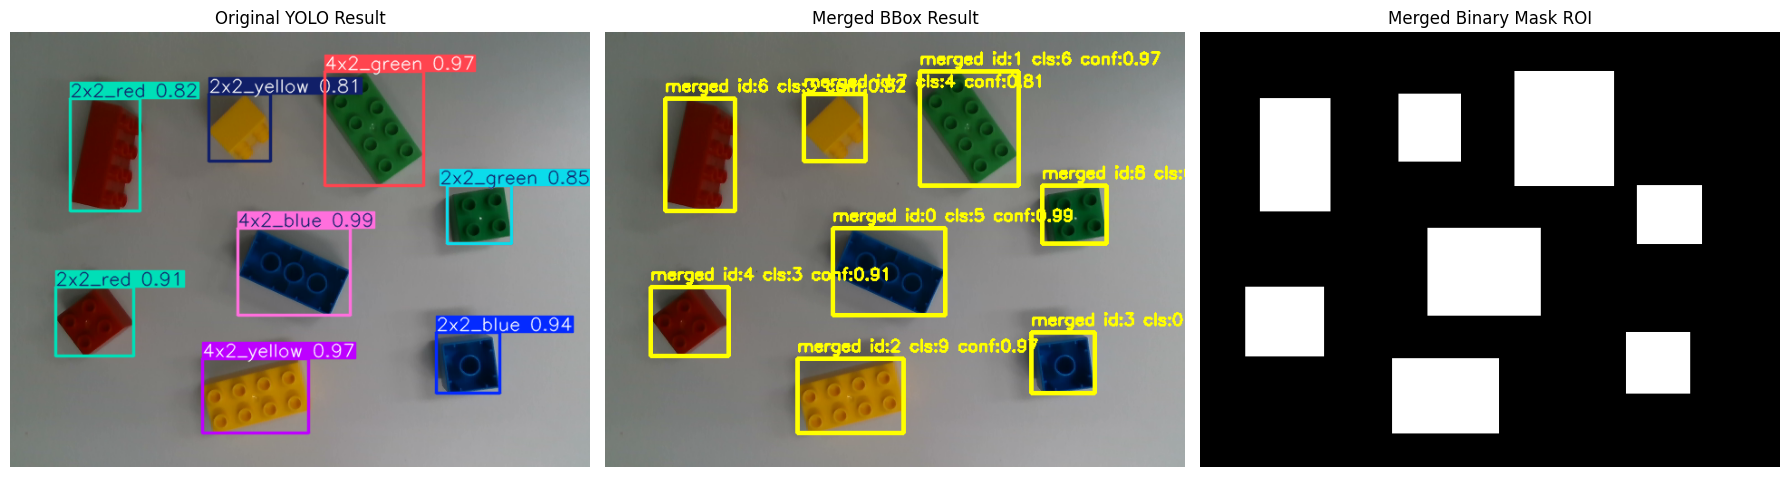

In [57]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt

import os
import yaml
import numpy as np
import cv2
import pyrealsense2 as rs
import matplotlib.pyplot as plt
import pprint
import open3d as o3d
from sklearn.cluster import DBSCAN
from ultralytics import YOLO
import torch

# import INUVisionLib as ivl

print("\n라이브러리 로드")

# ---------------------------------------------------------
# 1. YOLO 모델 로드
# ---------------------------------------------------------
model = YOLO("../yolo_models/train1_05_04/weights/best.pt")

target_classes = [0, 1, 3, 4, 5, 6, 8, 9]

H, W = color_img_bgr.shape[:2]

# ---------------------------------------------------------
# 2. YOLO 추론
# ---------------------------------------------------------
results = model(color_img_bgr, classes=target_classes)

# ---------------------------------------------------------
# 2-1. 같은 class ID bbox 병합 함수
# ---------------------------------------------------------
def boxes_are_close_or_overlap(box_a, box_b, margin=10):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    ax1 -= margin
    ay1 -= margin
    ax2 += margin
    ay2 += margin

    if ax2 < bx1:
        return False
    if bx2 < ax1:
        return False
    if ay2 < by1:
        return False
    if by2 < ay1:
        return False

    return True


def merge_close_boxes_by_class(boxes, clss, confs=None, margin=10):
    boxes = np.asarray(boxes, dtype=np.float32)
    clss = np.asarray(clss, dtype=np.int32)

    if confs is None:
        confs = np.ones(len(boxes), dtype=np.float32)
    else:
        confs = np.asarray(confs, dtype=np.float32)

    n = len(boxes)
    if n == 0:
        return boxes, clss, confs

    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra = find(a)
        rb = find(b)
        if ra != rb:
            parent[rb] = ra

    for i in range(n):
        for j in range(i + 1, n):
            if clss[i] != clss[j]:
                continue

            if boxes_are_close_or_overlap(boxes[i], boxes[j], margin=margin):
                union(i, j)

    groups = {}
    for i in range(n):
        root = find(i)
        groups.setdefault(root, []).append(i)

    merged_boxes = []
    merged_clss = []
    merged_confs = []

    for _, idxs in groups.items():
        group_boxes = boxes[idxs]
        group_confs = confs[idxs]
        group_clss = clss[idxs]

        x1 = np.min(group_boxes[:, 0])
        y1 = np.min(group_boxes[:, 1])
        x2 = np.max(group_boxes[:, 2])
        y2 = np.max(group_boxes[:, 3])

        cls = int(group_clss[0])
        conf = float(np.max(group_confs))

        x1 = max(0, min(x1, W - 1))
        y1 = max(0, min(y1, H - 1))
        x2 = max(0, min(x2, W - 1))
        y2 = max(0, min(y2, H - 1))

        merged_boxes.append([x1, y1, x2, y2])
        merged_clss.append(cls)
        merged_confs.append(conf)

    return (
        np.asarray(merged_boxes, dtype=np.float32),
        np.asarray(merged_clss, dtype=np.int32),
        np.asarray(merged_confs, dtype=np.float32)
    )


# ---------------------------------------------------------
# 3. YOLO 결과에서 bbox 추출 후 병합
# ---------------------------------------------------------
mask_binary = np.zeros((H, W), dtype=np.uint8)

merged_boxes = np.empty((0, 4), dtype=np.float32)
merged_clss = np.empty((0,), dtype=np.int32)
merged_confs = np.empty((0,), dtype=np.float32)

if len(results) > 0:
    r = results[0]

    if r.boxes is not None and len(r.boxes) > 0:
        boxes = r.boxes.xyxy.cpu().numpy()
        clss = r.boxes.cls.cpu().numpy().astype(int)

        if r.boxes.conf is not None:
            confs = r.boxes.conf.cpu().numpy()
        else:
            confs = np.ones(len(boxes), dtype=np.float32)

        merged_boxes, merged_clss, merged_confs = merge_close_boxes_by_class(
            boxes=boxes,
            clss=clss,
            confs=confs,
            margin=10
        )

        print(f"[INFO] original bbox 개수: {len(boxes)}")
        print(f"[INFO] merged bbox 개수: {len(merged_boxes)}")

        # 병합된 bbox로 mask 생성
        for box in merged_boxes:
            x1, y1, x2, y2 = box.astype(int)

            x1 = max(0, min(x1, W - 1))
            y1 = max(0, min(y1, H - 1))
            x2 = max(0, min(x2, W - 1))
            y2 = max(0, min(y2, H - 1))

            mask_binary[y1:y2 + 1, x1:x2 + 1] = 1

        print(f"[SUCCESS] merged bbox {len(merged_boxes)}개를 mask로 변환 완료")

    else:
        print("[WARN] 지정된 클래스의 객체가 검출되지 않았습니다.")

else:
    print("[WARN] YOLO result가 비어 있습니다.")


# ---------------------------------------------------------
# 4. 시각화
# ---------------------------------------------------------
vis_original = results[0].plot() if len(results) > 0 else color_img_bgr.copy()
vis_merged = color_img_bgr.copy()

# 병합 bbox 그리기
for i, box in enumerate(merged_boxes):
    x1, y1, x2, y2 = box.astype(int)
    cls_id = int(merged_clss[i])
    conf = float(merged_confs[i])

    cv2.rectangle(
        vis_merged,
        (x1, y1),
        (x2, y2),
        (0, 255, 255),
        3
    )

    label = f"merged id:{i} cls:{cls_id} conf:{conf:.2f}"
    cv2.putText(
        vis_merged,
        label,
        (x1, max(20, y1 - 8)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 255),
        2
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(vis_original, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original YOLO Result")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(vis_merged, cv2.COLOR_BGR2RGB))
axes[1].set_title("Merged BBox Result")
axes[1].axis("off")

axes[2].imshow(mask_binary, cmap="gray")
axes[2].set_title("Merged Binary Mask ROI")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [65]:
import cv2
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt



# # filtered_depth_img = depth_img.copy()

# # # 1. 2D Depth Map 전처리: Median 필터 적용
# # filtered_depth_img = cv2.medianBlur(depth_img, 3)

# kernel = np.ones((5, 5), np.uint8)
# expanded_mask = cv2.dilate(mask_binary, kernel, iterations=2) # iterations 숫자를 키울수록 구멍이 커짐

# # 기존 mask_binary 대신 expanded_mask를 반전시켜 배경 마스크 생성
# bg_mask = 1 - expanded_mask 
# filtered_depth_img[bg_mask == 0] = 0



# =================================================================
# 1. 2D Depth Map 전처리: Median 필터 적용
# filtered_depth_img = cv2.medianBlur(depth_img, 5)

filtered_depth_img = aligned_depth_img.copy()

if "mask_binary" not in globals():
    print("[WARN] mask_binary 없음. 객체 제거 없이 전체 depth 사용")
    mask_binary = np.zeros(aligned_depth_img.shape[:2], dtype=np.uint8)

# 객체 마스크 확장
mask_01 = (mask_binary > 0).astype(np.uint8)

kernel = np.ones((5, 5), np.uint8)
expanded_mask = cv2.dilate(mask_01, kernel, iterations=2)

# YOLO로 잡힌 객체 영역을 depth에서 제거하고 바닥만 남김
filtered_depth_img[expanded_mask == 1] = 0
# =================================================================


# ============================================================
# Open3D intrinsics / depth scale은 현재 rs_output 기준으로 사용
# aligned_depth_img는 color 기준으로 align된 depth이므로
# color intrinsics_for_aligned_depth를 써야 함
# ============================================================

intr = rs_output["intrinsics"]["color_intrinsics_for_aligned_depth"]

o3d_intr = o3d.camera.PinholeCameraIntrinsic(
    int(intr["width"]),
    int(intr["height"]),
    float(intr["fx"]),
    float(intr["fy"]),
    float(intr["ppx"]),
    float(intr["ppy"])
)

depth_meter_per_unit = float(rs_output["depth_scale"])
o3d_depth_scale = 1.0 / depth_meter_per_unit

print("[INFO] aligned depth shape:", aligned_depth_img.shape)
print("[INFO] intrinsics width height:", intr["width"], intr["height"])
print("[INFO] depth_meter_per_unit:", depth_meter_per_unit)
print("[INFO] o3d_depth_scale:", o3d_depth_scale)

bg_depth_o3d = o3d.geometry.Image(filtered_depth_img)

bg_pcd = o3d.geometry.PointCloud.create_from_depth_image(
    bg_depth_o3d,
    o3d_intr,
    depth_scale=o3d_depth_scale,
    depth_trunc=0.80  # 지금 근거리면 0.8m 정도면 충분
)

print("[DEBUG] raw bg_pcd points:", len(bg_pcd.points))

if len(bg_pcd.points) < 3:
    raise RuntimeError(
        f"PointCloud가 비었습니다. "
        f"depth_scale={depth_meter_per_unit}, "
        f"depth nonzero={np.count_nonzero(filtered_depth_img)}, "
        f"depth min/max raw={filtered_depth_img[filtered_depth_img > 0].min() if np.count_nonzero(filtered_depth_img)>0 else None}/"
        f"{filtered_depth_img.max()}"
    )

bg_pcd = bg_pcd.voxel_down_sample(voxel_size=0.003)
print("[DEBUG] after voxel:", len(bg_pcd.points))

if len(bg_pcd.points) >= 30:
    bg_pcd, ind = bg_pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
    print("[DEBUG] after statistical:", len(bg_pcd.points))

if len(bg_pcd.points) >= 30:
    bg_pcd, ind = bg_pcd.remove_radius_outlier(nb_points=10, radius=0.01)
    print("[DEBUG] after radius:", len(bg_pcd.points))

if len(bg_pcd.points) < 3:
    raise RuntimeError(f"RANSAC 전에 point가 너무 적음: {len(bg_pcd.points)}")

# =================================================================
# [★ 아웃라이어 제거 추가]
# RANSAC 수행 전에 공중부양 노이즈를 먼저 확실하게 쳐냅니다.
# =================================================================
bg_pcd, ind = bg_pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
bg_pcd, ind = bg_pcd.remove_radius_outlier(nb_points=10, radius=0.01)
# =================================================================

# =================================================================
# 3. RANSAC 바닥면 검출
# =================================================================
plane_model, inliers = bg_pcd.segment_plane(distance_threshold=0.015,
                                            ransac_n=3,
                                            num_iterations=1000)
a, b, c, d = plane_model
plane_normal = np.array([a, b, c])

# 카메라 시점 방향으로 법선 벡터 뒤집기 방지
if c > 0: 
    plane_normal = -plane_normal
    d = -d
    plane_model = [plane_normal[0], plane_normal[1], plane_normal[2], d]

# =================================================================
# 4. 바닥면을 이쁜 평면으로 '다림질' (Mathematical Projection)
# =================================================================
# inliers: 란삭이 바닥이라고 인식한 점들의 인덱스
floor_pcd = bg_pcd.select_by_index(inliers)
outlier_pcd = bg_pcd.select_by_index(inliers, invert=True) # 바닥이 아닌 나머지 노이즈들

# 바닥 점들의 3D 좌표 (N x 3)
floor_points = np.asarray(floor_pcd.points)

# 각 점들에서 완벽한 수학적 평면(ax+by+cz+d=0)까지의 수직 거리 계산
# (Open3D의 segment_plane은 기본적으로 법선 벡터를 단위 벡터로 반환합니다)
distances = np.dot(floor_points, plane_normal) + d

# 원래 점의 위치에서 평면까지의 거리만큼 법선 반대 방향으로 밀어넣어 평면에 완전히 밀착시킴
flattened_points = floor_points - np.outer(distances, plane_normal)

# '다림질'된 점들을 다시 포인트 클라우드에 덮어쓰기
floor_pcd.points = o3d.utility.Vector3dVector(flattened_points)

# 시각화를 위해 색상 지정 (바닥은 예쁜 연회색, 아웃라이어는 빨간색)
floor_pcd.paint_uniform_color([0.8, 0.8, 0.8])
outlier_pcd.paint_uniform_color([1.0, 0.0, 0.0])

print(f"[SUCCESS] 바닥면 평탄화 완료. 평면 방정식: {a:.3f}x + {b:.3f}y + {c:.3f}z + {d:.3f} = 0")

# =================================================================
# 5. 결과 시각화
# =================================================================
print("\n[INFO] 3D 시각화 창을 엽니다. 바닥면이 유리판처럼 평평해진 것을 확인하세요.")
o3d.visualization.draw_geometries([floor_pcd, outlier_pcd], window_name="Flattened Floor Plane")

# =================================================================
# 6. RANSAC 바닥면 기준으로 "바닥보다 위에 있는 포인트" 제거해서 보기
# =================================================================

# 원본 depth에서 다시 point cloud 생성
# 여기서는 객체 마스크를 적용하지 않은 depth_img를 사용함
# 필요하면 depth_img 대신 filtered_depth_img를 넣어도 됨
# depth_for_cut = cv2.medianBlur(depth_img, 5)
depth_for_cut = aligned_depth_img.copy()

depth_o3d = o3d.geometry.Image(depth_for_cut)

full_pcd = o3d.geometry.PointCloud.create_from_depth_image(
    depth_o3d,
    o3d_intr,
    depth_scale=o3d_depth_scale,
    depth_trunc=1.5
)

# 다운샘플링
full_pcd = full_pcd.voxel_down_sample(voxel_size=0.0001)

points = np.asarray(full_pcd.points)

# ---------------------------------------------------------
# RANSAC 바닥 평면과 각 점 사이의 signed distance 계산
# plane: plane_normal dot p + d = 0
#
# 네 코드에서는 plane_normal의 z가 음수가 되도록 맞췄음.
# 카메라가 위에서 아래를 보는 상황에서는:
# signed_height > 0  : 바닥보다 카메라 쪽, 즉 바닥 위의 물체
# signed_height ~= 0 : 바닥
# signed_height < 0  : 바닥 아래쪽 노이즈
# ---------------------------------------------------------
signed_height = np.dot(points, plane_normal) + d

# 바닥보다 몇 m 이상 위에 있으면 제거할지
# 0.005 = 5 mm
# 0.010 = 10 mm
height_threshold = 0.005

# 바닥보다 위에 있는 점
above_mask = signed_height > height_threshold

# 제거 후 남길 점: 바닥보다 높지 않은 점들
keep_mask = ~above_mask

kept_indices = np.where(keep_mask)[0]
removed_indices = np.where(above_mask)[0]

pcd_floor_or_below = full_pcd.select_by_index(kept_indices)
pcd_above_removed = full_pcd.select_by_index(removed_indices)

# 색상 지정
pcd_floor_or_below.paint_uniform_color([0.7, 0.7, 0.7])  # 남은 점: 회색
pcd_above_removed.paint_uniform_color([1.0, 0.0, 0.0])   # 제거될 점: 빨강

print("[INFO] full point count:", len(full_pcd.points))
print("[INFO] kept point count:", len(pcd_floor_or_below.points))
print("[INFO] removed above-floor point count:", len(pcd_above_removed.points))
print("[INFO] height_threshold [m]:", height_threshold)

# 먼저 제거될 점을 빨간색으로 같이 보기
o3d.visualization.draw_geometries(
    [pcd_floor_or_below, pcd_above_removed],
    window_name="Gray = Kept Floor/Below, Red = Removed Above Floor"
)

# 제거 후 결과만 보기
o3d.visualization.draw_geometries(
    [pcd_floor_or_below],
    window_name="After Removing Points Above RANSAC Floor"
)

[INFO] aligned depth shape: (480, 640)
[INFO] intrinsics width height: 640 480
[INFO] depth_meter_per_unit: 9.999999747378752e-06
[INFO] o3d_depth_scale: 100000.00252621254
[DEBUG] raw bg_pcd points: 228091
[DEBUG] after voxel: 11021
[DEBUG] after statistical: 10564
[DEBUG] after radius: 10564
[SUCCESS] 바닥면 평탄화 완료. 평면 방정식: 0.023x + -0.019y + 1.000z + 0.365 = 0

[INFO] 3D 시각화 창을 엽니다. 바닥면이 유리판처럼 평평해진 것을 확인하세요.
[Open3D WARNING] The number of points is 0 when creating axis-aligned bounding box.
[INFO] full point count: 307200
[INFO] kept point count: 274130
[INFO] removed above-floor point count: 33070
[INFO] height_threshold [m]: 0.005


In [68]:
import cv2
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# =================================================================
# [0] 사전 체크
# =================================================================
if "aligned_depth_img" not in globals():
    raise RuntimeError("aligned_depth_img가 없습니다. RealSense 캡처 셀을 먼저 실행하세요.")

if "o3d_intr" not in globals() or "o3d_depth_scale" not in globals():
    raise RuntimeError("o3d_intr 또는 o3d_depth_scale이 없습니다. 첫 번째 RANSAC 셀을 먼저 실행하세요.")

if "plane_normal" not in globals() or "d" not in globals():
    raise RuntimeError("plane_normal 또는 d가 없습니다. 바닥 RANSAC 셀을 먼저 실행하세요.")

# =================================================================
# [1] 꽉 찬 고밀도 바닥면(Dense Floor) 복원 
# 2D 마스크로 뚫린 구멍 없이, 오직 RANSAC 평면 공식으로만 바닥을 추출합니다.
# =================================================================
print("[INFO] 고밀도 바닥면 복원을 시작합니다...")
full_depth_o3d = o3d.geometry.Image(aligned_depth_img)
full_pcd = o3d.geometry.PointCloud.create_from_depth_image(
    full_depth_o3d,
    o3d_intr,
    depth_scale=o3d_depth_scale,
    depth_trunc=0.80
)
# 연산 속도와 시각화를 위해 다운샘플링 (필요시 조절)
full_pcd = full_pcd.voxel_down_sample(voxel_size=0.002)

full_points = np.asarray(full_pcd.points)
# RANSAC 평면 기준 각 점의 높이 계산
full_signed_height = np.dot(full_points, plane_normal) + d

# 바닥 평면 근처(-5mm ~ 2.5mm)에 있는 점들만 추출하여 구멍 없는 바닥 완성
dense_floor_indices = np.where((full_signed_height > -0.005) & (full_signed_height <= 0.0025))[0]
dense_floor_pcd = full_pcd.select_by_index(dense_floor_indices)

# 바닥을 예쁜 연회색으로 칠하고, 바닥을 평평하게 다림질(Projection)
floor_points = np.asarray(dense_floor_pcd.points)
distances = np.dot(floor_points, plane_normal) + d
flattened_floor = floor_points - np.outer(distances, plane_normal)
dense_floor_pcd.points = o3d.utility.Vector3dVector(flattened_floor)
dense_floor_pcd.paint_uniform_color([0.85, 0.85, 0.85]) 

print(f"[SUCCESS] 구멍 없는 바닥면 생성 완료: {len(dense_floor_pcd.points)} points")

# =================================================================
# [2] 객체 영역 추출 (YOLO Bbox 내부 + 바닥보다 높은 점)
# =================================================================
if "mask_binary" not in globals():
    mask_binary = np.zeros(aligned_depth_img.shape[:2], dtype=np.uint8)

mask_01 = (mask_binary > 0).astype(np.uint8)
obj_depth_img = aligned_depth_img.copy()
obj_depth_img = cv2.medianBlur(obj_depth_img, 3)

# 2D 상에서 YOLO 영역 밖의 노이즈 제거
obj_depth_img[mask_01 == 0] = 0

obj_depth_o3d = o3d.geometry.Image(obj_depth_img)
obj_pcd = o3d.geometry.PointCloud.create_from_depth_image(
    obj_depth_o3d, o3d_intr, depth_scale=o3d_depth_scale, depth_trunc=0.80
)
obj_pcd = obj_pcd.voxel_down_sample(voxel_size=0.001)

# 3D 상에서 바닥보다 확실히 높은(3mm 이상) 점만 객체로 분리
obj_points = np.asarray(obj_pcd.points)
obj_heights = np.dot(obj_points, plane_normal) + d
obj_indices = np.where(obj_heights > 0.003)[0]
obj_pcd_clean = obj_pcd.select_by_index(obj_indices)

if len(obj_pcd_clean.points) >= 50:
    obj_pcd_clean, _ = obj_pcd_clean.remove_statistical_outlier(nb_neighbors=30, std_ratio=1.5)

# =================================================================
# [3] DBSCAN 클러스터링 및 PCA 기반 OBB 생성
# =================================================================
labels = np.array(obj_pcd_clean.cluster_dbscan(eps=0.015, min_points=30, print_progress=False))
if labels.size == 0:
    raise RuntimeError("DBSCAN label이 비었습니다.")

max_label = labels.max()
print(f"[INFO] 발견된 객체 클러스터 수: {max_label + 1}")

# 시각화 리스트의 첫 번째 요소로 '구멍 없는 바닥면'을 넣습니다.
vis_geometries = [dense_floor_pcd] 
colors = plt.get_cmap("tab20")(np.linspace(0, 1, max_label + 1))
local_z_axis = plane_normal / np.linalg.norm(plane_normal)

for cluster_idx in range(max_label + 1):
    cluster_indices = np.where(labels == cluster_idx)[0]
    if len(cluster_indices) < 20: continue

    sub_obj_pcd = obj_pcd_clean.select_by_index(cluster_indices)
    
    # =================================================================
    # [새로 추가된 핵심 로직] 서브 클러스터링 (파편 제거)
    # 15mm 반경으로 묶인 현재 덩어리 내에서, 7mm 반경으로 다시 클러스터링하여
    # 허공을 두고 떨어져 있는 노이즈 파편을 분리해 냅니다.
    # =================================================================
    if len(sub_obj_pcd.points) > 30:
        # eps=0.007(7mm)로 촘촘하게 다시 묶기
        sub_labels = np.array(sub_obj_pcd.cluster_dbscan(eps=0.007, min_points=10, print_progress=False))
        
        if sub_labels.size > 0 and sub_labels.max() >= 0:
            # 노이즈(-1)를 제외한 유효 라벨들 추출
            valid_labels = sub_labels[sub_labels >= 0]
            if len(valid_labels) > 0:
                # 가장 점이 많은(제일 큰) 본체 덩어리의 라벨 번호 찾기
                unique_labels, counts = np.unique(valid_labels, return_counts=True)
                largest_sub_label = unique_labels[np.argmax(counts)]
                
                # 가장 큰 본체 덩어리만 남기고 덮어쓰기 (파편은 여기서 날아감)
                largest_indices = np.where(sub_labels == largest_sub_label)[0]
                sub_obj_pcd = sub_obj_pcd.select_by_index(largest_indices)
    # =================================================================

    # 기존 2차 아웃라이어 제거 (잔여 노이즈 정리)
    if len(sub_obj_pcd.points) >= 30:
        sub_obj_pcd, _ = sub_obj_pcd.remove_radius_outlier(nb_points=10, radius=0.01)
    if len(sub_obj_pcd.points) >= 30:
        sub_obj_pcd, _ = sub_obj_pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=1.0)
    if len(sub_obj_pcd.points) < 20: continue

    # 시각화를 위한 색상 칠하기
    sub_obj_pcd.paint_uniform_color(colors[cluster_idx][:3])
    vis_geometries.append(sub_obj_pcd)

    sub_points = np.asarray(sub_obj_pcd.points)
    
    # (이하 기존과 동일) ------------------------------------------------
    # 높이 계산
    heights = np.dot(sub_points, plane_normal) + d
    max_h = np.percentile(heights, 95)
    height_variance = np.std(heights)

    # 평면 비율 계산 (Try-Except 그대로 유지)
    try:
        _, obj_inliers = sub_obj_pcd.segment_plane(distance_threshold=0.002, ransac_n=3, num_iterations=200)
        plane_ratio = len(obj_inliers) / len(sub_points)
    except:
        plane_ratio = 0.0

    # 듀플로 높이 보정 로직
    if height_variance > 0.007 and plane_ratio < 0.4:
        final_h, box_color = 0.024, [0, 0, 1] # 24mm 고정
    elif plane_ratio >= 0.8:
        final_h, box_color = max_h, [0, 1, 0]
    else:
        final_h, box_color = max_h, [1, 0, 0]
        
    final_h = max(float(final_h), 0.005)

    # PCA 계산
    centroid = sub_obj_pcd.get_center()
    pca = PCA(n_components=3)
    pca.fit(sub_points)
    major_axis = pca.components_[0]

    # 장축을 Z축 기준으로 투영 (Roll/Pitch 제거)
    proj_axis = major_axis - np.dot(major_axis, local_z_axis) * local_z_axis
    proj_norm = np.linalg.norm(proj_axis)
    if proj_norm < 1e-6: continue

    local_x_axis = proj_axis / proj_norm
    local_y_axis = np.cross(local_z_axis, local_x_axis)
    local_y_axis /= np.linalg.norm(local_y_axis)
    
    local_x_axis = np.cross(local_y_axis, local_z_axis)
    local_x_axis /= np.linalg.norm(local_x_axis)
    R_object = np.vstack([local_x_axis, local_y_axis, local_z_axis]).T

    # OBB 크기 및 중심 계산
    centered_points = sub_points - centroid
    local_x_vals = np.dot(centered_points, local_x_axis)
    local_y_vals = np.dot(centered_points, local_y_axis)

    extent_x = local_x_vals.max() - local_x_vals.min()
    extent_y = local_y_vals.max() - local_y_vals.min()
    if extent_x < 0.005 or extent_y < 0.005: continue

    extent = np.array([extent_x, extent_y, final_h])
    local_cx = (local_x_vals.max() + local_x_vals.min()) / 2.0
    local_cy = (local_y_vals.max() + local_y_vals.min()) / 2.0
    global_xy_center = centroid + local_cx * local_x_axis + local_cy * local_y_axis

    # 바닥에 딱 맞추기
    dist_to_floor = np.dot(global_xy_center, plane_normal) + d
    floor_center = global_xy_center - dist_to_floor * plane_normal
    box_center = floor_center + local_z_axis * (final_h / 2.0)

    # OBB 생성 및 등록
    obb = o3d.geometry.OrientedBoundingBox(center=box_center, R=R_object, extent=extent)
    obb.color = box_color
    vis_geometries.append(obb)

print("\n[INFO] PCA 기반 3D 바운딩 박스 및 고밀도 바닥면 시각화")
o3d.visualization.draw_geometries(vis_geometries, window_name="Dense Floor & 3D Pose")

[INFO] 고밀도 바닥면 복원을 시작합니다...
[SUCCESS] 구멍 없는 바닥면 생성 완료: 28108 points
[INFO] 발견된 객체 클러스터 수: 10

[INFO] PCA 기반 3D 바운딩 박스 및 고밀도 바닥면 시각화


In [72]:
%pwd

'c:\\Users\\ULTIMATE NIGHTMARE\\Desktop\\test\\pointcloud_test\\ttest'

In [11]:
import open3d as o3d
import numpy as np

# ply_path = "../duplo/rendered_duplo_2.ply"   # 여기에 네 ply 경로 입력
ply_path = "../duplo/rendered_duplo_4.ply"   # 여기에 네 ply 경로 입력

pcd = o3d.io.read_point_cloud(ply_path)

print("[INFO] point count:", len(pcd.points))
print("[INFO] has colors:", pcd.has_colors())
print("[INFO] has normals:", pcd.has_normals())

points = np.asarray(pcd.points)
print("[INFO] points shape:", points.shape)

if len(points) > 0:
    print("[INFO] min xyz:", points.min(axis=0))
    print("[INFO] max xyz:", points.max(axis=0))
    print("[INFO] center :", points.mean(axis=0))

o3d.visualization.draw_geometries(
    [pcd],
    window_name="PLY Point Cloud"
)

[INFO] point count: 3923486
[INFO] has colors: False
[INFO] has normals: False
[INFO] points shape: (3923486, 3)
[INFO] min xyz: [-15.63863182 -32.14735794 -12.72359753]
[INFO] max xyz: [15.53400421 31.51117325 11.12243366]
[INFO] center : [ 0.00565144  0.014353   -0.30631046]


In [13]:
import open3d as o3d
import numpy as np
from pathlib import Path

# ply_path = Path("../duplo/rendered_duplo_2.ply")
ply_path = Path("../duplo/rendered_duplo_4.ply")

if not ply_path.exists():
    raise FileNotFoundError(f"파일 없음: {ply_path.resolve()}")

print("[INFO] file:", ply_path.resolve())

# ============================================================
# 1. Mesh로 읽히는지 확인
# ============================================================
mesh = o3d.io.read_triangle_mesh(str(ply_path))
pcd_raw = o3d.io.read_point_cloud(str(ply_path))

print("[INFO] mesh vertices :", len(mesh.vertices))
print("[INFO] mesh triangles:", len(mesh.triangles))
print("[INFO] pcd points    :", len(pcd_raw.points))

# ============================================================
# 2. 단위/크기 확인
# ============================================================
if len(mesh.vertices) > 0:
    pts_check = np.asarray(mesh.vertices)
else:
    pts_check = np.asarray(pcd_raw.points)

print("[INFO] min xyz:", pts_check.min(axis=0))
print("[INFO] max xyz:", pts_check.max(axis=0))
print("[INFO] size   :", pts_check.max(axis=0) - pts_check.min(axis=0))

# Blender 모델이 mm 단위인데 Open3D에서 m처럼 보이면 scale 적용
# 예: 크기가 10~100 단위로 나오면 mm일 가능성이 큼
AUTO_SCALE = True

size = pts_check.max(axis=0) - pts_check.min(axis=0)
max_size = float(np.max(size))

scale_factor = 1.0
if AUTO_SCALE and max_size > 1.0:
    # mm -> m 가정
    scale_factor = 0.001
    print(f"[INFO] 모델 크기가 큼. scale {scale_factor} 적용")

# ============================================================
# 3-A. Mesh PLY인 경우: mesh 단순화 후 포인트 샘플링
# ============================================================
if len(mesh.triangles) > 0:
    print("\n[MODE] Mesh 기반 테두리 보존 다운샘플링")

    mesh.compute_vertex_normals()

    if scale_factor != 1.0:
        mesh.scale(scale_factor, center=[0, 0, 0])

    # vertex clustering은 voxel 격자로 mesh를 줄임
    # voxel_size가 작을수록 테두리 보존은 좋고 점 수는 많음
    voxel_size_mesh = 0.0015  # 1.5 mm
    mesh_simplified = mesh.simplify_vertex_clustering(
        voxel_size=voxel_size_mesh,
        contraction=o3d.geometry.SimplificationContraction.Average
    )
    mesh_simplified.remove_duplicated_vertices()
    mesh_simplified.remove_duplicated_triangles()
    mesh_simplified.remove_degenerate_triangles()
    mesh_simplified.remove_non_manifold_edges()
    mesh_simplified.compute_vertex_normals()

    print("[INFO] simplified vertices :", len(mesh_simplified.vertices))
    print("[INFO] simplified triangles:", len(mesh_simplified.triangles))

    # 포인트클라우드화
    # CAD/ICP용이면 1만~5만 점이면 충분
    pcd_down = mesh_simplified.sample_points_poisson_disk(
        number_of_points=30000,
        init_factor=5
    )

    # 마지막으로 아주 약한 voxel 정리
    pcd_down = pcd_down.voxel_down_sample(voxel_size=0.001)

# ============================================================
# 3-B. PointCloud PLY인 경우: edge-aware 다운샘플링
# ============================================================
else:
    print("\n[MODE] PointCloud 기반 edge-aware 다운샘플링")

    pcd = pcd_raw

    if scale_factor != 1.0:
        pcd.scale(scale_factor, center=[0, 0, 0])

    # 너무 많으니까 1차 다운샘플
    pcd_coarse = pcd.voxel_down_sample(voxel_size=0.002)  # 2 mm
    print("[INFO] coarse points:", len(pcd_coarse.points))

    # 노멀 추정
    pcd_coarse.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(
            radius=0.01,
            max_nn=30
        )
    )

    pts = np.asarray(pcd_coarse.points)
    normals = np.asarray(pcd_coarse.normals)

    kdtree = o3d.geometry.KDTreeFlann(pcd_coarse)

    edge_score = np.zeros(len(pts), dtype=np.float32)

    # 주변 노멀 변화량으로 edge 후보 검출
    for i in range(len(pts)):
        _, idx, _ = kdtree.search_knn_vector_3d(pcd_coarse.points[i], 20)
        ns = normals[idx]
        n0 = normals[i]

        # 1 - |dot| 값이 클수록 주변 노멀 변화가 큼 = 모서리 가능성 큼
        dots = np.abs(ns @ n0)
        edge_score[i] = np.mean(1.0 - dots)

    # 상위 edge_ratio만 edge로 유지
    edge_ratio = 0.12
    th = np.percentile(edge_score, 100 * (1.0 - edge_ratio))

    edge_mask = edge_score >= th
    non_edge_mask = ~edge_mask

    edge_pcd = pcd_coarse.select_by_index(np.where(edge_mask)[0])
    non_edge_pcd = pcd_coarse.select_by_index(np.where(non_edge_mask)[0])

    print("[INFO] edge points    :", len(edge_pcd.points))
    print("[INFO] non-edge points:", len(non_edge_pcd.points))

    # 평면/면 부분은 더 강하게 다운샘플
    non_edge_pcd = non_edge_pcd.voxel_down_sample(voxel_size=0.006)  # 6 mm

    # edge는 더 촘촘하게 유지
    edge_pcd = edge_pcd.voxel_down_sample(voxel_size=0.0015)  # 1.5 mm

    pcd_down = edge_pcd + non_edge_pcd

# ============================================================
# 4. 결과 확인 / 저장
# ============================================================
pcd_down.remove_non_finite_points()
pcd_down.remove_duplicated_points()

print("\n[RESULT]")
print("[INFO] downsampled points:", len(pcd_down.points))

pts = np.asarray(pcd_down.points)
print("[INFO] min xyz:", pts.min(axis=0))
print("[INFO] max xyz:", pts.max(axis=0))
print("[INFO] size   :", pts.max(axis=0) - pts.min(axis=0))

# 좌표축
axis = o3d.geometry.TriangleMesh.create_coordinate_frame(
    size=0.05,
    origin=[0, 0, 0]
)

# 저장
out_path = ply_path.with_name(ply_path.stem + "_edge_preserved_down.ply")
o3d.io.write_point_cloud(str(out_path), pcd_down)

print("[SAVE]", out_path.resolve())

o3d.visualization.draw_geometries(
    [pcd_down, axis],
    window_name="Edge Preserved Downsampled PLY"
)

[INFO] file: C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\rendered_duplo_4.ply
[INFO] mesh vertices : 3923486
[INFO] mesh triangles: 7846968
[INFO] pcd points    : 3923486
[INFO] min xyz: [-15.63863182 -32.14735794 -12.72359753]
[INFO] max xyz: [15.53400421 31.51117325 11.12243366]
[INFO] size   : [31.17263603 63.65853119 23.84603119]
[INFO] 모델 크기가 큼. scale 0.001 적용

[MODE] Mesh 기반 테두리 보존 다운샘플링
[INFO] simplified vertices : 7688
[INFO] simplified triangles: 15264

[RESULT]
[INFO] downsampled points: 15588
[INFO] min xyz: [-0.01563863 -0.03214736 -0.01260391]
[INFO] max xyz: [0.015534   0.03151117 0.01098882]
[INFO] size   : [0.03117264 0.06365853 0.02359273]
[SAVE] C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\rendered_duplo_4_edge_preserved_down.ply


### 가짜 맵 생성기

In [47]:
import open3d as o3d
import numpy as np
from pathlib import Path
from scipy.spatial.transform import Rotation as R


# ============================================================
# 0. 입력 CAD 경로
# ============================================================
cad_path = Path("../duplo/rendered_duplo_2_edge_preserved_down.ply")

if not cad_path.exists():
    raise FileNotFoundError(f"파일 없음: {cad_path.resolve()}")

print("[INFO] CAD:", cad_path.resolve())


# ============================================================
# 1. CAD 로드
# ============================================================
cad_pcd = o3d.io.read_point_cloud(str(cad_path))

if len(cad_pcd.points) == 0:
    raise RuntimeError("point cloud가 비어 있습니다.")

cad_points = np.asarray(cad_pcd.points)

print("[INFO] original points:", len(cad_points))
print("[INFO] original min:", cad_points.min(axis=0))
print("[INFO] original max:", cad_points.max(axis=0))
print("[INFO] original size:", cad_points.max(axis=0) - cad_points.min(axis=0))


# ============================================================
# 2. CAD 중심을 원점으로 정렬
# ============================================================
center = cad_points.mean(axis=0)
cad_points_centered = cad_points - center

cad_pcd_centered = o3d.geometry.PointCloud()
cad_pcd_centered.points = o3d.utility.Vector3dVector(cad_points_centered)

if cad_pcd.has_colors():
    cad_pcd_centered.colors = cad_pcd.colors


# ============================================================
# 3. 6D pose 지정
# X = 30mm, Y = 25mm
# global XYZ 순서 회전: x=0도, y=30도, z=30도
# ============================================================
tx = 0.030   # 30 mm
ty = 0.025   # 25 mm
tz = 0.040   # 중심이 XY 평면 z=0에 오도록 둠 → 절반 묻힌 느낌

translation = np.array([tx, ty, tz], dtype=np.float64)

# rot_xyz_deg = [0.0, 30.0, 30.0]
rot_xyz_deg = [0.0, 0.0, 0.0]
rot_mat = R.from_euler("xyz", rot_xyz_deg, degrees=True).as_matrix()

transformed_points = (rot_mat @ cad_points_centered.T).T + translation

cad_transformed = o3d.geometry.PointCloud()
cad_transformed.points = o3d.utility.Vector3dVector(transformed_points)

if cad_pcd.has_colors():
    cad_transformed.colors = cad_pcd.colors
else:
    # CAD는 청록색
    cad_transformed.paint_uniform_color([0.0, 0.8, 1.0])

print("\n[POSE]")
print("translation [m]:", translation)
print("rotation xyz deg:", rot_xyz_deg)
print("rotation matrix:\n", rot_mat)

pts = np.asarray(cad_transformed.points)
print("[INFO] transformed min:", pts.min(axis=0))
print("[INFO] transformed max:", pts.max(axis=0))
print("[INFO] transformed center:", pts.mean(axis=0))


# ============================================================
# 4. 중앙 0,0,0 기준 XY 평면 생성
# z = 0
# ============================================================
plane_size = 0.12     # 12 cm
plane_step = 0.002    # 2 mm grid

xs = np.arange(-plane_size / 2, plane_size / 2 + plane_step, plane_step)
ys = np.arange(-plane_size / 2, plane_size / 2 + plane_step, plane_step)

xx, yy = np.meshgrid(xs, ys)
zz = np.zeros_like(xx)

plane_points = np.stack([xx.ravel(), yy.ravel(), zz.ravel()], axis=1)

plane_pcd = o3d.geometry.PointCloud()
plane_pcd.points = o3d.utility.Vector3dVector(plane_points)
plane_pcd.paint_uniform_color([0.75, 0.75, 0.75])


# ============================================================
# 5. 위에서 아래로 보는 시점 설정
# view direction = +Z에서 -Z 방향
#
# Orthographic z-buffer 방식:
# 같은 XY 셀 안에서 z가 가장 큰 점이 위에서 제일 먼저 보이는 점
# 단, z < 0인 CAD 포인트는 평면 아래에 묻힌 것으로 보고 제거
# ============================================================
def top_down_visible_points(
    object_points,
    plane_points=None,
    pixel_size=0.001,       # 1mm XY grid
    keep_plane=True,
    z_plane=0.0,
):
    """
    +Z에서 -Z로 내려다볼 때 가장 먼저 보이는 포인트만 남김.
    각 XY grid cell에서 z가 가장 큰 점을 선택한다.
    object_points 중 z < z_plane인 점은 평면 아래에 묻힌 점으로 제거.
    """

    # 평면 위에 있는 object 점만 후보
    obj = object_points[object_points[:, 2] >= z_plane].copy()

    if keep_plane and plane_points is not None:
        pts_all = np.vstack([obj, plane_points])
        labels = np.hstack([
            np.ones(len(obj), dtype=np.int32),        # 1 = object
            np.zeros(len(plane_points), dtype=np.int32) # 0 = plane
        ])
    else:
        pts_all = obj
        labels = np.ones(len(obj), dtype=np.int32)

    if len(pts_all) == 0:
        raise RuntimeError("visible 후보 점이 없습니다.")

    xy = pts_all[:, :2]

    # XY grid index
    ij = np.floor(xy / pixel_size).astype(np.int64)

    # dict: cell -> highest z point index
    best = {}

    for idx, key in enumerate(map(tuple, ij)):
        z = pts_all[idx, 2]

        if key not in best:
            best[key] = idx
        else:
            old_idx = best[key]
            if z > pts_all[old_idx, 2]:
                best[key] = idx

    selected_indices = np.array(list(best.values()), dtype=np.int64)

    visible_pts = pts_all[selected_indices]
    visible_labels = labels[selected_indices]

    return visible_pts, visible_labels


visible_points, visible_labels = top_down_visible_points(
    object_points=transformed_points,
    plane_points=plane_points,
    pixel_size=0.001,
    keep_plane=True,
    z_plane=0.0,
)

visible_pcd = o3d.geometry.PointCloud()
visible_pcd.points = o3d.utility.Vector3dVector(visible_points)

# 색상: object는 청록, plane은 회색
visible_colors = np.zeros((len(visible_points), 3), dtype=np.float64)
visible_colors[visible_labels == 1] = np.array([0.0, 0.9, 1.0])
visible_colors[visible_labels == 0] = np.array([0.7, 0.7, 0.7])
visible_pcd.colors = o3d.utility.Vector3dVector(visible_colors)

print("\n[VISIBLE]")
print("[INFO] visible total points:", len(visible_points))
print("[INFO] visible object points:", np.count_nonzero(visible_labels == 1))
print("[INFO] visible plane points :", np.count_nonzero(visible_labels == 0))
print("[INFO] visible min:", visible_points.min(axis=0))
print("[INFO] visible max:", visible_points.max(axis=0))


# ============================================================
# 6. 저장
# ============================================================
out_dir = cad_path.parent

full_out = out_dir / "test_duplo_pose_full_transformed.ply"
visible_out = out_dir / "test_duplo_pose_topdown_visible_buried.ply"

o3d.io.write_point_cloud(str(full_out), cad_transformed)
o3d.io.write_point_cloud(str(visible_out), visible_pcd)

print("\n[SAVE] full transformed:", full_out.resolve())
print("[SAVE] topdown visible :", visible_out.resolve())


# ============================================================
# 7. 시각화
# ============================================================
axis = o3d.geometry.TriangleMesh.create_coordinate_frame(
    size=0.03,
    origin=[0, 0, 0]
)

# 포즈 중심 좌표축
pose_axis = o3d.geometry.TriangleMesh.create_coordinate_frame(
    size=0.02,
    origin=translation
)
pose_axis.rotate(rot_mat, center=translation)

print("\n[VIEW 1] 전체 CAD + XY 평면")
o3d.visualization.draw_geometries(
    [cad_transformed, plane_pcd, axis, pose_axis],
    window_name="Full Transformed CAD + XY Plane"
)

print("\n[VIEW 2] 위에서 보이는 점만 남긴 buried-like point cloud")
o3d.visualization.draw_geometries(
    [visible_pcd, axis],
    window_name="Top-down Visible PointCloud, Buried by XY Plane"
)

[INFO] CAD: C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\rendered_duplo_2_edge_preserved_down.ply
[INFO] original points: 8398
[INFO] original min: [-0.01583988 -0.01583959 -0.01196356]
[INFO] original max: [0.01583948 0.01583978 0.01139212]
[INFO] original size: [0.03167936 0.03167936 0.02335568]

[POSE]
translation [m]: [0.03  0.025 0.04 ]
rotation xyz deg: [0.0, 0.0, 0.0]
rotation matrix:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
[INFO] transformed min: [0.01427385 0.00926554 0.02799943]
[INFO] transformed max: [0.04595321 0.04094491 0.05135511]
[INFO] transformed center: [0.03  0.025 0.04 ]

[VISIBLE]
[INFO] visible total points: 4489
[INFO] visible object points: 1024
[INFO] visible plane points : 3465
[INFO] visible min: [-0.06 -0.06  0.  ]
[INFO] visible max: [0.06       0.06       0.05135511]

[SAVE] full transformed: C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\test_duplo_pose_full_transformed.ply
[SAVE] topdown visible : C:\Users\ULTIMATE NIGHT

### 튀어나온 부분 크롭 = 욜로

In [48]:
import open3d as o3d
import numpy as np
from pathlib import Path
from scipy.spatial import cKDTree
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# ============================================================
# 0. 경로 설정
# ============================================================
cad_path = Path("../duplo/rendered_duplo_2_edge_preserved_down.ply")
map_path = Path("../duplo/test_duplo_pose_topdown_visible_buried.ply")

if not cad_path.exists():
    raise FileNotFoundError(f"CAD 파일 없음: {cad_path.resolve()}")

if not map_path.exists():
    raise FileNotFoundError(f"MAP 파일 없음: {map_path.resolve()}")

print("[INFO] CAD:", cad_path.resolve())
print("[INFO] MAP:", map_path.resolve())


# ============================================================
# 1. point cloud 로드
# ============================================================
cad_pcd = o3d.io.read_point_cloud(str(cad_path))
map_pcd = o3d.io.read_point_cloud(str(map_path))

cad_pts = np.asarray(cad_pcd.points)
map_pts = np.asarray(map_pcd.points)

print("[INFO] cad points:", len(cad_pts))
print("[INFO] map points:", len(map_pts))
print("[INFO] cad min/max:", cad_pts.min(axis=0), cad_pts.max(axis=0))
print("[INFO] map min/max:", map_pts.min(axis=0), map_pts.max(axis=0))


# ============================================================
# 2. 반쯤 묻힌 map에서 튀어나온 object point만 추출
#    XY 평면 z=0 기준
# ============================================================
plane_z = 0.0
z_threshold = 0.001  # 1mm 이상 튀어나온 점만 객체 후보

obj_mask = map_pts[:, 2] > (plane_z + z_threshold)
obj_pts = map_pts[obj_mask]

print("[INFO] protruding object points:", len(obj_pts))

if len(obj_pts) < 30:
    raise RuntimeError("튀어나온 object point가 너무 적습니다. z_threshold를 낮춰보세요.")


# ============================================================
# 3. DBSCAN으로 가장 큰 튀어나온 덩어리만 선택
# ============================================================
obj_pcd_raw = o3d.geometry.PointCloud()
obj_pcd_raw.points = o3d.utility.Vector3dVector(obj_pts)
obj_pcd_raw.paint_uniform_color([1.0, 0.0, 0.0])

labels = np.array(
    obj_pcd_raw.cluster_dbscan(
        eps=0.004,       # 4mm
        min_points=10,
        print_progress=False
    )
)

if labels.size == 0 or labels.max() < 0:
    print("[WARN] DBSCAN 유효 클러스터 없음. 전체 튀어나온 점 사용")
    target_obj_pcd = obj_pcd_raw
else:
    valid_labels = labels[labels >= 0]
    counts = np.bincount(valid_labels)
    largest_label = int(np.argmax(counts))
    largest_indices = np.where(labels == largest_label)[0]

    target_obj_pcd = obj_pcd_raw.select_by_index(largest_indices)
    print("[INFO] largest cluster label:", largest_label)
    print("[INFO] largest cluster points:", len(target_obj_pcd.points))

target_obj_pcd = target_obj_pcd.voxel_down_sample(voxel_size=0.001)
target_obj_pcd.paint_uniform_color([1.0, 0.0, 0.0])

target_pts = np.asarray(target_obj_pcd.points)

print("[INFO] target object down points:", len(target_pts))
print("[INFO] target min/max:", target_pts.min(axis=0), target_pts.max(axis=0))


# ============================================================
# 4. PCA 2축 계산 함수
# ============================================================
def pca_axes_xy(points, fixed_z=np.array([0.0, 0.0, 1.0])):
    """
    points의 XY 분포를 기준으로 PCA 장축/단축을 찾고,
    z축은 fixed_z로 고정한다.
    """
    centroid = points.mean(axis=0)

    pts_centered = points - centroid
    pts_xy = pts_centered[:, :2]

    pca = PCA(n_components=2)
    pca.fit(pts_xy)

    x2 = pca.components_[0]
    y2 = pca.components_[1]

    x_axis = np.array([x2[0], x2[1], 0.0], dtype=np.float64)
    y_axis = np.array([y2[0], y2[1], 0.0], dtype=np.float64)

    x_axis /= np.linalg.norm(x_axis) + 1e-12
    y_axis /= np.linalg.norm(y_axis) + 1e-12

    z_axis = fixed_z.astype(np.float64)
    z_axis /= np.linalg.norm(z_axis) + 1e-12

    # 오른손 좌표계 보정
    y_axis = np.cross(z_axis, x_axis)
    y_axis /= np.linalg.norm(y_axis) + 1e-12

    x_axis = np.cross(y_axis, z_axis)
    x_axis /= np.linalg.norm(x_axis) + 1e-12

    R_axes = np.vstack([x_axis, y_axis, z_axis]).T
    return centroid, R_axes


target_centroid, target_R_pca = pca_axes_xy(target_pts)

print("\n[TARGET PCA]")
print("centroid:", target_centroid)
print("R:\n", target_R_pca)


# ============================================================
# 5. 시각화용 축 생성 함수
# ============================================================
def make_axis_lines(origin, R_axis, scale=0.02):
    """
    R_axis의 column이 x,y,z 축이라고 가정.
    """
    points = [
        origin,
        origin + R_axis[:, 0] * scale,
        origin,
        origin + R_axis[:, 1] * scale,
        origin,
        origin + R_axis[:, 2] * scale,
    ]

    lines = [
        [0, 1],
        [2, 3],
        [4, 5],
    ]

    colors = [
        [1, 0, 0],  # X red
        [0, 1, 0],  # Y green
        [0, 0, 1],  # Z blue
    ]

    line_set = o3d.geometry.LineSet()
    line_set.points = o3d.utility.Vector3dVector(points)
    line_set.lines = o3d.utility.Vector2iVector(lines)
    line_set.colors = o3d.utility.Vector3dVector(colors)
    return line_set


axis_world = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.03, origin=[0, 0, 0])
target_pca_axis = make_axis_lines(target_centroid, target_R_pca, scale=0.025)

map_pcd_vis = o3d.geometry.PointCloud(map_pcd)
map_pcd_vis.paint_uniform_color([0.7, 0.7, 0.7])

print("\n[VIEW] map + extracted protruding object + PCA axes")
o3d.visualization.draw_geometries(
    [map_pcd_vis, target_obj_pcd, axis_world, target_pca_axis],
    window_name="Target protruding object and PCA axes"
)

[INFO] CAD: C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\rendered_duplo_2_edge_preserved_down.ply
[INFO] MAP: C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\test_duplo_pose_topdown_visible_buried.ply
[INFO] cad points: 8398
[INFO] map points: 4489
[INFO] cad min/max: [-0.01583988 -0.01583959 -0.01196356] [0.01583948 0.01583978 0.01139212]
[INFO] map min/max: [-0.06 -0.06  0.  ] [0.06       0.06       0.05135511]
[INFO] protruding object points: 1024
[INFO] largest cluster label: 0
[INFO] largest cluster points: 1024
[INFO] target object down points: 1024
[INFO] target min/max: [0.01434539 0.00936744 0.04396131] [0.04572635 0.04046076 0.05135511]

[TARGET PCA]
centroid: [0.02981477 0.02480489 0.04768755]
R:
 [[ 0.83780779  0.5459653   0.        ]
 [-0.5459653   0.83780779  0.        ]
 [ 0.         -0.          1.        ]]

[VIEW] map + extracted protruding object + PCA axes


### SVD ICP

In [49]:
# ============================================================
# 6. CAD 포인트 준비
# ============================================================
cad_work = o3d.geometry.PointCloud(cad_pcd)
cad_work = cad_work.voxel_down_sample(voxel_size=0.001)

source_pts_raw = np.asarray(cad_work.points)

# CAD 중심을 원점으로 이동
source_center = source_pts_raw.mean(axis=0)
source_pts_centered = source_pts_raw - source_center

# CAD PCA
source_centroid_local, source_R_pca = pca_axes_xy(source_pts_centered)

print("[SOURCE PCA]")
print("source_center:", source_center)
print("source local centroid:", source_centroid_local)
print("source_R_pca:\n", source_R_pca)


# ============================================================
# 7. PCA 기반 초기 pose
#    source PCA 축을 target PCA 축에 맞춘다.
# ============================================================
R_init = target_R_pca @ source_R_pca.T

# CAD 중심을 target object 중심 근처로 이동
# target은 z=0 위에 튀어나온 부분만 있으므로,
# 우선 XY는 target centroid, Z는 target centroid로 둔다.
t_init = target_centroid - (R_init @ source_centroid_local)

T_init = np.eye(4)
T_init[:3, :3] = R_init
T_init[:3, 3] = t_init

print("\n[INIT]")
print("T_init:\n", T_init)


# ============================================================
# 8. SVD Kabsch transform
# ============================================================
def estimate_rigid_transform_svd(src, dst):
    """
    src, dst: Nx3 correspondence
    dst ~= R @ src + t
    """
    src = np.asarray(src)
    dst = np.asarray(dst)

    src_mean = src.mean(axis=0)
    dst_mean = dst.mean(axis=0)

    src_c = src - src_mean
    dst_c = dst - dst_mean

    H = src_c.T @ dst_c

    U, S, Vt = np.linalg.svd(H)
    R_est = Vt.T @ U.T

    # reflection 방지
    if np.linalg.det(R_est) < 0:
        Vt[-1, :] *= -1
        R_est = Vt.T @ U.T

    t_est = dst_mean - R_est @ src_mean

    T = np.eye(4)
    T[:3, :3] = R_est
    T[:3, 3] = t_est

    return T


def transform_points(points, T):
    return (T[:3, :3] @ points.T).T + T[:3, 3]


# ============================================================
# 9. Trimmed SVD ICP 구현
# ============================================================
def trimmed_svd_icp(
    source_points,
    target_points,
    T0=None,
    max_iterations=50,
    max_corr_dist=0.010,
    trim_ratio=0.40,
    min_pairs=30,
    plane_z=0.0,
    use_above_plane_source=True,
    verbose=True,
):
    """
    source_points를 target_points에 맞춘다.
    partial target 대응을 위해 가까운 correspondence 일부만 사용하는 trimmed ICP.

    use_above_plane_source=True:
      현재 pose에서 z>=plane_z인 source 점만 correspondence 후보로 사용.
      반쯤 묻힌 상황에서 평면 아래 CAD 점을 제외하기 위함.
    """
    if T0 is None:
        T = np.eye(4)
    else:
        T = T0.copy()

    tree = cKDTree(target_points)

    prev_rmse = None
    history = []

    for it in range(max_iterations):
        src_tf_all = transform_points(source_points, T)

        if use_above_plane_source:
            src_candidate_mask = src_tf_all[:, 2] >= plane_z
        else:
            src_candidate_mask = np.ones(len(src_tf_all), dtype=bool)

        candidate_indices = np.where(src_candidate_mask)[0]
        src_tf = src_tf_all[candidate_indices]

        if len(src_tf) < min_pairs:
            raise RuntimeError(f"ICP 후보 source 점이 너무 적습니다: {len(src_tf)}")

        dists, nn_idx = tree.query(src_tf, k=1)

        # 거리 제한
        valid = dists < max_corr_dist

        if np.count_nonzero(valid) < min_pairs:
            # 거리 제한이 너무 빡세면 일단 가까운 순으로 사용
            order = np.argsort(dists)
        else:
            order = np.argsort(dists[valid])
            valid_indices = np.where(valid)[0]
            order = valid_indices[order]

        # trimmed pair 선택
        n_keep = max(min_pairs, int(len(order) * trim_ratio))
        n_keep = min(n_keep, len(order))

        chosen_local = order[:n_keep]

        src_corr_tf = src_tf[chosen_local]
        dst_corr = target_points[nn_idx[chosen_local]]

        # SVD로 현재 transformed source -> target 보정량 계산
        delta_T = estimate_rigid_transform_svd(src_corr_tf, dst_corr)

        # 누적
        T = delta_T @ T

        rmse = float(np.sqrt(np.mean(np.sum((transform_points(source_points, T)[candidate_indices[chosen_local]] - dst_corr) ** 2, axis=1))))
        mean_dist = float(np.mean(dists[chosen_local]))

        history.append({
            "iter": it,
            "pairs": n_keep,
            "rmse": rmse,
            "mean_nn_dist_before": mean_dist,
        })

        if verbose:
            print(f"[ICP] iter={it:02d}, pairs={n_keep}, rmse={rmse:.6f}, mean_nn_before={mean_dist:.6f}")

        if prev_rmse is not None and abs(prev_rmse - rmse) < 1e-6:
            if verbose:
                print("[ICP] converged")
            break

        prev_rmse = rmse

    return T, history


# ============================================================
# 10. ICP 실행
# ============================================================
T_icp, icp_history = trimmed_svd_icp(
    source_points=source_pts_centered,
    target_points=target_pts,
    T0=T_init,
    max_iterations=60,
    max_corr_dist=0.012,   # 12mm
    trim_ratio=0.35,
    min_pairs=50,
    plane_z=0.0,
    use_above_plane_source=True,
    verbose=True,
)

print("\n[RESULT T_icp]")
print(T_icp)

R_final = T_icp[:3, :3]
t_final = T_icp[:3, 3]

print("\n[RESULT]")
print("translation [m]:", t_final)
print("rotation matrix:\n", R_final)

[SOURCE PCA]
source_center: [-1.19665775e-04 -1.03256409e-04  4.41345737e-05]
source local centroid: [-3.67439580e-18 -1.05188809e-18  3.81564713e-19]
source_R_pca:
 [[ 0.83303043 -0.55322717  0.        ]
 [ 0.55322717  0.83303043  0.        ]
 [-0.          0.          1.        ]]

[INIT]
T_init:
 [[ 0.39587655  0.91830374  0.          0.02981477]
 [-0.91830374  0.39587655  0.          0.02480489]
 [ 0.          0.          1.          0.04768755]
 [ 0.          0.          0.          1.        ]]
[ICP] iter=00, pairs=2935, rmse=0.002171, mean_nn_before=0.002000
[ICP] iter=01, pairs=2935, rmse=0.002144, mean_nn_before=0.001982
[ICP] iter=02, pairs=2933, rmse=0.002097, mean_nn_before=0.001946
[ICP] iter=03, pairs=2915, rmse=0.002046, mean_nn_before=0.001894
[ICP] iter=04, pairs=2892, rmse=0.001985, mean_nn_before=0.001842
[ICP] iter=05, pairs=2863, rmse=0.001925, mean_nn_before=0.001782
[ICP] iter=06, pairs=2833, rmse=0.001876, mean_nn_before=0.001730
[ICP] iter=07, pairs=2815, rmse=

### 시각화

[VIEW] 빨강=target protruding points, 노랑=초기 CAD, 초록=ICP 후 CAD


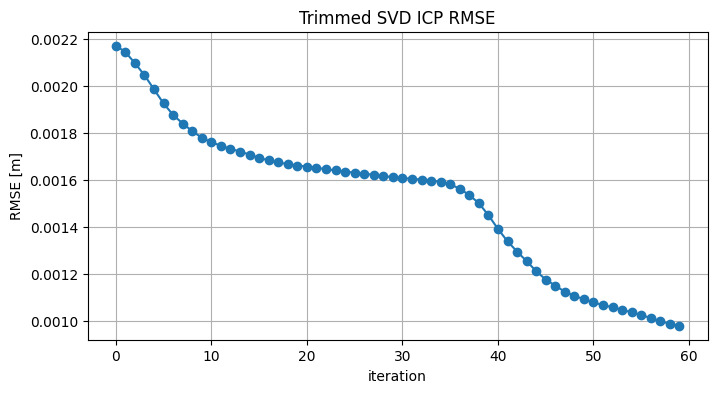

[SAVE] aligned: C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\test_duplo_svd_icp_aligned_result.ply
[SAVE] initial: C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\test_duplo_svd_icp_initial_result.ply
[SAVE] target : C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\test_duplo_svd_icp_target_crop.ply


In [50]:
# ============================================================
# 11. 시각화용 point cloud 생성
# ============================================================
source_initial_pts = transform_points(source_pts_centered, T_init)
source_final_pts = transform_points(source_pts_centered, T_icp)

source_initial_pcd = o3d.geometry.PointCloud()
source_initial_pcd.points = o3d.utility.Vector3dVector(source_initial_pts)
source_initial_pcd.paint_uniform_color([1.0, 0.8, 0.0])  # 노랑

source_final_pcd = o3d.geometry.PointCloud()
source_final_pcd.points = o3d.utility.Vector3dVector(source_final_pts)
source_final_pcd.paint_uniform_color([0.0, 1.0, 0.0])  # 초록

target_vis = o3d.geometry.PointCloud(target_obj_pcd)
target_vis.paint_uniform_color([1.0, 0.0, 0.0])  # 빨강

map_plane_vis = o3d.geometry.PointCloud(map_pcd)
map_plane_vis.paint_uniform_color([0.6, 0.6, 0.6])

axis_world = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.03, origin=[0, 0, 0])

target_axis = make_axis_lines(target_centroid, target_R_pca, scale=0.025)
init_axis = make_axis_lines(T_init[:3, 3], T_init[:3, :3], scale=0.025)
final_axis = make_axis_lines(T_icp[:3, 3], T_icp[:3, :3], scale=0.025)

print("[VIEW] 빨강=target protruding points, 노랑=초기 CAD, 초록=ICP 후 CAD")
o3d.visualization.draw_geometries(
    [
        map_plane_vis,
        target_vis,
        source_initial_pcd,
        source_final_pcd,
        axis_world,
        target_axis,
        init_axis,
        final_axis,
    ],
    window_name="SVD ICP result: target red, init yellow, final green"
)


# ============================================================
# 12. ICP 수렴 그래프
# ============================================================
iters = [h["iter"] for h in icp_history]
rmses = [h["rmse"] for h in icp_history]

plt.figure(figsize=(8, 4))
plt.plot(iters, rmses, marker="o")
plt.xlabel("iteration")
plt.ylabel("RMSE [m]")
plt.title("Trimmed SVD ICP RMSE")
plt.grid(True)
plt.show()


# ============================================================
# 13. 결과 저장
# ============================================================
out_dir = cad_path.parent
aligned_out = out_dir / "test_duplo_svd_icp_aligned_result.ply"
init_out = out_dir / "test_duplo_svd_icp_initial_result.ply"
target_out = out_dir / "test_duplo_svd_icp_target_crop.ply"

o3d.io.write_point_cloud(str(aligned_out), source_final_pcd)
o3d.io.write_point_cloud(str(init_out), source_initial_pcd)
o3d.io.write_point_cloud(str(target_out), target_vis)

print("[SAVE] aligned:", aligned_out.resolve())
print("[SAVE] initial:", init_out.resolve())
print("[SAVE] target :", target_out.resolve())

## FPFH 기반 시각화

In [51]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

cad_path = Path("../duplo/rendered_duplo_2_edge_preserved_down.ply")

if not cad_path.exists():
    raise FileNotFoundError(f"파일 없음: {cad_path.resolve()}")

pcd = o3d.io.read_point_cloud(str(cad_path))

if len(pcd.points) == 0:
    raise RuntimeError("CAD point cloud가 비어 있습니다.")

points = np.asarray(pcd.points)

print("[INFO] CAD:", cad_path.resolve())
print("[INFO] points:", len(points))
print("[INFO] min xyz:", points.min(axis=0))
print("[INFO] max xyz:", points.max(axis=0))
print("[INFO] size   :", points.max(axis=0) - points.min(axis=0))

# 이미 적당히 downsample 되어 있지만, FPFH용으로 한 번 더 균일화
voxel_size = 0.0015  # 1.5 mm
pcd_ds = pcd.voxel_down_sample(voxel_size=voxel_size)

print("[INFO] downsampled points:", len(pcd_ds.points))

# 노멀 계산
normal_radius = voxel_size * 3.0   # 약 4.5mm
pcd_ds.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(
        radius=normal_radius,
        max_nn=30
    )
)

# CAD라 방향 정렬 시도 가능. 너무 느리면 주석 처리해도 됨.
try:
    pcd_ds.orient_normals_consistent_tangent_plane(20)
except Exception as e:
    print("[WARN] normal orientation failed:", e)

axis = o3d.geometry.TriangleMesh.create_coordinate_frame(
    size=0.02,
    origin=[0, 0, 0]
)

o3d.visualization.draw_geometries(
    [pcd_ds, axis],
    window_name="CAD downsampled with normals",
    point_show_normal=False
)

[INFO] CAD: C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\rendered_duplo_2_edge_preserved_down.ply
[INFO] points: 8398
[INFO] min xyz: [-0.01583988 -0.01583959 -0.01196356]
[INFO] max xyz: [0.01583948 0.01583978 0.01139212]
[INFO] size   : [0.03167936 0.03167936 0.02335568]
[INFO] downsampled points: 3584


[INFO] FPFH shape: (3584, 33)
[INFO] score min/max: 0.0 0.9999999999999936
[INFO] score percentile 90: 0.6878557869921128
[INFO] score percentile 95: 0.789547037391064


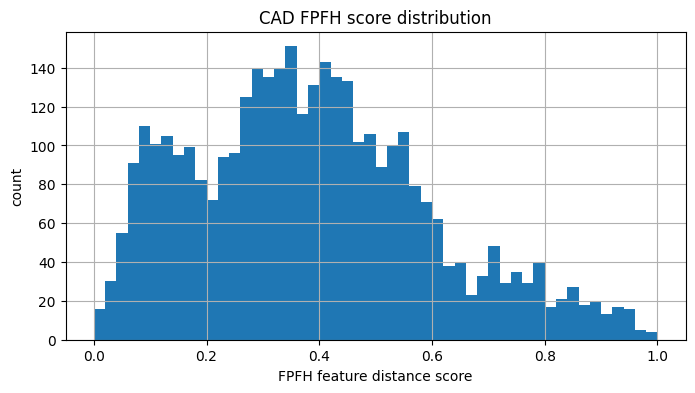

In [52]:
# ============================================================
# FPFH 계산
# ============================================================
feature_radius = voxel_size * 8.0  # 약 12mm

fpfh = o3d.pipelines.registration.compute_fpfh_feature(
    pcd_ds,
    search_param=o3d.geometry.KDTreeSearchParamHybrid(
        radius=feature_radius,
        max_nn=100
    )
)

# Open3D FPFH shape: 33 x N
fpfh_np = np.asarray(fpfh.data).T  # N x 33

print("[INFO] FPFH shape:", fpfh_np.shape)

# ============================================================
# 특징 score 계산
# 평균 descriptor에서 멀수록 독특한 local geometry
# studs, edge, corner 쪽이 상대적으로 커질 가능성이 있음
# ============================================================
fpfh_mean = fpfh_np.mean(axis=0, keepdims=True)
feature_dist = np.linalg.norm(fpfh_np - fpfh_mean, axis=1)

# 0~1 정규화
score = feature_dist.copy()
score = (score - score.min()) / (score.max() - score.min() + 1e-12)

print("[INFO] score min/max:", score.min(), score.max())
print("[INFO] score percentile 90:", np.percentile(score, 90))
print("[INFO] score percentile 95:", np.percentile(score, 95))

# ============================================================
# score를 색으로 입히기
# ============================================================
cmap = plt.get_cmap("turbo")
colors = cmap(score)[:, :3]

pcd_fpfh_color = o3d.geometry.PointCloud()
pcd_fpfh_color.points = pcd_ds.points
pcd_fpfh_color.colors = o3d.utility.Vector3dVector(colors)

axis = o3d.geometry.TriangleMesh.create_coordinate_frame(
    size=0.02,
    origin=[0, 0, 0]
)

o3d.visualization.draw_geometries(
    [pcd_fpfh_color, axis],
    window_name="CAD FPFH feature distance color"
)

# 히스토그램
plt.figure(figsize=(8, 4))
plt.hist(score, bins=50)
plt.xlabel("FPFH feature distance score")
plt.ylabel("count")
plt.title("CAD FPFH score distribution")
plt.grid(True)
plt.show()

In [53]:
# ============================================================
# 상위 FPFH 특징점 선택
# ============================================================
top_percent = 10.0  # 상위 10%
threshold = np.percentile(score, 100.0 - top_percent)

key_mask = score >= threshold
key_indices = np.where(key_mask)[0]

print("[INFO] keypoint threshold:", threshold)
print("[INFO] keypoint count:", len(key_indices))

key_pcd = pcd_ds.select_by_index(key_indices)
key_pcd.paint_uniform_color([1.0, 0.0, 0.0])  # 빨강

base_pcd = o3d.geometry.PointCloud(pcd_ds)
base_pcd.paint_uniform_color([0.6, 0.6, 0.6])  # 회색

axis = o3d.geometry.TriangleMesh.create_coordinate_frame(
    size=0.02,
    origin=[0, 0, 0]
)

o3d.visualization.draw_geometries(
    [base_pcd, key_pcd, axis],
    window_name="CAD FPFH keypoints: red = high FPFH score"
)

# 저장
out_key_path = cad_path.with_name(cad_path.stem + "_fpfh_keypoints.ply")
out_color_path = cad_path.with_name(cad_path.stem + "_fpfh_colored.ply")

o3d.io.write_point_cloud(str(out_key_path), key_pcd)
o3d.io.write_point_cloud(str(out_color_path), pcd_fpfh_color)

print("[SAVE] keypoints:", out_key_path.resolve())
print("[SAVE] colored  :", out_color_path.resolve())

[INFO] keypoint threshold: 0.6878557869921128
[INFO] keypoint count: 359
[SAVE] keypoints: C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\rendered_duplo_2_edge_preserved_down_fpfh_keypoints.ply
[SAVE] colored  : C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\rendered_duplo_2_edge_preserved_down_fpfh_colored.ply


---

## 가짜맵에서 뎁스 잘라서 fpfh를 찾아보기

In [54]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 경로
# ============================================================
map_path = Path("../duplo/test_duplo_pose_topdown_visible_buried.ply")

if not map_path.exists():
    raise FileNotFoundError(f"파일 없음: {map_path.resolve()}")

map_pcd = o3d.io.read_point_cloud(str(map_path))

if len(map_pcd.points) == 0:
    raise RuntimeError("가짜맵 point cloud가 비어 있습니다.")

map_pts = np.asarray(map_pcd.points)

print("[INFO] MAP:", map_path.resolve())
print("[INFO] map points:", len(map_pts))
print("[INFO] min:", map_pts.min(axis=0))
print("[INFO] max:", map_pts.max(axis=0))
print("[INFO] size:", map_pts.max(axis=0) - map_pts.min(axis=0))

# ============================================================
# z=0 평면보다 튀어나온 점만 추출
# ============================================================
plane_z = 0.0
z_threshold = 0.001  # 1mm 이상 튀어나온 점

obj_mask = map_pts[:, 2] > plane_z + z_threshold
obj_pts = map_pts[obj_mask]

print("[INFO] protruding points:", len(obj_pts))

if len(obj_pts) < 30:
    raise RuntimeError("튀어나온 점이 너무 적습니다. z_threshold를 낮춰보세요.")

obj_pcd = o3d.geometry.PointCloud()
obj_pcd.points = o3d.utility.Vector3dVector(obj_pts)
obj_pcd.paint_uniform_color([1.0, 0.0, 0.0])

# 전체 맵은 회색
map_vis = o3d.geometry.PointCloud(map_pcd)
map_vis.paint_uniform_color([0.65, 0.65, 0.65])

axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.03, origin=[0, 0, 0])

o3d.visualization.draw_geometries(
    [map_vis, obj_pcd, axis],
    window_name="Fake map + protruding object points"
)

[INFO] MAP: C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\test_duplo_pose_topdown_visible_buried.ply
[INFO] map points: 4489
[INFO] min: [-0.06 -0.06  0.  ]
[INFO] max: [0.06       0.06       0.05135511]
[INFO] size: [0.12       0.12       0.05135511]
[INFO] protruding points: 1024


[INFO] obj_ds points: 596
[INFO] FPFH shape: (596, 33)
[INFO] score min/max: 0.0 0.99999999999999
[INFO] score p90: 0.7233481423903548
[INFO] score p95: 0.8234433896845479


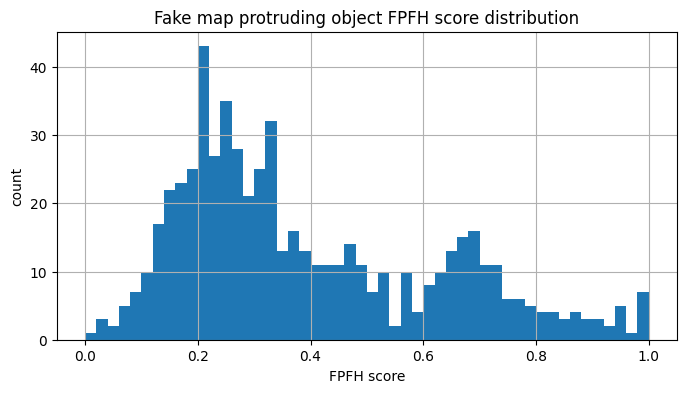

In [55]:
# ============================================================
# FPFH용 다운샘플
# ============================================================
voxel_size = 0.0015  # 1.5mm

obj_ds = obj_pcd.voxel_down_sample(voxel_size=voxel_size)

print("[INFO] obj_ds points:", len(obj_ds.points))

# ============================================================
# 노멀 계산
# ============================================================
normal_radius = voxel_size * 3.0  # 약 4.5mm

obj_ds.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(
        radius=normal_radius,
        max_nn=30
    )
)

try:
    obj_ds.orient_normals_consistent_tangent_plane(20)
except Exception as e:
    print("[WARN] normal orientation failed:", e)

# ============================================================
# FPFH 계산
# ============================================================
feature_radius = voxel_size * 8.0  # 약 12mm

fpfh = o3d.pipelines.registration.compute_fpfh_feature(
    obj_ds,
    search_param=o3d.geometry.KDTreeSearchParamHybrid(
        radius=feature_radius,
        max_nn=100
    )
)

fpfh_np = np.asarray(fpfh.data).T  # N x 33

print("[INFO] FPFH shape:", fpfh_np.shape)

# ============================================================
# FPFH 특징 강도 score
# 평균 descriptor와의 거리
# ============================================================
fpfh_mean = fpfh_np.mean(axis=0, keepdims=True)
feature_dist = np.linalg.norm(fpfh_np - fpfh_mean, axis=1)

score = feature_dist.copy()
score = (score - score.min()) / (score.max() - score.min() + 1e-12)

print("[INFO] score min/max:", score.min(), score.max())
print("[INFO] score p90:", np.percentile(score, 90))
print("[INFO] score p95:", np.percentile(score, 95))

# ============================================================
# 색상 시각화
# ============================================================
cmap = plt.get_cmap("turbo")
colors = cmap(score)[:, :3]

obj_fpfh_color = o3d.geometry.PointCloud()
obj_fpfh_color.points = obj_ds.points
obj_fpfh_color.colors = o3d.utility.Vector3dVector(colors)

axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.03, origin=[0, 0, 0])

o3d.visualization.draw_geometries(
    [obj_fpfh_color, axis],
    window_name="Fake map protruding object FPFH score"
)

plt.figure(figsize=(8, 4))
plt.hist(score, bins=50)
plt.xlabel("FPFH score")
plt.ylabel("count")
plt.title("Fake map protruding object FPFH score distribution")
plt.grid(True)
plt.show()

In [56]:
# ============================================================
# 상위 FPFH 특징점 추출
# ============================================================
top_percent = 10.0
threshold = np.percentile(score, 100.0 - top_percent)

key_mask = score >= threshold
key_indices = np.where(key_mask)[0]

print("[INFO] key threshold:", threshold)
print("[INFO] key count:", len(key_indices))

key_pcd = obj_ds.select_by_index(key_indices)
key_pcd.paint_uniform_color([1.0, 0.0, 0.0])  # 빨강

base_pcd = o3d.geometry.PointCloud(obj_ds)
base_pcd.paint_uniform_color([0.6, 0.6, 0.6])

axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.03, origin=[0, 0, 0])

o3d.visualization.draw_geometries(
    [base_pcd, key_pcd, axis],
    window_name="Fake map FPFH keypoints: red = high score"
)

# 저장
out_key_path = map_path.with_name(map_path.stem + "_protruding_fpfh_keypoints.ply")
out_color_path = map_path.with_name(map_path.stem + "_protruding_fpfh_colored.ply")

o3d.io.write_point_cloud(str(out_key_path), key_pcd)
o3d.io.write_point_cloud(str(out_color_path), obj_fpfh_color)

print("[SAVE] keypoints:", out_key_path.resolve())
print("[SAVE] colored:", out_color_path.resolve())

[INFO] key threshold: 0.7233481423903548
[INFO] key count: 60
[SAVE] keypoints: C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\test_duplo_pose_topdown_visible_buried_protruding_fpfh_keypoints.ply
[SAVE] colored: C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\test_duplo_pose_topdown_visible_buried_protruding_fpfh_colored.ply


### 가짜맵 로드 + fpfh 계산

In [57]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial import cKDTree
from sklearn.decomposition import PCA
import random


# ============================================================
# 0. 경로
# ============================================================
cad_path = Path("../duplo/rendered_duplo_2_edge_preserved_down.ply")
map_path = Path("../duplo/test_duplo_pose_topdown_visible_buried.ply")

if not cad_path.exists():
    raise FileNotFoundError(f"CAD 없음: {cad_path.resolve()}")

if not map_path.exists():
    raise FileNotFoundError(f"MAP 없음: {map_path.resolve()}")

print("[INFO] CAD:", cad_path.resolve())
print("[INFO] MAP:", map_path.resolve())


# ============================================================
# 1. 로드
# ============================================================
cad_pcd_raw = o3d.io.read_point_cloud(str(cad_path))
map_pcd_raw = o3d.io.read_point_cloud(str(map_path))

cad_pts_raw = np.asarray(cad_pcd_raw.points)
map_pts_raw = np.asarray(map_pcd_raw.points)

print("[INFO] cad raw:", len(cad_pts_raw))
print("[INFO] map raw:", len(map_pts_raw))


# ============================================================
# 2. CAD 중심을 원점으로 이동
# ============================================================
cad_center = cad_pts_raw.mean(axis=0)
cad_pts_centered = cad_pts_raw - cad_center

cad_model_pcd = o3d.geometry.PointCloud()
cad_model_pcd.points = o3d.utility.Vector3dVector(cad_pts_centered)
cad_model_pcd.paint_uniform_color([0.0, 0.8, 1.0])

print("[INFO] cad_center:", cad_center)


# ============================================================
# 3. 가짜맵에서 튀어나온 부분만 추출
# ============================================================
plane_z = 0.0
z_threshold = 0.001

map_pts = np.asarray(map_pcd_raw.points)
target_mask = map_pts[:, 2] > plane_z + z_threshold
target_pts = map_pts[target_mask]

target_pcd = o3d.geometry.PointCloud()
target_pcd.points = o3d.utility.Vector3dVector(target_pts)
target_pcd.paint_uniform_color([1.0, 0.0, 0.0])

print("[INFO] protruding target points:", len(target_pts))

if len(target_pts) < 30:
    raise RuntimeError("튀어나온 target point가 너무 적음. z_threshold 낮춰봐.")


# ============================================================
# 4. FPFH 계산 함수
# ============================================================
def compute_fpfh_with_score(pcd, voxel_size=0.0015):
    pcd_ds = pcd.voxel_down_sample(voxel_size=voxel_size)

    normal_radius = voxel_size * 3.0
    feature_radius = voxel_size * 8.0

    pcd_ds.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(
            radius=normal_radius,
            max_nn=30
        )
    )

    try:
        pcd_ds.orient_normals_consistent_tangent_plane(20)
    except Exception as e:
        print("[WARN] orient_normals failed:", e)

    fpfh = o3d.pipelines.registration.compute_fpfh_feature(
        pcd_ds,
        search_param=o3d.geometry.KDTreeSearchParamHybrid(
            radius=feature_radius,
            max_nn=100
        )
    )

    fpfh_np = np.asarray(fpfh.data).T  # N x 33

    mean_desc = fpfh_np.mean(axis=0, keepdims=True)
    score = np.linalg.norm(fpfh_np - mean_desc, axis=1)
    score = (score - score.min()) / (score.max() - score.min() + 1e-12)

    return pcd_ds, fpfh_np, score


voxel_size = 0.0015

cad_ds, cad_fpfh, cad_score = compute_fpfh_with_score(cad_model_pcd, voxel_size)
target_ds, target_fpfh, target_score = compute_fpfh_with_score(target_pcd, voxel_size)

print("[INFO] cad_ds:", len(cad_ds.points), cad_fpfh.shape)
print("[INFO] target_ds:", len(target_ds.points), target_fpfh.shape)


# ============================================================
# 5. 상위 FPFH 점 추출
# ============================================================
def select_top_fpfh_points(pcd, fpfh_np, score, top_percent=15.0):
    th = np.percentile(score, 100.0 - top_percent)
    idx = np.where(score >= th)[0]

    key_pcd = pcd.select_by_index(idx)
    key_fpfh = fpfh_np[idx]
    key_score = score[idx]
    
    return key_pcd, key_fpfh, key_score, idx, th


top_percent = 30.0

cad_key_pcd, cad_key_fpfh, cad_key_score, cad_key_idx, cad_th = select_top_fpfh_points(
    cad_ds, cad_fpfh, cad_score, top_percent
)

target_key_pcd, target_key_fpfh, target_key_score, target_key_idx, target_th = select_top_fpfh_points(
    target_ds, target_fpfh, target_score, top_percent
)

print("[INFO] cad keypoints:", len(cad_key_pcd.points), "threshold:", cad_th)
print("[INFO] target keypoints:", len(target_key_pcd.points), "threshold:", target_th)


# ============================================================
# 6. 확인 시각화
# ============================================================
cad_base_vis = o3d.geometry.PointCloud(cad_ds)
cad_base_vis.paint_uniform_color([0.55, 0.55, 0.55])

cad_key_vis = o3d.geometry.PointCloud(cad_key_pcd)
cad_key_vis.paint_uniform_color([1.0, 0.0, 0.0])

target_base_vis = o3d.geometry.PointCloud(target_ds)
target_base_vis.paint_uniform_color([0.55, 0.55, 0.55])

target_key_vis = o3d.geometry.PointCloud(target_key_pcd)
target_key_vis.paint_uniform_color([1.0, 0.0, 0.0])

axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.03)

print("[VIEW] CAD keypoints")
o3d.visualization.draw_geometries(
    [cad_base_vis, cad_key_vis, axis],
    window_name="CAD FPFH keypoints"
)

print("[VIEW] Target map keypoints")
o3d.visualization.draw_geometries(
    [target_base_vis, target_key_vis, axis],
    window_name="Target FPFH keypoints"
)

[INFO] CAD: C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\rendered_duplo_2_edge_preserved_down.ply
[INFO] MAP: C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\test_duplo_pose_topdown_visible_buried.ply
[INFO] cad raw: 8398
[INFO] map raw: 4489
[INFO] cad_center: [-1.13729410e-04 -1.05128950e-04  3.70114943e-05]
[INFO] protruding target points: 1024
[INFO] cad_ds: 3584 (3584, 33)
[INFO] target_ds: 596 (596, 33)
[INFO] cad keypoints: 1075 threshold: 0.4817422159295509
[INFO] target keypoints: 179 threshold: 0.4814335727028507
[VIEW] CAD keypoints
[VIEW] Target map keypoints


In [58]:
# ============================================================
# 1. FPFH descriptor matching
# CAD keypoint descriptor -> Target keypoint descriptor
# ============================================================
def match_fpfh_descriptors(src_desc, dst_desc, ratio=0.90):
    """
    src_desc: Ns x 33
    dst_desc: Nd x 33
    return: list of (src_idx, dst_idx, dist)
    """
    tree = cKDTree(dst_desc)

    dists, idxs = tree.query(src_desc, k=2)

    matches = []
    for i in range(len(src_desc)):
        d1, d2 = dists[i]
        j1, j2 = idxs[i]

        if d2 <= 1e-12:
            continue

        if d1 / d2 < ratio:
            matches.append((i, int(j1), float(d1)))

    return matches


matches = match_fpfh_descriptors(
    cad_key_fpfh,
    target_key_fpfh,
    ratio=0.95
)

print("[INFO] raw descriptor matches:", len(matches))

if len(matches) < 3:
    raise RuntimeError("FPFH 매칭이 3개 미만. top_percent 또는 ratio를 조정해야 함.")


src_key_pts = np.asarray(cad_key_pcd.points)
dst_key_pts = np.asarray(target_key_pcd.points)

src_match_pts = np.array([src_key_pts[i] for i, j, d in matches])
dst_match_pts = np.array([dst_key_pts[j] for i, j, d in matches])

print("[INFO] src_match_pts:", src_match_pts.shape)
print("[INFO] dst_match_pts:", dst_match_pts.shape)


# ============================================================
# 2. SVD rigid transform
# ============================================================
def estimate_transform_svd(src, dst):
    src = np.asarray(src)
    dst = np.asarray(dst)

    src_mean = src.mean(axis=0)
    dst_mean = dst.mean(axis=0)

    src_c = src - src_mean
    dst_c = dst - dst_mean

    H = src_c.T @ dst_c

    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T

    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T

    t = dst_mean - R @ src_mean

    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = t

    return T


def transform_points(points, T):
    return (T[:3, :3] @ points.T).T + T[:3, 3]


# ============================================================
# 3. RANSAC with SVD
# ============================================================
def ransac_svd_registration(
    src_corr,
    dst_corr,
    num_iter=3000,
    sample_size=3,
    inlier_thresh=0.004,
    min_inliers=8,
    random_seed=0
):
    np.random.seed(random_seed)
    random.seed(random_seed)

    n = len(src_corr)

    best_T = None
    best_inliers = None
    best_rmse = np.inf

    if n < sample_size:
        raise RuntimeError("correspondence 수가 sample_size보다 작음")

    all_indices = np.arange(n)

    for it in range(num_iter):
        sample_idx = np.random.choice(all_indices, size=sample_size, replace=False)

        try:
            T = estimate_transform_svd(src_corr[sample_idx], dst_corr[sample_idx])
        except Exception:
            continue

        src_tf = transform_points(src_corr, T)
        errors = np.linalg.norm(src_tf - dst_corr, axis=1)

        inliers = np.where(errors < inlier_thresh)[0]

        if len(inliers) < min_inliers:
            continue

        # inlier 전체로 T 재계산
        T_refined = estimate_transform_svd(src_corr[inliers], dst_corr[inliers])
        src_tf_refined = transform_points(src_corr[inliers], T_refined)
        rmse = np.sqrt(np.mean(np.sum((src_tf_refined - dst_corr[inliers]) ** 2, axis=1)))

        if len(inliers) > 0:
            better = False

            if best_inliers is None:
                better = True
            elif len(inliers) > len(best_inliers):
                better = True
            elif len(inliers) == len(best_inliers) and rmse < best_rmse:
                better = True

            if better:
                best_T = T_refined
                best_inliers = inliers
                best_rmse = rmse

    if best_T is None:
        raise RuntimeError(
            "RANSAC 실패. inlier_thresh를 키우거나, ratio/top_percent를 완화해봐."
        )

    return best_T, best_inliers, best_rmse


T_ransac, inlier_idx, ransac_rmse = ransac_svd_registration(
    src_match_pts,
    dst_match_pts,
    num_iter=5000,
    sample_size=3,
    inlier_thresh=0.006,  # 6mm
    min_inliers=6,
    random_seed=42
)

print("\n[RANSAC RESULT]")
print("inliers:", len(inlier_idx), "/", len(matches))
print("rmse:", ransac_rmse)
print("T_ransac:\n", T_ransac)


# ============================================================
# 4. inlier correspondence line 시각화
# ============================================================
src_inlier = src_match_pts[inlier_idx]
dst_inlier = dst_match_pts[inlier_idx]
src_inlier_tf = transform_points(src_inlier, T_ransac)

# line set: transformed source inlier ↔ target inlier
line_points = np.vstack([src_inlier_tf, dst_inlier])
n_in = len(src_inlier_tf)

lines = []
for k in range(n_in):
    lines.append([k, k + n_in])

line_set = o3d.geometry.LineSet()
line_set.points = o3d.utility.Vector3dVector(line_points)
line_set.lines = o3d.utility.Vector2iVector(lines)
line_set.colors = o3d.utility.Vector3dVector([[1, 1, 0] for _ in lines])

# 전체 CAD를 RANSAC 결과로 이동
cad_ransac_pts = transform_points(np.asarray(cad_ds.points), T_ransac)
cad_ransac_pcd = o3d.geometry.PointCloud()
cad_ransac_pcd.points = o3d.utility.Vector3dVector(cad_ransac_pts)
cad_ransac_pcd.paint_uniform_color([0.0, 1.0, 0.0])

target_vis = o3d.geometry.PointCloud(target_ds)
target_vis.paint_uniform_color([1.0, 0.0, 0.0])

axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.03)

print("[VIEW] FPFH RANSAC result: green=CAD transformed, red=target, yellow=inlier lines")
o3d.visualization.draw_geometries(
    [target_vis, cad_ransac_pcd, line_set, axis],
    window_name="FPFH matches + SVD RANSAC"
)

[INFO] raw descriptor matches: 338
[INFO] src_match_pts: (338, 3)
[INFO] dst_match_pts: (338, 3)

[RANSAC RESULT]
inliers: 50 / 338
rmse: 0.003981503149027857
T_ransac:
 [[-0.02410381  0.98592076  0.16546678  0.02527633]
 [-0.77727451  0.08560716 -0.62331032  0.01295977]
 [-0.62869973 -0.14363726  0.76426762  0.04014202]
 [ 0.          0.          0.          1.        ]]
[VIEW] FPFH RANSAC result: green=CAD transformed, red=target, yellow=inlier lines


[Visible ICP] outer=00 | visible=3584 | fitness=0.4456 | rmse=0.002785
[Visible ICP] outer=01 | visible=3584 | fitness=0.5407 | rmse=0.002739
[Visible ICP] outer=02 | visible=3584 | fitness=0.5837 | rmse=0.002833
[Visible ICP] outer=03 | visible=3584 | fitness=0.5993 | rmse=0.002571
[Visible ICP] outer=04 | visible=3584 | fitness=0.5910 | rmse=0.002485
[Visible ICP] outer=05 | visible=3584 | fitness=0.5910 | rmse=0.002485
[Visible ICP] outer=06 | visible=3584 | fitness=0.5910 | rmse=0.002485
[Visible ICP] outer=07 | visible=3584 | fitness=0.5910 | rmse=0.002485
[Visible ICP] outer=08 | visible=3584 | fitness=0.5910 | rmse=0.002485
[Visible ICP] outer=09 | visible=3584 | fitness=0.5910 | rmse=0.002485
[Visible ICP] outer=10 | visible=3584 | fitness=0.5910 | rmse=0.002485
[Visible ICP] outer=11 | visible=3584 | fitness=0.5910 | rmse=0.002485
[Visible ICP] outer=12 | visible=3584 | fitness=0.5910 | rmse=0.002485
[Visible ICP] outer=13 | visible=3584 | fitness=0.5910 | rmse=0.002485
[Visib

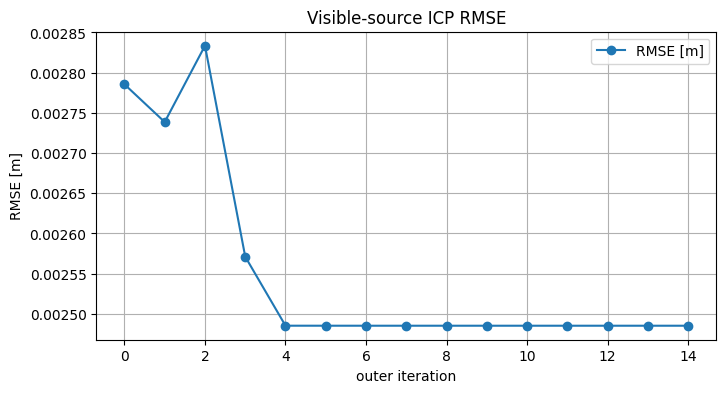

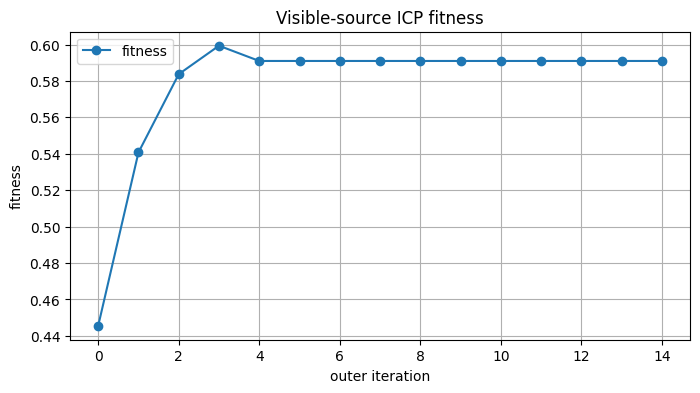

[SAVE] ransac init : C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\fpfh_ransac_init_result.ply
[SAVE] final CAD   : C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\fpfh_visible_icp_final_result.ply
[SAVE] visible CAD : C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\fpfh_visible_icp_visible_source_only.ply
[SAVE] target      : C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\fpfh_target_protruding_crop.ply


In [ ]:
# ============================================================
# ICP refine
# target은 partial이라 point-to-point로 가볍게 먼저
# ============================================================
source_for_icp = o3d.geometry.PointCloud(cad_ds)
target_for_icp = o3d.geometry.PointCloud(target_ds)

source_for_icp.paint_uniform_color([0.0, 1.0, 0.0])
target_for_icp.paint_uniform_color([1.0, 0.0, 0.0])

icp_threshold = 0.006  # 6mm

result_icp = o3d.pipelines.registration.registration_icp(
    source_for_icp,
    target_for_icp,
    icp_threshold,
    T_ransac,
    o3d.pipelines.registration.TransformationEstimationPointToPoint(),
    o3d.pipelines.registration.ICPConvergenceCriteria(
        max_iteration=80
    )
)

T_icp = result_icp.transformation

print("[ICP RESULT]")
print("fitness:", result_icp.fitness)
print("inlier_rmse:", result_icp.inlier_rmse)
print("T_icp:\n", T_icp)


# ============================================================
# 최종 결과 시각화
# ============================================================
cad_init_pts = transform_points(np.asarray(cad_ds.points), T_ransac)
cad_final_pts = transform_points(np.asarray(cad_ds.points), T_icp)

cad_init_pcd = o3d.geometry.PointCloud()
cad_init_pcd.points = o3d.utility.Vector3dVector(cad_init_pts)
cad_init_pcd.paint_uniform_color([1.0, 0.8, 0.0])  # 노랑

cad_final_pcd = o3d.geometry.PointCloud()
cad_final_pcd.points = o3d.utility.Vector3dVector(cad_final_pts)
cad_final_pcd.paint_uniform_color([0.0, 1.0, 0.0])  # 초록

target_vis = o3d.geometry.PointCloud(target_ds)
target_vis.paint_uniform_color([1.0, 0.0, 0.0])  # 빨강

map_vis = o3d.geometry.PointCloud(map_pcd_raw)
map_vis.paint_uniform_color([0.65, 0.65, 0.65])

axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.03)

print("[VIEW] red=target protruding, yellow=RANSAC init, green=ICP final")
o3d.visualization.draw_geometries(
    [map_vis, target_vis, cad_init_pcd, cad_final_pcd, axis],
    window_name="FPFH RANSAC + ICP final result"
)


# ============================================================
# 저장
# ============================================================
out_dir = cad_path.parent

out_init = out_dir / "fpfh_ransac_init_result.ply"
out_final = out_dir / "fpfh_icp_final_result.ply"
out_target = out_dir / "fpfh_target_protruding_crop.ply"

o3d.io.write_point_cloud(str(out_init), cad_init_pcd)
o3d.io.write_point_cloud(str(out_final), cad_final_pcd)
o3d.io.write_point_cloud(str(out_target), target_vis)

print("[SAVE] init :", out_init.resolve())
print("[SAVE] final:", out_final.resolve())
print("[SAVE] target:", out_target.resolve())

[Visible ICP] outer=00 | visible=3584 | fitness=0.4456 | rmse=0.002785
[Visible ICP] outer=01 | visible=3584 | fitness=0.5407 | rmse=0.002739
[Visible ICP] outer=02 | visible=3584 | fitness=0.5837 | rmse=0.002833
[Visible ICP] outer=03 | visible=3584 | fitness=0.5993 | rmse=0.002571
[Visible ICP] outer=04 | visible=3584 | fitness=0.5910 | rmse=0.002485
[Visible ICP] outer=05 | visible=3584 | fitness=0.5910 | rmse=0.002485
[Visible ICP] outer=06 | visible=3584 | fitness=0.5910 | rmse=0.002485
[Visible ICP] outer=07 | visible=3584 | fitness=0.5910 | rmse=0.002485
[Visible ICP] outer=08 | visible=3584 | fitness=0.5910 | rmse=0.002485
[Visible ICP] outer=09 | visible=3584 | fitness=0.5910 | rmse=0.002485
[Visible ICP] outer=10 | visible=3584 | fitness=0.5910 | rmse=0.002485
[Visible ICP] outer=11 | visible=3584 | fitness=0.5910 | rmse=0.002485
[Visible ICP] outer=12 | visible=3584 | fitness=0.5910 | rmse=0.002485
[Visible ICP] outer=13 | visible=3584 | fitness=0.5910 | rmse=0.002485
[Visib

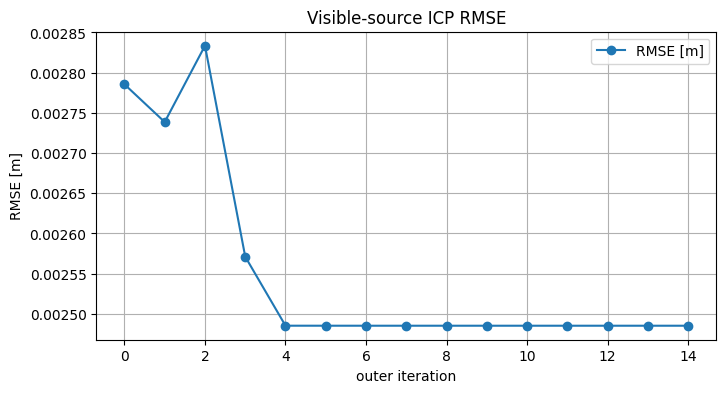

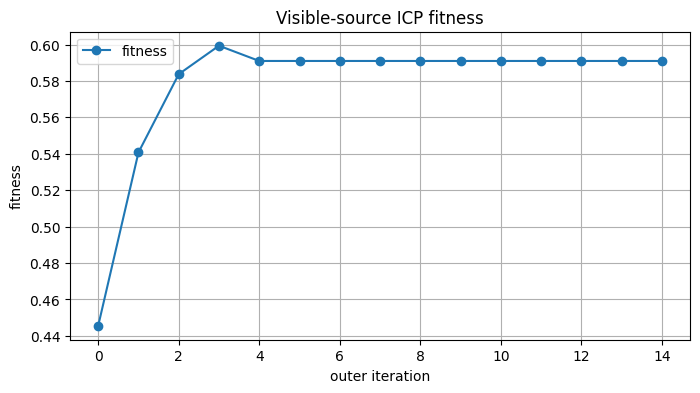

[SAVE] ransac init : C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\fpfh_ransac_init_result.ply
[SAVE] final CAD   : C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\fpfh_visible_icp_final_result.ply
[SAVE] visible CAD : C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\fpfh_visible_icp_visible_source_only.ply
[SAVE] target      : C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\fpfh_target_protruding_crop.ply


In [62]:
# ============================================================
# 셀 3 — Visible-source ICP refine + 최종 시각화
# ============================================================

import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 0. 사전 체크
# ------------------------------------------------------------
required_vars = [
    "cad_ds",
    "target_ds",
    "map_pcd_raw",
    "T_ransac",
    "transform_points",
    "cad_path",
]

for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"{v} 변수가 없습니다. 셀 1, 셀 2를 먼저 실행하세요.")


# ------------------------------------------------------------
# 1. 현재 pose 기준으로 CAD 중 z=0 평면 위에 보이는 점만 추출
# ------------------------------------------------------------
def make_visible_source_pcd(source_points, T, plane_z=0.0, z_margin=0.0005):
    """
    source_points: CAD 점군. 아직 변환 전 좌표.
    T: 현재 추정 pose.
    plane_z: 묻힌 평면 높이. 여기서는 z=0.
    z_margin: 평면보다 살짝 위에 있는 점만 사용하기 위한 여유값.

    return:
        visible_pcd: 현재 T로 변환한 뒤 z > plane_z + margin 인 점군
        full_pcd: 현재 T로 변환한 전체 CAD 점군
        visible_mask: visible 점 mask
    """
    src_tf = transform_points(source_points, T)

    visible_mask = src_tf[:, 2] > plane_z + z_margin
    visible_pts = src_tf[visible_mask]

    visible_pcd = o3d.geometry.PointCloud()
    visible_pcd.points = o3d.utility.Vector3dVector(visible_pts)

    full_pcd = o3d.geometry.PointCloud()
    full_pcd.points = o3d.utility.Vector3dVector(src_tf)

    return visible_pcd, full_pcd, visible_mask


# ------------------------------------------------------------
# 2. Visible-source ICP 반복
# ------------------------------------------------------------
def visible_source_icp_loop(
    source_points,
    target_pcd,
    T_init,
    plane_z=0.0,
    z_margin=0.0005,
    icp_threshold=0.005,
    outer_iterations=15,
    inner_iterations=30,
):
    """
    핵심:
    1) 현재 T로 CAD 전체를 변환
    2) z=0 평면 위에 있는 CAD 점만 source로 사용
    3) 그 visible CAD만 target에 ICP
    4) delta_T를 전체 T에 누적
    """
    T = T_init.copy()
    target = o3d.geometry.PointCloud(target_pcd)

    history = []

    for outer in range(outer_iterations):
        visible_src, full_src, visible_mask = make_visible_source_pcd(
            source_points,
            T,
            plane_z=plane_z,
            z_margin=z_margin
        )

        n_visible = len(visible_src.points)

        if n_visible < 30:
            print(f"[WARN] visible source point가 너무 적음: {n_visible}")
            break

        # visible_src는 이미 T가 적용된 좌표이므로 ICP 초기값은 identity
        result = o3d.pipelines.registration.registration_icp(
            visible_src,
            target,
            icp_threshold,
            np.eye(4),
            o3d.pipelines.registration.TransformationEstimationPointToPoint(),
            o3d.pipelines.registration.ICPConvergenceCriteria(
                max_iteration=inner_iterations
            )
        )

        delta_T = result.transformation

        # delta_T를 기존 T 앞에 누적
        T = delta_T @ T

        history.append({
            "outer": outer,
            "visible_points": n_visible,
            "fitness": result.fitness,
            "rmse": result.inlier_rmse,
        })

        print(
            f"[Visible ICP] outer={outer:02d} | "
            f"visible={n_visible} | "
            f"fitness={result.fitness:.4f} | "
            f"rmse={result.inlier_rmse:.6f}"
        )

        # 거의 변화 없으면 종료
        if result.inlier_rmse < 0.001:
            print("[Visible ICP] rmse 충분히 작아서 종료")
            break

    return T, history


# ------------------------------------------------------------
# 3. ICP 실행
# ------------------------------------------------------------
source_points = np.asarray(cad_ds.points)
target_pcd_for_icp = o3d.geometry.PointCloud(target_ds)

T_visible_icp, visible_icp_history = visible_source_icp_loop(
    source_points=source_points,
    target_pcd=target_pcd_for_icp,
    T_init=T_ransac,
    plane_z=0.0,
    z_margin=0.0005,
    icp_threshold=0.005,
    outer_iterations=15,
    inner_iterations=30,
)

print("\n[VISIBLE ICP RESULT]")
print(T_visible_icp)


# ------------------------------------------------------------
# 4. 결과 점군 생성
# ------------------------------------------------------------
# RANSAC 초기 결과
cad_ransac_pts = transform_points(source_points, T_ransac)
cad_ransac_pcd = o3d.geometry.PointCloud()
cad_ransac_pcd.points = o3d.utility.Vector3dVector(cad_ransac_pts)
cad_ransac_pcd.paint_uniform_color([1.0, 0.8, 0.0])  # 노랑

# Visible ICP 최종 전체 CAD
cad_final_pts = transform_points(source_points, T_visible_icp)
cad_final_pcd = o3d.geometry.PointCloud()
cad_final_pcd.points = o3d.utility.Vector3dVector(cad_final_pts)
cad_final_pcd.paint_uniform_color([0.0, 1.0, 0.0])  # 초록

# 최종 pose 기준 visible CAD만 따로 표시
cad_visible_only_pcd, _, _ = make_visible_source_pcd(
    source_points,
    T_visible_icp,
    plane_z=0.0,
    z_margin=0.0005
)
cad_visible_only_pcd.paint_uniform_color([0.0, 0.2, 1.0])  # 파랑

# target protruding point
target_vis = o3d.geometry.PointCloud(target_ds)
target_vis.paint_uniform_color([1.0, 0.0, 0.0])  # 빨강

# 전체 map plane
map_vis = o3d.geometry.PointCloud(map_pcd_raw)
map_vis.paint_uniform_color([0.65, 0.65, 0.65])  # 회색

axis = o3d.geometry.TriangleMesh.create_coordinate_frame(
    size=0.03,
    origin=[0, 0, 0]
)


# ------------------------------------------------------------
# 5. 시각화
# ------------------------------------------------------------
print("\n[VIEW]")
print("회색 = 전체 가짜맵")
print("빨강 = target 튀어나온 부분")
print("노랑 = FPFH RANSAC 초기 CAD")
print("초록 = Visible ICP 후 전체 CAD")
print("파랑 = ICP에 실제 사용된 visible CAD")

o3d.visualization.draw_geometries(
    [
        map_vis,
        target_vis,
        cad_ransac_pcd,
        cad_final_pcd,
        cad_visible_only_pcd,
        axis,
    ],
    window_name="Visible-source ICP result"
)


# ------------------------------------------------------------
# 6. RMSE 그래프
# ------------------------------------------------------------
if len(visible_icp_history) > 0:
    xs = [h["outer"] for h in visible_icp_history]
    rmses = [h["rmse"] for h in visible_icp_history]
    fitnesses = [h["fitness"] for h in visible_icp_history]

    plt.figure(figsize=(8, 4))
    plt.plot(xs, rmses, marker="o", label="RMSE [m]")
    plt.xlabel("outer iteration")
    plt.ylabel("RMSE [m]")
    plt.title("Visible-source ICP RMSE")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(xs, fitnesses, marker="o", label="fitness")
    plt.xlabel("outer iteration")
    plt.ylabel("fitness")
    plt.title("Visible-source ICP fitness")
    plt.grid(True)
    plt.legend()
    plt.show()


# ------------------------------------------------------------
# 7. 저장
# ------------------------------------------------------------
out_dir = cad_path.parent

out_ransac = out_dir / "fpfh_ransac_init_result.ply"
out_visible_icp = out_dir / "fpfh_visible_icp_final_result.ply"
out_visible_only = out_dir / "fpfh_visible_icp_visible_source_only.ply"
out_target = out_dir / "fpfh_target_protruding_crop.ply"

o3d.io.write_point_cloud(str(out_ransac), cad_ransac_pcd)
o3d.io.write_point_cloud(str(out_visible_icp), cad_final_pcd)
o3d.io.write_point_cloud(str(out_visible_only), cad_visible_only_pcd)
o3d.io.write_point_cloud(str(out_target), target_vis)

print("[SAVE] ransac init :", out_ransac.resolve())
print("[SAVE] final CAD   :", out_visible_icp.resolve())
print("[SAVE] visible CAD :", out_visible_only.resolve())
print("[SAVE] target      :", out_target.resolve())

## 란삭 후보 생성

In [63]:
import numpy as np
import open3d as o3d
from scipy.spatial import cKDTree
import random


# ============================================================
# 0. 사전 체크
# ============================================================
required_vars = [
    "cad_key_pcd",
    "target_key_pcd",
    "cad_key_fpfh",
    "target_key_fpfh",
    "cad_ds",
    "target_ds",
    "map_pcd_raw",
]

for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"{v} 변수가 없습니다. 셀 1을 먼저 실행하세요.")


# ============================================================
# 1. FPFH descriptor matching
# ============================================================
def match_fpfh_descriptors(src_desc, dst_desc, ratio=0.97):
    """
    src_desc: CAD keypoint FPFH, Ns x 33
    dst_desc: target keypoint FPFH, Nt x 33
    """
    tree = cKDTree(dst_desc)
    dists, idxs = tree.query(src_desc, k=2)

    matches = []

    for i in range(len(src_desc)):
        d1, d2 = dists[i]
        j1, j2 = idxs[i]

        if d2 <= 1e-12:
            continue

        # ratio test
        if d1 / d2 < ratio:
            matches.append((i, int(j1), float(d1)))

    return matches


matches = match_fpfh_descriptors(
    cad_key_fpfh,
    target_key_fpfh,
    ratio=0.97
)

print("[INFO] descriptor matches:", len(matches))

if len(matches) < 3:
    raise RuntimeError("매칭점이 3개 미만입니다. ratio를 0.99로 올리거나 top_percent를 늘려보세요.")


src_key_pts = np.asarray(cad_key_pcd.points)
dst_key_pts = np.asarray(target_key_pcd.points)

src_match_pts = np.array([src_key_pts[i] for i, j, d in matches])
dst_match_pts = np.array([dst_key_pts[j] for i, j, d in matches])

print("[INFO] src_match_pts:", src_match_pts.shape)
print("[INFO] dst_match_pts:", dst_match_pts.shape)


# ============================================================
# 2. SVD rigid transform
# ============================================================
def estimate_transform_svd(src, dst):
    """
    dst ~= R @ src + t
    """
    src = np.asarray(src)
    dst = np.asarray(dst)

    src_mean = src.mean(axis=0)
    dst_mean = dst.mean(axis=0)

    src_c = src - src_mean
    dst_c = dst - dst_mean

    H = src_c.T @ dst_c

    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T

    # reflection 방지
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T

    t = dst_mean - R @ src_mean

    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = t

    return T


def transform_points(points, T):
    return (T[:3, :3] @ points.T).T + T[:3, 3]


# ============================================================
# 3. visible CAD 생성
# ============================================================
def get_visible_cad_points(cad_points, T, plane_z=0.0, z_margin=0.0005):
    """
    현재 pose T에서 z=0 평면 위에 보이는 CAD 포인트만 추출.
    """
    cad_tf = transform_points(cad_points, T)

    visible_mask = cad_tf[:, 2] > plane_z + z_margin
    visible_pts = cad_tf[visible_mask]

    return visible_pts, cad_tf, visible_mask


# ============================================================
# 4. Chamfer score 계산
# ============================================================
def chamfer_score_bidirectional(
    src_visible,
    target_points,
    max_dist_clip=0.020,
):
    """
    src_visible: visible CAD points
    target_points: 관측 target points

    양방향 Chamfer distance.
    너무 먼 대응은 max_dist_clip으로 clip해서 outlier 영향 제한.
    """
    if len(src_visible) < 10 or len(target_points) < 10:
        return np.inf, np.inf, np.inf

    tree_tgt = cKDTree(target_points)
    tree_src = cKDTree(src_visible)

    d_src_to_tgt, _ = tree_tgt.query(src_visible, k=1)
    d_tgt_to_src, _ = tree_src.query(target_points, k=1)

    d_src_to_tgt = np.clip(d_src_to_tgt, 0.0, max_dist_clip)
    d_tgt_to_src = np.clip(d_tgt_to_src, 0.0, max_dist_clip)

    cd1 = float(np.mean(d_src_to_tgt))
    cd2 = float(np.mean(d_tgt_to_src))
    cd = cd1 + cd2

    return cd, cd1, cd2


# ============================================================
# 5. pose 후보 평가 함수
# ============================================================
def evaluate_pose_candidate(
    T,
    cad_points,
    target_points,
    plane_z=0.0,
    z_margin=0.0005,
    visible_ratio_range=(0.05, 0.90),
    center_weight=0.50,
    zrange_weight=0.30,
    ratio_penalty=0.10,
):
    """
    RANSAC으로 나온 pose 후보를 실제 묻힌 물체 상황 기준으로 평가.
    낮을수록 좋은 score.
    """
    visible_pts, cad_tf, visible_mask = get_visible_cad_points(
        cad_points,
        T,
        plane_z=plane_z,
        z_margin=z_margin
    )

    visible_ratio = len(visible_pts) / max(len(cad_tf), 1)

    if len(visible_pts) < 20:
        return {
            "valid": False,
            "score": np.inf,
            "reason": "visible too small",
            "visible_ratio": visible_ratio,
        }

    # visible ratio가 너무 말이 안 되면 penalty
    penalty = 0.0
    lo, hi = visible_ratio_range
    if visible_ratio < lo:
        penalty += ratio_penalty + (lo - visible_ratio)
    if visible_ratio > hi:
        penalty += ratio_penalty + (visible_ratio - hi)

    # 양방향 Chamfer
    chamfer, cd1, cd2 = chamfer_score_bidirectional(
        visible_pts,
        target_points,
        max_dist_clip=0.020
    )

    # 중심 차이
    visible_center = visible_pts.mean(axis=0)
    target_center = target_points.mean(axis=0)
    center_error = float(np.linalg.norm(visible_center - target_center))

    # 높이 범위 차이
    visible_z_range = float(visible_pts[:, 2].max() - visible_pts[:, 2].min())
    target_z_range = float(target_points[:, 2].max() - target_points[:, 2].min())
    zrange_error = abs(visible_z_range - target_z_range)

    score = (
        chamfer
        + center_weight * center_error
        + zrange_weight * zrange_error
        + penalty
    )

    return {
        "valid": True,
        "score": float(score),
        "chamfer": float(chamfer),
        "cad_to_target": float(cd1),
        "target_to_cad": float(cd2),
        "center_error": center_error,
        "zrange_error": float(zrange_error),
        "visible_ratio": float(visible_ratio),
        "visible_count": int(len(visible_pts)),
        "penalty": float(penalty),
    }


# ============================================================
# 6. RANSAC으로 pose 후보 여러 개 생성하고 visible score로 평가
# ============================================================
def ransac_svd_candidates_with_visible_score(
    src_corr,
    dst_corr,
    cad_points,
    target_points,
    num_iter=5000,
    sample_size=3,
    corr_inlier_thresh=0.008,
    min_corr_inliers=5,
    max_candidates=100,
    random_seed=42,
):
    np.random.seed(random_seed)
    random.seed(random_seed)

    n = len(src_corr)
    all_indices = np.arange(n)

    candidates = []

    if n < sample_size:
        raise RuntimeError("correspondence 수가 sample_size보다 작습니다.")

    for it in range(num_iter):
        sample_idx = np.random.choice(all_indices, size=sample_size, replace=False)

        try:
            T = estimate_transform_svd(src_corr[sample_idx], dst_corr[sample_idx])
        except Exception:
            continue

        # correspondence 기준 inlier 체크
        src_tf_corr = transform_points(src_corr, T)
        corr_errors = np.linalg.norm(src_tf_corr - dst_corr, axis=1)
        corr_inliers = np.where(corr_errors < corr_inlier_thresh)[0]

        if len(corr_inliers) < min_corr_inliers:
            continue

        # inlier 전체로 SVD 재계산
        try:
            T_refined = estimate_transform_svd(src_corr[corr_inliers], dst_corr[corr_inliers])
        except Exception:
            continue

        # correspondence RMSE
        src_tf_in = transform_points(src_corr[corr_inliers], T_refined)
        corr_rmse = float(
            np.sqrt(np.mean(np.sum((src_tf_in - dst_corr[corr_inliers]) ** 2, axis=1)))
        )

        # visible Chamfer 평가
        eval_info = evaluate_pose_candidate(
            T_refined,
            cad_points,
            target_points,
            plane_z=0.0,
            z_margin=0.0005,
            visible_ratio_range=(0.05, 0.90),
        )

        if not eval_info["valid"]:
            continue

        candidate = {
            "T": T_refined,
            "corr_inliers": corr_inliers,
            "corr_inlier_count": int(len(corr_inliers)),
            "corr_rmse": corr_rmse,
            **eval_info,
        }

        candidates.append(candidate)

    if len(candidates) == 0:
        raise RuntimeError(
            "유효 pose 후보가 없습니다. corr_inlier_thresh를 키우거나 min_corr_inliers를 낮춰보세요."
        )

    # 중복 후보가 많을 수 있으므로 score 기준 정렬
    candidates = sorted(candidates, key=lambda x: x["score"])

    # 너무 많으면 상위만 유지
    candidates = candidates[:max_candidates]

    return candidates


cad_points_for_score = np.asarray(cad_ds.points)
target_points_for_score = np.asarray(target_ds.points)

candidates = ransac_svd_candidates_with_visible_score(
    src_corr=src_match_pts,
    dst_corr=dst_match_pts,
    cad_points=cad_points_for_score,
    target_points=target_points_for_score,
    num_iter=8000,
    sample_size=3,
    corr_inlier_thresh=0.010,   # 10mm
    min_corr_inliers=4,
    max_candidates=50,
    random_seed=42,
)

print("\n[INFO] candidate count:", len(candidates))

print("\n[TOP 10 CANDIDATES]")
for i, c in enumerate(candidates[:10]):
    print(
        f"{i:02d} | "
        f"score={c['score']:.6f} | "
        f"chamfer={c['chamfer']:.6f} | "
        f"corr_inliers={c['corr_inlier_count']} | "
        f"corr_rmse={c['corr_rmse']:.6f} | "
        f"center={c['center_error']:.6f} | "
        f"zrange={c['zrange_error']:.6f} | "
        f"vis_ratio={c['visible_ratio']:.3f} | "
        f"vis_count={c['visible_count']}"
    )

best = candidates[0]
T_ransac = best["T"]

print("\n[BEST T_ransac by visible score]")
print(T_ransac)

[INFO] descriptor matches: 455
[INFO] src_match_pts: (455, 3)
[INFO] dst_match_pts: (455, 3)

[INFO] candidate count: 50

[TOP 10 CANDIDATES]
00 | score=0.214233 | chamfer=0.006743 | corr_inliers=21 | corr_rmse=0.004526 | center=0.004735 | zrange=0.017076 | vis_ratio=1.000 | vis_count=3584
01 | score=0.214418 | chamfer=0.006570 | corr_inliers=25 | corr_rmse=0.004741 | center=0.003118 | zrange=0.020963 | vis_ratio=1.000 | vis_count=3584
02 | score=0.214495 | chamfer=0.006919 | corr_inliers=20 | corr_rmse=0.006189 | center=0.004659 | zrange=0.017489 | vis_ratio=1.000 | vis_count=3584
03 | score=0.214548 | chamfer=0.006539 | corr_inliers=57 | corr_rmse=0.005521 | center=0.004212 | zrange=0.019675 | vis_ratio=1.000 | vis_count=3584
04 | score=0.214549 | chamfer=0.006942 | corr_inliers=19 | corr_rmse=0.006495 | center=0.004428 | zrange=0.017976 | vis_ratio=1.000 | vis_count=3584
05 | score=0.214607 | chamfer=0.006743 | corr_inliers=31 | corr_rmse=0.004678 | center=0.005124 | zrange=0.017674

In [64]:
# ============================================================
# 7. 상위 후보 시각화
# ============================================================
def make_pcd_from_points(points, color):
    p = o3d.geometry.PointCloud()
    p.points = o3d.utility.Vector3dVector(points)
    p.paint_uniform_color(color)
    return p


target_vis = o3d.geometry.PointCloud(target_ds)
target_vis.paint_uniform_color([1.0, 0.0, 0.0])  # 빨강

map_vis = o3d.geometry.PointCloud(map_pcd_raw)
map_vis.paint_uniform_color([0.65, 0.65, 0.65])  # 회색

axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.03)

candidate_colors = [
    [0.0, 1.0, 0.0],   # best: 초록
    [1.0, 0.8, 0.0],   # 2nd: 노랑
    [0.0, 0.4, 1.0],   # 3rd: 파랑
]

geoms = [map_vis, target_vis, axis]

for i, cand in enumerate(candidates[:3]):
    T = cand["T"]
    cad_tf = transform_points(cad_points_for_score, T)

    # 전체 CAD
    cad_pcd_i = make_pcd_from_points(cad_tf, candidate_colors[i])
    geoms.append(cad_pcd_i)

    # visible CAD만 조금 더 진하게 보고 싶으면 따로 추가 가능
    visible_pts, _, _ = get_visible_cad_points(
        cad_points_for_score,
        T,
        plane_z=0.0,
        z_margin=0.0005
    )
    visible_pcd_i = make_pcd_from_points(visible_pts, candidate_colors[i])
    geoms.append(visible_pcd_i)

    print(
        f"[VIS CAND {i}] score={cand['score']:.6f}, "
        f"chamfer={cand['chamfer']:.6f}, "
        f"visible_ratio={cand['visible_ratio']:.3f}"
    )

print("[VIEW] red=target, green/yellow/blue=top candidate CAD poses")
o3d.visualization.draw_geometries(
    geoms,
    window_name="Top visible-score RANSAC candidates"
)

[VIS CAND 0] score=0.214233, chamfer=0.006743, visible_ratio=1.000
[VIS CAND 1] score=0.214418, chamfer=0.006570, visible_ratio=1.000
[VIS CAND 2] score=0.214495, chamfer=0.006919, visible_ratio=1.000
[VIEW] red=target, green/yellow/blue=top candidate CAD poses


[Visible ICP] outer=00 | visible=3584 | fitness=0.6074 | rmse=0.002608
[Visible ICP] outer=01 | visible=3584 | fitness=0.6074 | rmse=0.002608
[Visible ICP] outer=02 | visible=3584 | fitness=0.6074 | rmse=0.002607
[Visible ICP] outer=03 | visible=3584 | fitness=0.6074 | rmse=0.002607
[Visible ICP] outer=04 | visible=3584 | fitness=0.6063 | rmse=0.002601
[Visible ICP] outer=05 | visible=3584 | fitness=0.6063 | rmse=0.002601
[Visible ICP] outer=06 | visible=3584 | fitness=0.6063 | rmse=0.002601
[Visible ICP] outer=07 | visible=3584 | fitness=0.6063 | rmse=0.002601
[Visible ICP] outer=08 | visible=3584 | fitness=0.6063 | rmse=0.002601
[Visible ICP] outer=09 | visible=3584 | fitness=0.6063 | rmse=0.002601
[Visible ICP] outer=10 | visible=3584 | fitness=0.6063 | rmse=0.002601
[Visible ICP] outer=11 | visible=3584 | fitness=0.6063 | rmse=0.002601
[Visible ICP] outer=12 | visible=3584 | fitness=0.6063 | rmse=0.002601
[Visible ICP] outer=13 | visible=3584 | fitness=0.6063 | rmse=0.002601
[Visib

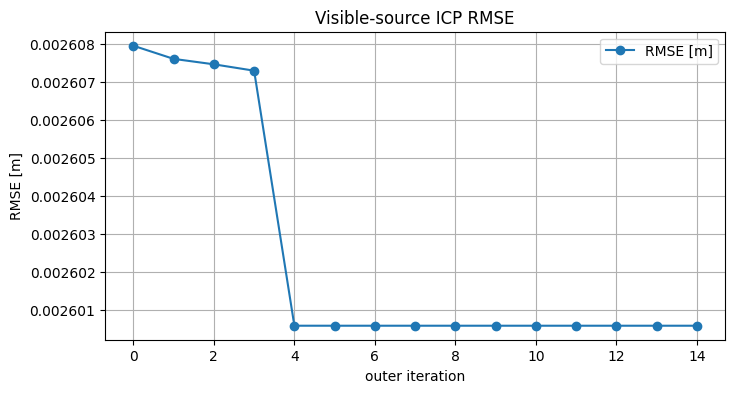

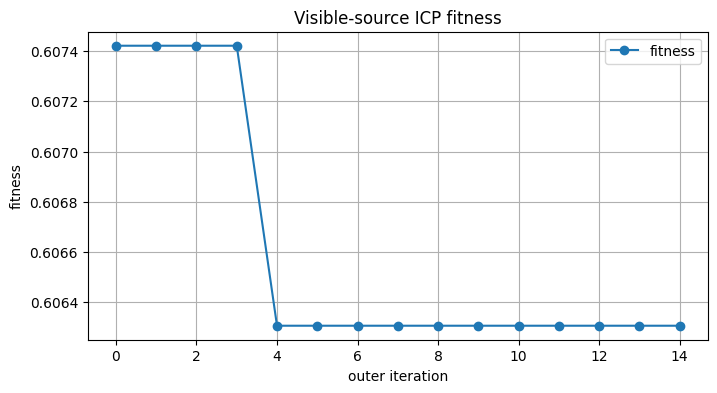

[SAVE] ransac init : C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\fpfh_ransac_init_result.ply
[SAVE] final CAD   : C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\fpfh_visible_icp_final_result.ply
[SAVE] visible CAD : C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\fpfh_visible_icp_visible_source_only.ply
[SAVE] target      : C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\duplo\fpfh_target_protruding_crop.ply


In [67]:
# ============================================================
# 셀 3 — Visible-source ICP refine + 최종 시각화
# ============================================================

import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 0. 사전 체크
# ------------------------------------------------------------
required_vars = [
    "cad_ds",
    "target_ds",
    "map_pcd_raw",
    "T_ransac",
    "transform_points",
    "cad_path",
]

for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"{v} 변수가 없습니다. 셀 1, 셀 2를 먼저 실행하세요.")


# ------------------------------------------------------------
# 1. 현재 pose 기준으로 CAD 중 z=0 평면 위에 보이는 점만 추출
# ------------------------------------------------------------
def make_visible_source_pcd(source_points, T, plane_z=0.0, z_margin=0.0005):
    """
    source_points: CAD 점군. 아직 변환 전 좌표.
    T: 현재 추정 pose.
    plane_z: 묻힌 평면 높이. 여기서는 z=0.
    z_margin: 평면보다 살짝 위에 있는 점만 사용하기 위한 여유값.

    return:
        visible_pcd: 현재 T로 변환한 뒤 z > plane_z + margin 인 점군
        full_pcd: 현재 T로 변환한 전체 CAD 점군
        visible_mask: visible 점 mask
    """
    src_tf = transform_points(source_points, T)

    visible_mask = src_tf[:, 2] > plane_z + z_margin
    visible_pts = src_tf[visible_mask]

    visible_pcd = o3d.geometry.PointCloud()
    visible_pcd.points = o3d.utility.Vector3dVector(visible_pts)

    full_pcd = o3d.geometry.PointCloud()
    full_pcd.points = o3d.utility.Vector3dVector(src_tf)

    return visible_pcd, full_pcd, visible_mask


# ------------------------------------------------------------
# 2. Visible-source ICP 반복
# ------------------------------------------------------------
def visible_source_icp_loop(
    source_points,
    target_pcd,
    T_init,
    plane_z=0.0,
    z_margin=0.0005,
    icp_threshold=0.005,
    outer_iterations=15,
    inner_iterations=30,
):
    """
    핵심:
    1) 현재 T로 CAD 전체를 변환
    2) z=0 평면 위에 있는 CAD 점만 source로 사용
    3) 그 visible CAD만 target에 ICP
    4) delta_T를 전체 T에 누적
    """
    T = T_init.copy()
    target = o3d.geometry.PointCloud(target_pcd)

    history = []

    for outer in range(outer_iterations):
        visible_src, full_src, visible_mask = make_visible_source_pcd(
            source_points,
            T,
            plane_z=plane_z,
            z_margin=z_margin
        )

        n_visible = len(visible_src.points)

        if n_visible < 30:
            print(f"[WARN] visible source point가 너무 적음: {n_visible}")
            break

        # visible_src는 이미 T가 적용된 좌표이므로 ICP 초기값은 identity
        result = o3d.pipelines.registration.registration_icp(
            visible_src,
            target,
            icp_threshold,
            np.eye(4),
            o3d.pipelines.registration.TransformationEstimationPointToPoint(),
            o3d.pipelines.registration.ICPConvergenceCriteria(
                max_iteration=inner_iterations
            )
        )

        delta_T = result.transformation

        # delta_T를 기존 T 앞에 누적
        T = delta_T @ T

        history.append({
            "outer": outer,
            "visible_points": n_visible,
            "fitness": result.fitness,
            "rmse": result.inlier_rmse,
        })

        print(
            f"[Visible ICP] outer={outer:02d} | "
            f"visible={n_visible} | "
            f"fitness={result.fitness:.4f} | "
            f"rmse={result.inlier_rmse:.6f}"
        )

        # 거의 변화 없으면 종료
        if result.inlier_rmse < 0.001:
            print("[Visible ICP] rmse 충분히 작아서 종료")
            break

    return T, history


# ------------------------------------------------------------
# 3. ICP 실행
# ------------------------------------------------------------
source_points = np.asarray(cad_ds.points)
target_pcd_for_icp = o3d.geometry.PointCloud(target_ds)

T_visible_icp, visible_icp_history = visible_source_icp_loop(
    source_points=source_points,
    target_pcd=target_pcd_for_icp,
    T_init=T_ransac,
    plane_z=0.0,
    z_margin=0.0005,
    icp_threshold=0.005,
    outer_iterations=15,
    inner_iterations=30,
)

print("\n[VISIBLE ICP RESULT]")
print(T_visible_icp)


# ------------------------------------------------------------
# 4. 결과 점군 생성
# ------------------------------------------------------------
# RANSAC 초기 결과
cad_ransac_pts = transform_points(source_points, T_ransac)
cad_ransac_pcd = o3d.geometry.PointCloud()
cad_ransac_pcd.points = o3d.utility.Vector3dVector(cad_ransac_pts)
cad_ransac_pcd.paint_uniform_color([1.0, 0.8, 0.0])  # 노랑

# Visible ICP 최종 전체 CAD
cad_final_pts = transform_points(source_points, T_visible_icp)
cad_final_pcd = o3d.geometry.PointCloud()
cad_final_pcd.points = o3d.utility.Vector3dVector(cad_final_pts)
cad_final_pcd.paint_uniform_color([0.0, 1.0, 0.0])  # 초록

# 최종 pose 기준 visible CAD만 따로 표시
cad_visible_only_pcd, _, _ = make_visible_source_pcd(
    source_points,
    T_visible_icp,
    plane_z=0.0,
    z_margin=0.0005
)
cad_visible_only_pcd.paint_uniform_color([0.0, 0.2, 1.0])  # 파랑

# target protruding point
target_vis = o3d.geometry.PointCloud(target_ds)
target_vis.paint_uniform_color([1.0, 0.0, 0.0])  # 빨강

# 전체 map plane
map_vis = o3d.geometry.PointCloud(map_pcd_raw)
map_vis.paint_uniform_color([0.65, 0.65, 0.65])  # 회색

axis = o3d.geometry.TriangleMesh.create_coordinate_frame(
    size=0.03,
    origin=[0, 0, 0]
)


# ------------------------------------------------------------
# 5. 시각화
# ------------------------------------------------------------
print("\n[VIEW]")
print("회색 = 전체 가짜맵")
print("빨강 = target 튀어나온 부분")
print("노랑 = FPFH RANSAC 초기 CAD")
print("초록 = Visible ICP 후 전체 CAD")
print("파랑 = ICP에 실제 사용된 visible CAD")

o3d.visualization.draw_geometries(
    [
        map_vis,
        target_vis,
        cad_ransac_pcd,
        cad_final_pcd,
        cad_visible_only_pcd,
        axis,
    ],
    window_name="Visible-source ICP result"
)


# ------------------------------------------------------------
# 6. RMSE 그래프
# ------------------------------------------------------------
if len(visible_icp_history) > 0:
    xs = [h["outer"] for h in visible_icp_history]
    rmses = [h["rmse"] for h in visible_icp_history]
    fitnesses = [h["fitness"] for h in visible_icp_history]

    plt.figure(figsize=(8, 4))
    plt.plot(xs, rmses, marker="o", label="RMSE [m]")
    plt.xlabel("outer iteration")
    plt.ylabel("RMSE [m]")
    plt.title("Visible-source ICP RMSE")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(xs, fitnesses, marker="o", label="fitness")
    plt.xlabel("outer iteration")
    plt.ylabel("fitness")
    plt.title("Visible-source ICP fitness")
    plt.grid(True)
    plt.legend()
    plt.show()


# ------------------------------------------------------------
# 7. 저장
# ------------------------------------------------------------
out_dir = cad_path.parent

out_ransac = out_dir / "fpfh_ransac_init_result.ply"
out_visible_icp = out_dir / "fpfh_visible_icp_final_result.ply"
out_visible_only = out_dir / "fpfh_visible_icp_visible_source_only.ply"
out_target = out_dir / "fpfh_target_protruding_crop.ply"

o3d.io.write_point_cloud(str(out_ransac), cad_ransac_pcd)
o3d.io.write_point_cloud(str(out_visible_icp), cad_final_pcd)
o3d.io.write_point_cloud(str(out_visible_only), cad_visible_only_pcd)
o3d.io.write_point_cloud(str(out_target), target_vis)

print("[SAVE] ransac init :", out_ransac.resolve())
print("[SAVE] final CAD   :", out_visible_icp.resolve())
print("[SAVE] visible CAD :", out_visible_only.resolve())
print("[SAVE] target      :", out_target.resolve())

In [68]:
# ------------------------------------------------------------
# 8. depth축 방향 추가 보정
# ------------------------------------------------------------

def make_visible_source_points(source_points, T, plane_z=0.0, z_margin=0.0005):
    src_tf = transform_points(source_points, T)
    visible_mask = src_tf[:, 2] > plane_z + z_margin
    visible_pts = src_tf[visible_mask]
    return visible_pts


# 최종 visible CAD
final_visible_pts = make_visible_source_points(
    source_points,
    T_visible_icp,
    plane_z=0.0,
    z_margin=0.0005
)

# target 점군
target_pts_final = np.asarray(target_ds.points)

# 중심
cad_vis_center = final_visible_pts.mean(axis=0)
target_center = target_pts_final.mean(axis=0)

print("[INFO] cad visible center :", cad_vis_center)
print("[INFO] target center      :", target_center)

# ------------------------------------------------------------
# depth축 정의
# 여기서는 "카메라가 내려다보는 방향" 또는
# 네 현재 좌표계에서 실제 depth 방향 축을 넣어야 함
#
# 우선 네 설명대로 '밑에 있는 방향'이 depth축이면,
# 지금 실험 좌표계에서는 예를 들어 Y축 또는 Z축일 수 있음.
# 아래는 예시로 Z축을 depth축이라고 가정.
# ------------------------------------------------------------
depth_axis = np.array([0.0, 0.0, 1.0], dtype=np.float64)
depth_axis /= np.linalg.norm(depth_axis)

center_diff = target_center - cad_vis_center

# 중심 차이 중 depth축 성분만 추출
depth_offset = np.dot(center_diff, depth_axis)

print("[INFO] center_diff :", center_diff)
print("[INFO] depth_offset:", depth_offset)

# translation correction
T_depth_corrected = T_visible_icp.copy()
T_depth_corrected[:3, 3] += depth_offset * depth_axis

print("[INFO] T_depth_corrected:\n", T_depth_corrected)

[INFO] cad visible center : [0.03004952 0.02415742 0.04358634]
[INFO] target center      : [0.03006344 0.02513685 0.0478698 ]
[INFO] center_diff : [1.39199894e-05 9.79430235e-04 4.28346564e-03]
[INFO] depth_offset: 0.004283465644860221
[INFO] T_depth_corrected:
 [[ 0.99999684 -0.00181818 -0.00173436  0.02996463]
 [ 0.00179808  0.99993201 -0.01152148  0.02404365]
 [ 0.00175519  0.01151832  0.99993212  0.04817225]
 [ 0.          0.          0.          1.        ]]


In [69]:
from scipy.spatial import cKDTree

final_visible_pts = make_visible_source_points(
    source_points,
    T_visible_icp,
    plane_z=0.0,
    z_margin=0.0005
)

target_pts_final = np.asarray(target_ds.points)

tree_vis = cKDTree(final_visible_pts)
dists, idxs = tree_vis.query(target_pts_final, k=1)

matched_vis_pts = final_visible_pts[idxs]
diff_vecs = target_pts_final - matched_vis_pts

mean_diff = diff_vecs.mean(axis=0)

depth_axis = np.array([0.0, 0.0, 1.0], dtype=np.float64)
depth_axis /= np.linalg.norm(depth_axis)

depth_offset = np.dot(mean_diff, depth_axis)

print("[INFO] mean_diff   :", mean_diff)
print("[INFO] depth_offset:", depth_offset)

T_depth_corrected = T_visible_icp.copy()
T_depth_corrected[:3, 3] += depth_offset * depth_axis

[INFO] mean_diff   : [ 2.07893010e-05 -2.16496160e-04 -5.70000764e-04]
[INFO] depth_offset: -0.000570000764368794


In [70]:
cad_corrected_pts = transform_points(source_points, T_depth_corrected)

cad_corrected_pcd = o3d.geometry.PointCloud()
cad_corrected_pcd.points = o3d.utility.Vector3dVector(cad_corrected_pts)
cad_corrected_pcd.paint_uniform_color([0.0, 1.0, 1.0])  # 하늘색

target_vis = o3d.geometry.PointCloud(target_ds)
target_vis.paint_uniform_color([1.0, 0.0, 0.0])  # 빨강

map_vis = o3d.geometry.PointCloud(map_pcd_raw)
map_vis.paint_uniform_color([0.65, 0.65, 0.65])

axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.03)

o3d.visualization.draw_geometries(
    [map_vis, target_vis, cad_corrected_pcd, axis],
    window_name="Depth-axis corrected result"
)

In [71]:
# ============================================================
# T_depth_corrected 기준 visible CAD만 target과 비교
# ============================================================

def make_visible_source_points(source_points, T, plane_z=0.0, z_margin=0.0005):
    src_tf = transform_points(source_points, T)
    visible_mask = src_tf[:, 2] > plane_z + z_margin
    visible_pts = src_tf[visible_mask]
    return visible_pts, src_tf, visible_mask


visible_corrected_pts, full_corrected_pts, visible_mask = make_visible_source_points(
    source_points,
    T_depth_corrected,
    plane_z=0.0,
    z_margin=0.0005
)

visible_corrected_pcd = o3d.geometry.PointCloud()
visible_corrected_pcd.points = o3d.utility.Vector3dVector(visible_corrected_pts)
visible_corrected_pcd.paint_uniform_color([0.0, 1.0, 1.0])  # 하늘색

target_vis = o3d.geometry.PointCloud(target_ds)
target_vis.paint_uniform_color([1.0, 0.0, 0.0])  # 빨강

map_vis = o3d.geometry.PointCloud(map_pcd_raw)
map_vis.paint_uniform_color([0.65, 0.65, 0.65])

axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.03)

print("[INFO] corrected visible points:", len(visible_corrected_pts))
print("[INFO] target points:", len(target_ds.points))

o3d.visualization.draw_geometries(
    [map_vis, target_vis, visible_corrected_pcd, axis],
    window_name="Corrected visible CAD vs target"
)

[INFO] corrected visible points: 3584
[INFO] target points: 596


In [72]:
from scipy.spatial import cKDTree
import numpy as np
import open3d as o3d

# ============================================================
# NN 기반 robust depth-axis 보정
# ============================================================

def robust_depth_axis_correction(
    source_points,
    target_points,
    T,
    depth_axis=np.array([0.0, 0.0, 1.0]),
    plane_z=0.0,
    z_margin=0.0005,
    max_pair_dist=0.015,
    trim_percentile=80,
):
    depth_axis = depth_axis.astype(np.float64)
    depth_axis /= np.linalg.norm(depth_axis) + 1e-12

    visible_pts, full_pts, visible_mask = make_visible_source_points(
        source_points,
        T,
        plane_z=plane_z,
        z_margin=z_margin
    )

    if len(visible_pts) < 30:
        raise RuntimeError("visible CAD point가 너무 적습니다.")

    tree = cKDTree(visible_pts)
    dists, idxs = tree.query(target_points, k=1)

    # 너무 먼 매칭 제거
    valid = dists < max_pair_dist

    if np.count_nonzero(valid) < 30:
        print("[WARN] valid NN pair가 적습니다. max_pair_dist를 늘려보세요.")
        valid = np.ones_like(dists, dtype=bool)

    matched_visible = visible_pts[idxs[valid]]
    matched_target = target_points[valid]

    diff = matched_target - matched_visible

    # depth축 성분만 추출
    offsets = diff @ depth_axis

    # outlier 제거: 중앙 근처 값만 사용
    abs_offsets = np.abs(offsets - np.median(offsets))
    cutoff = np.percentile(abs_offsets, trim_percentile)
    keep = abs_offsets <= cutoff

    robust_offset = float(np.median(offsets[keep]))

    T_corr = T.copy()
    T_corr[:3, 3] += robust_offset * depth_axis

    info = {
        "visible_count": len(visible_pts),
        "valid_pairs": int(np.count_nonzero(valid)),
        "used_pairs": int(np.count_nonzero(keep)),
        "offset_median": float(np.median(offsets)),
        "offset_mean": float(np.mean(offsets)),
        "robust_offset": robust_offset,
    }

    return T_corr, info


target_points = np.asarray(target_ds.points)

T_depth_corrected_robust, zcorr_info = robust_depth_axis_correction(
    source_points=source_points,
    target_points=target_points,
    T=T_visible_icp,
    depth_axis=np.array([0.0, 0.0, 1.0]),  # 현재 가짜맵은 z축 기준 top-down이므로 z축
    plane_z=0.0,
    z_margin=0.0005,
    max_pair_dist=0.015,
    trim_percentile=80,
)

print("[ROBUST Z CORRECTION]")
for k, v in zcorr_info.items():
    print(k, ":", v)

print("[T_depth_corrected_robust]")
print(T_depth_corrected_robust)

[ROBUST Z CORRECTION]
visible_count : 3584
valid_pairs : 596
used_pairs : 477
offset_median : -0.00019528330785060607
offset_mean : -0.0005700007643682241
robust_offset : -0.0001034081770208285
[T_depth_corrected_robust]
[[ 0.99999684 -0.00181818 -0.00173436  0.02996463]
 [ 0.00179808  0.99993201 -0.01152148  0.02404365]
 [ 0.00175519  0.01151832  0.99993212  0.04378537]
 [ 0.          0.          0.          1.        ]]


In [75]:
visible_robust_pts, full_robust_pts, _ = make_visible_source_points(
    source_points,
    T_depth_corrected_robust,
    plane_z=0.0,
    z_margin=0.0005
)

visible_robust_pcd = o3d.geometry.PointCloud()
visible_robust_pcd.points = o3d.utility.Vector3dVector(visible_robust_pts)
visible_robust_pcd.paint_uniform_color([0.0, 1.0, 1.0])  # 하늘색

target_vis = o3d.geometry.PointCloud(target_ds)
target_vis.paint_uniform_color([1.0, 0.0, 0.0])  # 빨강

map_vis = o3d.geometry.PointCloud(map_pcd_raw)
map_vis.paint_uniform_color([0.65, 0.65, 0.65])

axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.03)

o3d.visualization.draw_geometries(
    [map_vis, target_vis, visible_robust_pcd, axis],
    window_name="Robust depth corrected visible CAD vs target"
)

In [76]:
from scipy.spatial import cKDTree
import numpy as np

def visible_points_from_T(source_points, T, plane_z=0.0, z_margin=0.0005):
    pts_tf = transform_points(source_points, T)
    return pts_tf[pts_tf[:, 2] > plane_z + z_margin]

def chamfer_bidirectional(a, b):
    tree_b = cKDTree(b)
    tree_a = cKDTree(a)

    da, _ = tree_b.query(a, k=1)
    db, _ = tree_a.query(b, k=1)

    return {
        "a_to_b_mean": float(np.mean(da)),
        "b_to_a_mean": float(np.mean(db)),
        "chamfer": float(np.mean(da) + np.mean(db)),
        "a_to_b_median": float(np.median(da)),
        "b_to_a_median": float(np.median(db)),
    }

target_pts = np.asarray(target_ds.points)

vis_before = visible_points_from_T(source_points, T_visible_icp)
vis_center_corr = visible_points_from_T(source_points, T_depth_corrected)
vis_robust_corr = visible_points_from_T(source_points, T_depth_corrected_robust)

print("[Before visible ICP correction]")
print(chamfer_bidirectional(vis_before, target_pts))

print("\n[Center Z corrected]")
print(chamfer_bidirectional(vis_center_corr, target_pts))

print("\n[Robust Z corrected]")
print(chamfer_bidirectional(vis_robust_corr, target_pts))

[Before visible ICP correction]
{'a_to_b_mean': 0.005348609510016866, 'b_to_a_mean': 0.0011573024983801805, 'chamfer': 0.006505912008397047, 'a_to_b_median': 0.0035275520077081993, 'b_to_a_median': 0.0009075504385719452}

[Center Z corrected]
{'a_to_b_mean': 0.005552328299139012, 'b_to_a_mean': 0.001059211232887321, 'chamfer': 0.006611539532026332, 'a_to_b_median': 0.00347346076073244, 'b_to_a_median': 0.0009049432521374033}

[Robust Z corrected]
{'a_to_b_mean': 0.005383773660589636, 'b_to_a_mean': 0.001125623308591993, 'chamfer': 0.006509396969181629, 'a_to_b_median': 0.0034637659427984007, 'b_to_a_median': 0.0008821149540462562}


In [77]:
visible_robust_pts, full_robust_pts, _ = make_visible_source_points(
    source_points,
    T_depth_corrected_robust,
    plane_z=0.0,
    z_margin=0.0005
)

visible_robust_pcd = o3d.geometry.PointCloud()
visible_robust_pcd.points = o3d.utility.Vector3dVector(visible_robust_pts)
visible_robust_pcd.paint_uniform_color([0.6, 0.6, 0.6])  # CAD를 회색

target_vis = o3d.geometry.PointCloud(target_ds)
target_vis.paint_uniform_color([1.0, 0.0, 0.0])  # target 빨강

axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.03)

o3d.visualization.draw_geometries(
    [visible_robust_pcd, target_vis, axis],
    window_name="Gray visible CAD vs Red target"
)

In [78]:
T_final_refine, final_history = visible_source_icp_loop(
    source_points=source_points,
    target_pcd=o3d.geometry.PointCloud(target_ds),
    T_init=T_depth_corrected_robust,
    plane_z=0.0,
    z_margin=0.0005,
    icp_threshold=0.003,
    outer_iterations=5,
    inner_iterations=20,
)

print("[T_final_refine]")
print(T_final_refine)

[Visible ICP] outer=00 | visible=3584 | fitness=0.4277 | rmse=0.001478
[Visible ICP] outer=01 | visible=3584 | fitness=0.4277 | rmse=0.001478
[Visible ICP] outer=02 | visible=3584 | fitness=0.4277 | rmse=0.001478
[Visible ICP] outer=03 | visible=3584 | fitness=0.4277 | rmse=0.001478
[Visible ICP] outer=04 | visible=3584 | fitness=0.4277 | rmse=0.001478
[T_final_refine]
[[ 9.99999672e-01  6.57991186e-04 -4.71319168e-04  3.00038521e-02]
 [-6.58211616e-04  9.99999674e-01 -4.67685122e-04  2.39012873e-02]
 [ 4.71011282e-04  4.67995197e-04  9.99999780e-01  4.16418826e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [80]:
def make_topdown_visible_source_points(
    source_points,
    T,
    plane_z=0.0,
    z_margin=0.0005,
    pixel_size=0.001,
):
    """
    현재 pose T에서 CAD를 변환한 뒤,
    z=0 평면 위에 있는 점 중
    top-down 기준 각 XY grid cell에서 z가 가장 큰 점만 남김.
    """
    src_tf = transform_points(source_points, T)

    # 평면 위에 있는 점만 후보
    above_mask = src_tf[:, 2] > plane_z + z_margin
    pts = src_tf[above_mask]

    if len(pts) == 0:
        return pts, src_tf, above_mask

    # XY grid
    ij = np.floor(pts[:, :2] / pixel_size).astype(np.int64)

    best = {}
    for idx, key in enumerate(map(tuple, ij)):
        z = pts[idx, 2]
        if key not in best:
            best[key] = idx
        else:
            old_idx = best[key]
            if z > pts[old_idx, 2]:
                best[key] = idx

    selected_local_idx = np.array(list(best.values()), dtype=np.int64)
    visible_pts = pts[selected_local_idx]

    return visible_pts, src_tf, above_mask


def visible_points_from_T_topdown(source_points, T, plane_z=0.0, z_margin=0.0005):
    visible_pts, _, _ = make_topdown_visible_source_points(
        source_points,
        T,
        plane_z=plane_z,
        z_margin=z_margin,
        pixel_size=0.001,
    )
    return visible_pts

In [81]:
target_pts = np.asarray(target_ds.points)

vis_before = visible_points_from_T_topdown(source_points, T_visible_icp)
vis_robust_corr = visible_points_from_T_topdown(source_points, T_depth_corrected_robust)
vis_final = visible_points_from_T_topdown(source_points, T_final_refine)

print("[Before topdown visible]")
print(chamfer_bidirectional(vis_before, target_pts))

print("\n[Robust Z corrected topdown visible]")
print(chamfer_bidirectional(vis_robust_corr, target_pts))

print("\n[Final refine topdown visible]")
print(chamfer_bidirectional(vis_final, target_pts))

[Before topdown visible]
{'a_to_b_mean': 0.003151806790741702, 'b_to_a_mean': 0.002361199167873881, 'chamfer': 0.005513005958615583, 'a_to_b_median': 0.0031494954705455595, 'b_to_a_median': 0.002311577352498962}

[Robust Z corrected topdown visible]
{'a_to_b_mean': 0.003116458582438091, 'b_to_a_mean': 0.0023203555777844822, 'chamfer': 0.005436814160222573, 'a_to_b_median': 0.0030819233706388264, 'b_to_a_median': 0.0022779091692998643}

[Final refine topdown visible]
{'a_to_b_mean': 0.0019570659116557513, 'b_to_a_mean': 0.0014661371873498786, 'chamfer': 0.0034232030990056297, 'a_to_b_median': 0.0016622476985925045, 'b_to_a_median': 0.00158208816782895}


In [82]:
vis_pts = visible_points_from_T_topdown(source_points, T_final_refine)

vis_pcd = o3d.geometry.PointCloud()
vis_pcd.points = o3d.utility.Vector3dVector(vis_pts)
vis_pcd.paint_uniform_color([0.6, 0.6, 0.6])

target_vis = o3d.geometry.PointCloud(target_ds)
target_vis.paint_uniform_color([1.0, 0.0, 0.0])

axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.03)

o3d.visualization.draw_geometries(
    [vis_pcd, target_vis, axis],
    window_name="Topdown visible CAD vs red target"
)

## ICP전에 coarse 튜닝이 필요합니다

## 카메라 설정

카메라 탐색

In [84]:
import pyrealsense2 as rs

def get_realsense_ids():
    """
    연결된 모든 리얼센스 카메라의 이름과 시리얼 번호(ID)를 딕셔너리 형태로 반환합니다.
    """
    connected_devices = {}
    
    # 리얼센스 컨텍스트 생성 (연결된 기기들을 관리)
    ctx = rs.context()
    
    # 연결된 기기가 없는 경우 예외 처리
    if len(ctx.devices) == 0:
        print("연결된 리얼센스 카메라를 찾을 수 없습니다.")
        return connected_devices

    # 연결된 모든 기기를 순회하며 정보 추출
    for dev in ctx.devices:
        name = dev.get_info(rs.camera_info.name)
        serial_number = dev.get_info(rs.camera_info.serial_number)
        
        # 시리얼 번호를 키(Key)로, 모델명을 값(Value)으로 저장
        connected_devices[serial_number] = name
        
    return connected_devices


In [110]:
print("리얼센스 기기 검색 중...\n" + "-"*30)

devices = get_realsense_ids()

if devices:
    print(f"총 {len(devices)}대의 카메라가 연결되어 있습니다.\n")
    for serial, name in devices.items():
        print(f"📷 모델명: {name}")
        print(f"🔑 기기 ID (Serial): {serial}\n")
else:
    print("카메라 연결 상태(USB 포트 등)를 확인해주세요.")

리얼센스 기기 검색 중...
------------------------------
총 1대의 카메라가 연결되어 있습니다.

📷 모델명: Intel RealSense D435IF
🔑 기기 ID (Serial): 327122072783



### 카메라 설정 예시

In [ ]:
# # import pyrealsense2 as rs

# # 파이프라인 및 설정 준비
# pipeline = rs.pipeline()
# config = rs.config()
# config.enable_stream(rs.stream.depth, 640, 480, rs.format.z16, 30)

# # 파이프라인 시작 (카메라 켜기)
# profile = pipeline.start(config)

# # 1. 뎁스 센서 객체 가져오기 (컨트롤을 위함)
# depth_sensor = profile.get_device().first_depth_sensor()

# # 2. Visual Preset 옵션 지원 여부 확인
# if depth_sensor.supports(rs.option.visual_preset):
    
#     # ------------------------------------------------
#     # 💡 여기서 원하는 모드의 번호를 입력해 확확 바꿀 수 있습니다.
#     # 3: High Accuracy (고정밀 - 노이즈가 적고 정확한 뎁스)
#     # 4: High Density (고밀도 - 뎁스 구멍을 빽빽하게 채움)
#     # 5: Medium Density (중밀도 - 정확도와 밀도의 밸런스)
#     # ------------------------------------------------
#     target_preset = 4
    
#     # 모드 세팅!
#     depth_sensor.set_option(rs.option.visual_preset, target_preset)
    
#     # 세팅된 프리셋의 실제 이름(문자열)을 읽어와서 출력 확인
#     preset_name = depth_sensor.get_option_value_description(rs.option.visual_preset, target_preset)
#     print(f"✅ 카메라 모드가 [{preset_name}] 모드로 성공적으로 변경되었습니다!")

# else:
#     print("이 카메라는 Visual Preset 옵션을 지원하지 않습니다.")

# # 스트리밍 종료
# pipeline.stop()

✅ 카메라 모드가 [High Density] 모드로 성공적으로 변경되었습니다!


## 카메라 설정 함수 요약
아래 함수를 기준으로 설정하고, 얼라인드 뎁스를 가져올수 있음

In [59]:
import pyrealsense2 as rs
import numpy as np
import cv2
# ==========================================
# 🎯 카메라 상황별 맞춤 설정 (Profiles)
# ==========================================
CAMERA_PROFILES = {
    # 1. 바닥(Floor) 모드: RANSAC 평면 검출용 (넓고 강하게)
    "floor": {
        "preset_id": 4,              # High Density (바닥 구멍 채우기)
        "smooth_alpha": 0.5,
        "smooth_delta": 20,          # 평면을 더 평평하게 다듬기 위해 낮춤
        "min_dist": 0.30,            # 카메라 바로 앞 먼지/노이즈 무시
        "max_dist": 2.00,            # 바닥까지만 보고 불필요한 원거리 컷
        "target_laser_power": 360,   # 바닥 반사율 확보를 위해 최대 파워
        "target_shift": 0,           # 정상 시력 구간
        "roi_percent": 80,           # 화면 전체를 기준으로 노출 계산
        "auto_awb_value": 1,
        "depth_Units": 0.0001
    },
    
    # 2. 근접 30cm 모드: 듀플로 픽킹용 (정밀하고 어둡게)
    "macro_30": {
        "preset_id": 4,              # High Density (바닥 구멍 채우기)
        "smooth_alpha": 0.1,         # 정지 상태에서 장노출 효과 (잔상 누적)
        "smooth_delta": 50,         # 노이즈를 찰흙처럼 강하게 뭉갬
        "min_dist": 0.10,
        "max_dist": 0.30,            # 딱 40cm 뒤로는 전부 까맣게 날려버림 (크로마키 효과)
        "target_laser_power": 150,   # 유광 듀플로 눈부심(백화) 방지를 위해 파워 낮춤
        "target_shift": 60,          # 측정 영점을 30cm 코앞으로 확 당김
        "roi_percent": 20,           # 주변 무시하고 정중앙 듀플로에만 노출 집중
        "auto_awb_value": 1,
        "depth_Units": 0.0001
    },
    
    # 3. 원거리 50cm 모드: 접근 및 탐색용 (밸런스형)
    "mid_50": {
        "preset_id": 4,              # High Density
        "smooth_alpha": 0.5,
        "smooth_delta": 50,
        "min_dist": 0.20,
        "max_dist": 0.80,            # 작업대(테이블) 영역 정도까지만 컷
        "target_laser_power": 250,   # 너무 세지도 약하지도 않은 중간 파워
        "target_shift": 0,           # 50cm는 기본 시력 구간에 포함됨 (Shift 불필요)
        "roi_percent": 40,           # 작업 영역인 중앙 40% 기준 노출
        "auto_awb_value": 1,
        "depth_Units": 0.0001        
    }
}

def configure_realsense(
        preset_id=4, 
        smooth_alpha=0.5, 
        smooth_delta=50, 
        min_dist=0.15, 
        max_dist=2.0, 
        target_laser_power = 150, 
        target_shift = 0, 
        roi_percent=80, 
        auto_awb_value=1,
        depth_Units=0.0001
        ):
    
    pipeline = rs.pipeline()
    config = rs.config()

    # 1. 스트림 해상도 설정
    config.enable_stream(rs.stream.depth, 848, 480, rs.format.z16, 30)
    config.enable_stream(rs.stream.color, 640, 480, rs.format.rgb8, 30)

    # 파이프라인 시작
    profile = pipeline.start(config)
    dev = profile.get_device()
    advnc_mode = rs.rs400_advanced_mode(dev)
    
    # 2. 센서 객체 가져오기
    depth_sensor = dev.first_depth_sensor()
    
    # 💡 추가해야 할 부분!
    color_sensor = dev.first_color_sensor()
    
    # 3. 비주얼 프리셋 설정
    if depth_sensor.supports(rs.option.visual_preset):
        depth_sensor.set_option(rs.option.visual_preset, preset_id)
        print(f"✅ Preset 설정 완료: {depth_sensor.get_option_value_description(rs.option.visual_preset, preset_id)}")

    # 4. 뎁스 유닛(Depth Unit) 설정
    if depth_sensor.supports(rs.option.depth_units):
        try:
            depth_sensor.set_option(rs.option.depth_units, depth_Units)
            print(f"✅ Depth Unit 설정 완료: {depth_sensor.get_option(rs.option.depth_units)}")
        except Exception as e:
            print(f"⚠️ Depth Unit 설정 실패: {e}")

    # 5. 자동 노출(Auto Exposure) 활성화 및 ROI 설정
    if depth_sensor.supports(rs.option.enable_auto_exposure):
        depth_sensor.set_option(rs.option.enable_auto_exposure, 1)
        print("✅ 뎁스 센서 자동 노출(AE) 스위치 ON")

    roi_sensor = rs.roi_sensor(depth_sensor)
    if roi_sensor:
        # 비율을 기반으로 여백(margin) 계산 (예: 80% -> 남은 20%를 반으로 나눠 0.1의 여백 생성)
        # 20: 초근접 중앙 객체
        # 40: 일반적인 중앙 영역
        # 80: 넓은 중앙 영역
        margin = (100 - roi_percent) / 2.0 / 100.0        
        roi = rs.region_of_interest()
        # 해상도 848x480 기준 중앙 영역 동적 계산
        roi.min_x = int(848 * margin)
        roi.max_x = int(848 * (1.0 - margin))
        roi.min_y = int(480 * margin)
        roi.max_y = int(480 * (1.0 - margin))
        
        # 기기에 ROI 세팅 적용
        roi_sensor.set_region_of_interest(roi)
        print(f"✅ Depth ROI 영역 설정 완료 (중앙 {roi_percent}% / X: {roi.min_x}~{roi.max_x}, Y: {roi.min_y}~{roi.max_y})")

    # 레이저 파워 설정
    # 추천값 -> 60cm 이상 바닥: 360 (최대치) / 30cm 코앞: 약 150
    if depth_sensor.supports(rs.option.laser_power):
        depth_sensor.set_option(rs.option.laser_power, target_laser_power)
        print(f"✅ 레이저 파워 설정 완료: {target_laser_power}")

    # 🎯 디스패리티 시프트 설정 (고급 모드 사용)
    # 추천값 -> 60cm 이상 바닥: 0 (기본값) / 30cm 코앞: 50 ~ 100 사이 조절
    if advnc_mode.is_enabled():
        depth_table = advnc_mode.get_depth_table()
        depth_table.disparityShift = target_shift
        advnc_mode.set_depth_table(depth_table)
        print(f"✅ Disparity Shift 설정 완료: {target_shift}")

    # 6. Temporal Filter 설정
    temp_filter = rs.temporal_filter()
    # alpha 값을 낮출수록(예: 0.1~0.2) 이전 프레임의 데이터를 더 오래, 무겁게 기억합니다.
    temp_filter.set_option(rs.option.filter_smooth_alpha, smooth_alpha)
    # delta 값을 높일수록 노이즈를 깎지 않고 찰흙처럼 뭉개버립니다.
    temp_filter.set_option(rs.option.filter_smooth_delta, smooth_delta)
    # # hole filling 옵션: 누적된 데이터로 구멍을 강제로 메웁니다 (0~8)
    # temp_filter.set_option(rs.option.holes_fill, 3)
    print(f"✅ Temporal Filter 설정 완료")

    # ==========================================
    # 💡 7. Threshold Filter (거리 제한) 설정
    # ==========================================
    thres_filter = rs.threshold_filter()
    thres_filter.set_option(rs.option.min_distance, min_dist)
    thres_filter.set_option(rs.option.max_distance, max_dist)
    print(f"✅ Threshold Filter 설정 완료 (최소: {min_dist}m, 최대: {max_dist}m)")


    # 🎯 컬러 센서 자동 화이트 밸런스(AWB) 설정
    if color_sensor.supports(rs.option.enable_auto_white_balance):
        color_sensor.set_option(rs.option.enable_auto_white_balance, auto_awb_value)
        print(f"✅ 컬러 센서 자동 화이트 밸런스(AWB) {'ON' if auto_awb_value == 1 else 'OFF'}")

    # # (선택) 수동으로 색온도를 고정하고 싶을 때의 예시
    # if color_sensor.supports(rs.option.enable_auto_white_balance):
    #     color_sensor.set_option(rs.option.enable_auto_white_balance, 0) # 자동 끄기        
    #     color_sensor.set_option(rs.option.white_balance, 4600)
    #     print("✅ 컬러 센서 화이트 밸런스 수동 고정 (4600K)")

    # 8. 컬러 화면 기준 정렬(Align) 객체 생성
    align_to = rs.stream.color
    align = rs.align(align_to)

    # 리턴 값에 thres_filter 추가!
    return pipeline, align, temp_filter, thres_filter

def get_aligned_frames(pipeline, align, temp_filter, thres_filter, apply_filter=True):
    """
    카메라로부터 프레임을 받아 컬러 영상에 정렬된(Aligned) 뎁스 영상을 반환합니다.
    """
    frames = pipeline.wait_for_frames()
    aligned_frames = align.process(frames)
    
    aligned_depth_frame = aligned_frames.get_depth_frame()
    color_frame = aligned_frames.get_color_frame()
    
    if not aligned_depth_frame or not color_frame:
        return None, None

    # 요청에 따라 포스트 프로세싱 필터 적용
    if apply_filter:
        # 💡 보통 필요 없는 배경/가까운 물체를 먼저 날리고(Threshold) -> 잔상을 부드럽게(Temporal) 처리합니다.
        aligned_depth_frame = thres_filter.process(aligned_depth_frame)
        aligned_depth_frame = temp_filter.process(aligned_depth_frame)

    depth_image = np.asanyarray(aligned_depth_frame.get_data())
    color_image = np.asanyarray(color_frame.get_data())
    
    return depth_image, color_image

def get_aligned_intrinsics(pipeline):
    """
    현재 활성화된 파이프라인에서 정렬된(Aligned) 영상의 인트린직 정보를 반환합니다.
    (뎁스가 컬러에 정렬되므로, 컬러 센서의 인트린직을 반환합니다.)
    """
    # 1. 파이프라인에서 현재 실행 중인 프로필(Profile) 가져오기
    active_profile = pipeline.get_active_profile()
    
    # 2. 컬러 스트림(rs.stream.color) 정보 가져오기
    color_stream = active_profile.get_stream(rs.stream.color)
    
    # 3. 비디오 스트림 프로필로 캐스팅한 뒤 인트린직(Intrinsics) 추출
    intrinsics = color_stream.as_video_stream_profile().get_intrinsics()
    
    return intrinsics

def intrinsics_checker(pipeline):

    intrinsics = get_aligned_intrinsics(pipeline)
    # 인트린직 내부 값 확인하기

    print("\n[카메라 인트린직 정보]")
    print(f"해상도 (Width x Height): {intrinsics.width} x {intrinsics.height}")
    print(f"초점 거리 (fx, fy): {intrinsics.fx:.2f}, {intrinsics.fy:.2f}")
    print(f"주점/중심점 (ppx, ppy): {intrinsics.ppx:.2f}, {intrinsics.ppy:.2f}")
    print(f"왜곡 모델 (Distortion Model): {intrinsics.model}")
    print(f"왜곡 계수 (Coeffs): {intrinsics.coeffs}\n")

    return 0

설정 변화 확인 예시 = 거리제한이 달라 집니다.

In [61]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# 주피터 내 출력을 위한 matplotlib 피규어 준비
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

current_mode = "macro_30" # "floor", "macro_30", "mid_50" 중 택 1

print(f"[{current_mode}] 모드로 카메라를 켭니다...")

pipeline, align, temp_filter, thres_filter = configure_realsense(**CAMERA_PROFILES[current_mode])

# # 카메라 초기화
# pipeline, align, temp_filter, thres_filter = configure_realsense(
#     preset_id=4, 
#     smooth_alpha=0.5, 
#     smooth_delta=50, 
#     min_dist=0.00, 
#     max_dist=0.37, 
#     target_laser_power=150, 
#     target_shift=0, 
#     roi_percent=80, 
#     auto_awb_value=1
# )

intrinsics = get_aligned_intrinsics(pipeline)
intrinsics_checker(pipeline)


print("스트리밍을 시작합니다...")

try:
    # ==========================================
    # 카메라 예열 (Warm-up): 초기 30프레임 날리기
    # ==========================================
    print("🔥 카메라 센서 안정화 및 예열 중 (초기 30프레임 버림)...")
    for _ in range(30):
        # wait_for_frames()만 호출하고, 변수에 담거나 처리하지 않고 그냥 허공에 날립니다.
        pipeline.wait_for_frames()
    print("✅ 예열 완료! 본격적인 스트리밍을 시작합니다.\n")



    # 💡 무한루프(while True) 대신 적정 프레임만 돌리거나, 키보드 인터럽트로 빠져나옵니다.
    for i in range(50):  # 테스트용으로 100프레임만 출력 (필요시 늘려주세요)
        
        # 2. 정렬된 프레임 받아오기 (apply_filter를 True/False로 바꿔가며 테스트)
        depth_img, color_img = get_aligned_frames(pipeline, align, temp_filter, thres_filter)
        
        if depth_img is None or color_img is None:
            continue
            
        # 3. 뎁스 영상 컬러맵 적용 (cv2는 BGR로 변환하므로 다시 RGB로 돌려줌)
        depth_colormap = cv2.applyColorMap(cv2.convertScaleAbs(depth_img, alpha=0.03), cv2.COLORMAP_JET)
        depth_colormap_rgb = cv2.cvtColor(depth_colormap, cv2.COLOR_BGR2RGB)
        
        # 4. 컬러 영상과 뎁스 영상을 가로로 이어붙이기
        images = np.hstack((color_img, depth_colormap_rgb))
        
        # 5. 주피터 노트북에 실시간으로 그리기
        ax.clear()
        ax.imshow(images)
        ax.axis('off')
        
        display(fig)
        clear_output(wait=True) # 이전 프레임을 지우고 덮어씌움 (부드러운 영상 재생 효과)



except KeyboardInterrupt:
    print("사용자에 의해 스트리밍이 강제 중지되었습니다.")
    
finally:
    # 6. 자원 해제 (매우 중요)
    pipeline.stop()
    plt.close()
    print("스트리밍이 안전하게 종료되었습니다.")



스트리밍이 안전하게 종료되었습니다.


[macro_30] 모드로 카메라를 켭니다...
✅ Preset 설정 완료: High Density
✅ Depth Unit 설정 완료: 9.999999747378752e-05
✅ 뎁스 센서 자동 노출(AE) 스위치 ON
✅ Depth ROI 영역 설정 완료 (중앙 20% / X: 339~508, Y: 192~288)
✅ 레이저 파워 설정 완료: 150
✅ Disparity Shift 설정 완료: 60
✅ Temporal Filter 설정 완료
✅ Threshold Filter 설정 완료 (최소: 0.1m, 최대: 0.3m)
✅ 컬러 센서 자동 화이트 밸런스(AWB) ON

[카메라 인트린직 정보]
해상도 (Width x Height): 640 x 480
초점 거리 (fx, fy): 606.19, 606.09
주점/중심점 (ppx, ppy): 329.10, 247.07
왜곡 모델 (Distortion Model): distortion.inverse_brown_conrady
왜곡 계수 (Coeffs): [0.0, 0.0, 0.0, 0.0, 0.0]

[INFO] depth_scale: 9.999999747378752e-05
스트리밍을 시작합니다...
🔥 카메라 센서 안정화 및 예열 중 (초기 30프레임 버림)...
✅ 예열 완료! 본격적인 스트리밍을 시작합니다.



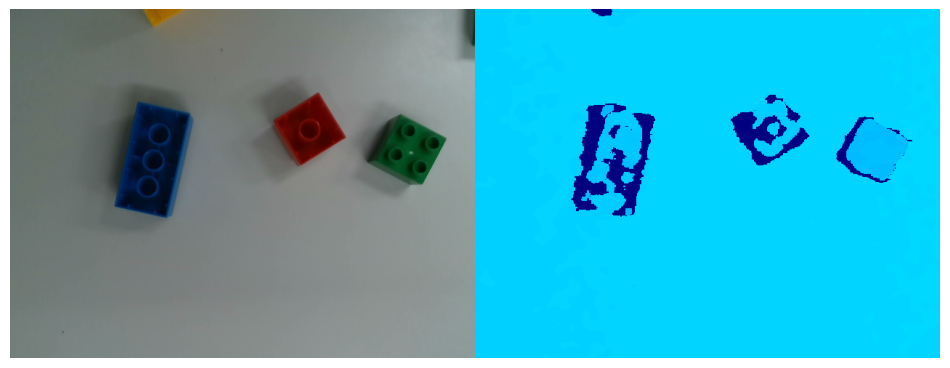

스트리밍이 안전하게 종료되었습니다.


In [62]:
# depth_img, color_img

import matplotlib.pyplot as plt

# 주피터 내 출력을 위한 matplotlib 피규어 준비
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

current_mode = "macro_30" # "floor", "macro_30", "mid_50" 중 택 1

print(f"[{current_mode}] 모드로 카메라를 켭니다...")

pipeline, align, temp_filter, thres_filter = configure_realsense(**CAMERA_PROFILES[current_mode])


intrinsics = get_aligned_intrinsics(pipeline)
intrinsics_checker(pipeline)

depth_scale = pipeline.get_active_profile().get_device().first_depth_sensor().get_depth_scale()
print("[INFO] depth_scale:", depth_scale)

print("스트리밍을 시작합니다...")

print("🔥 카메라 센서 안정화 및 예열 중 (초기 30프레임 버림)...")
for _ in range(30):
    # wait_for_frames()만 호출하고, 변수에 담거나 처리하지 않고 그냥 허공에 날립니다.
    pipeline.wait_for_frames()
print("✅ 예열 완료! 본격적인 스트리밍을 시작합니다.\n")

depth_img, color_img = get_aligned_frames(pipeline, align, temp_filter, thres_filter)

depth_colormap = cv2.applyColorMap(cv2.convertScaleAbs(depth_img, alpha=0.03), cv2.COLORMAP_JET)
depth_colormap_rgb = cv2.cvtColor(depth_colormap, cv2.COLOR_BGR2RGB)

# 4. 컬러 영상과 뎁스 영상을 가로로 이어붙이기
images = np.hstack((color_img, depth_colormap_rgb))

# 5. 주피터 노트북에 실시간으로 그리기
ax.clear()
ax.imshow(images)
ax.axis('off')

display(fig)

pipeline.stop()

plt.close()
print("스트리밍이 안전하게 종료되었습니다.")



# 바운딩 박스 제작 함수

In [63]:
import cv2
import copy
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from sklearn.decomposition import PCA
from scipy.spatial.transform import Rotation as R


# ============================================================
# 0. YOLOv8 Segmentor
# ============================================================

def load_yolov8_segmentor(model_path):
    global YOLOV8_SEG_MODEL

    model_path = Path(model_path)

    if not model_path.exists():
        raise FileNotFoundError(f"YOLOv8 segmentor 모델 없음: {model_path.resolve()}")

    if "YOLOV8_SEG_MODEL" not in globals():
        print("[YOLO] 모델 로드:", model_path.resolve())
        YOLOV8_SEG_MODEL = YOLO(str(model_path))
    else:
        print("[YOLO] 캐시된 모델 사용")

    return YOLOV8_SEG_MODEL


def run_yolov8_main_mask(
    color_img,
    model_path,
    conf=0.35,
    iou=0.5,
    target_classes=None,
    mask_mode="largest",   # "largest" 또는 "union"
    yolo_input_is_rgb=True,
):
    """
    YOLOv8 segmentation 결과를 메인 마스크로 변환.

    mask_mode:
      "largest": 가장 큰 instance mask 하나만 사용
      "union"  : 검출된 모든 instance mask를 합침
    """
    model = load_yolov8_segmentor(model_path)

    H, W = color_img.shape[:2]

    # RealSense config가 rgb8이면 color_img는 RGB.
    # Ultralytics는 일반적으로 cv2 BGR 입력과 많이 같이 쓰므로 BGR로 넣는 쪽을 기본 처리.
    if yolo_input_is_rgb:
        yolo_input = cv2.cvtColor(color_img, cv2.COLOR_RGB2BGR)
    else:
        yolo_input = color_img.copy()

    results = model.predict(
        source=yolo_input,
        conf=conf,
        iou=iou,
        classes=target_classes,
        verbose=False,
    )

    result = results[0]

    mask_binary = np.zeros((H, W), dtype=np.uint8)
    instance_masks = []
    instance_infos = []

    if result.masks is None or result.boxes is None or len(result.boxes) == 0:
        print("[WARN] YOLOv8 segmentation 결과가 없습니다.")
        return mask_binary, instance_masks, instance_infos, result

    masks = result.masks.data.cpu().numpy()
    boxes = result.boxes

    for i in range(len(masks)):
        cls_id = int(boxes.cls[i].item()) if boxes.cls is not None else -1
        conf_i = float(boxes.conf[i].item()) if boxes.conf is not None else 0.0

        m = masks[i]
        if m.shape[:2] != (H, W):
            m = cv2.resize(m, (W, H), interpolation=cv2.INTER_NEAREST)

        m_bin = (m > 0.5).astype(np.uint8)
        area = int(np.count_nonzero(m_bin))

        if area <= 0:
            continue

        xyxy = boxes.xyxy[i].cpu().numpy().astype(int).tolist()

        instance_masks.append(m_bin)
        instance_infos.append({
            "index": i,
            "class_id": cls_id,
            "conf": conf_i,
            "xyxy": xyxy,
            "mask_area": area,
        })

    if len(instance_masks) == 0:
        print("[WARN] 유효한 segmentation mask가 없습니다.")
        return mask_binary, instance_masks, instance_infos, result

    if mask_mode == "largest":
        areas = [info["mask_area"] for info in instance_infos]
        best_i = int(np.argmax(areas))
        mask_binary = instance_masks[best_i].copy()
        print(f"[YOLO] largest instance 선택: index={best_i}, area={areas[best_i]}")
    elif mask_mode == "union":
        for m in instance_masks:
            mask_binary[m > 0] = 1
        print("[YOLO] union mask 사용")
    else:
        raise ValueError("mask_mode는 'largest' 또는 'union'만 가능")

    print("[YOLO] instance count:", len(instance_infos))
    print("[YOLO] main mask pixels:", np.count_nonzero(mask_binary))

    return mask_binary, instance_masks, instance_infos, result


def show_yolo_main_mask_2d(color_img, mask_binary, instance_infos=None, alpha=0.45):
    vis = color_img.copy()
    overlay = vis.copy()
    overlay[mask_binary > 0] = np.array([255, 0, 0], dtype=np.uint8)
    blended = cv2.addWeighted(overlay, alpha, vis, 1 - alpha, 0)

    if instance_infos is not None:
        for info in instance_infos:
            x1, y1, x2, y2 = info["xyxy"]
            label = f"cls:{info['class_id']} conf:{info['conf']:.2f}"
            cv2.rectangle(blended, (x1, y1), (x2, y2), (255, 255, 0), 2)
            cv2.putText(
                blended,
                label,
                (x1, max(20, y1 - 8)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255, 255, 0),
                1,
                cv2.LINE_AA,
            )

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(blended)
    plt.title("YOLOv8 main mask overlay")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask_binary, cmap="gray")
    plt.title("Main binary mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# ============================================================
# 1. Depth pixel -> 3D point 직접 변환
# ============================================================

def depth_to_points_from_pixels(
    depth_img,
    intrinsics,
    depth_scale,
    mask=None,
    min_m=0.10,
    max_m=0.65,
    stride=1,
    max_points=None,
    random_seed=0,
):
    H, W = depth_img.shape[:2]
    yy, xx = np.indices((H, W))

    if stride > 1:
        depth_sub = depth_img[::stride, ::stride]
        xx_sub = xx[::stride, ::stride]
        yy_sub = yy[::stride, ::stride]
        mask_sub = mask[::stride, ::stride] if mask is not None else None
    else:
        depth_sub = depth_img
        xx_sub = xx
        yy_sub = yy
        mask_sub = mask

    z = depth_sub.astype(np.float32) * float(depth_scale)

    valid = (z > min_m) & (z < max_m)
    if mask_sub is not None:
        valid &= (mask_sub > 0)

    if np.count_nonzero(valid) == 0:
        return np.empty((0, 3), dtype=np.float32), np.empty((0, 2), dtype=np.int32)

    u = xx_sub[valid].astype(np.float32)
    v = yy_sub[valid].astype(np.float32)
    z_valid = z[valid].astype(np.float32)

    x = (u - intrinsics.ppx) * z_valid / intrinsics.fx
    y = (v - intrinsics.ppy) * z_valid / intrinsics.fy

    points = np.stack([x, y, z_valid], axis=1)
    pixels = np.stack([u, v], axis=1).astype(np.int32)

    if max_points is not None and len(points) > max_points:
        rng = np.random.default_rng(random_seed)
        idx = rng.choice(len(points), size=max_points, replace=False)
        points = points[idx]
        pixels = pixels[idx]

    return points, pixels


def points_to_pcd(points, color=None):
    pcd = o3d.geometry.PointCloud()
    if len(points) > 0:
        pcd.points = o3d.utility.Vector3dVector(points.astype(np.float64))
    if color is not None:
        pcd.paint_uniform_color(color)
    return pcd


# ============================================================
# 2. 바닥 RANSAC
# ============================================================

def estimate_floor_plane_by_yolo_mask(
    depth_img,
    intrinsics,
    depth_scale,
    yolo_mask,
    min_m=0.10,
    max_m=0.65,
    stride=4,
    max_points=50000,
    mask_dilate_kernel=11,
    mask_dilate_iter=2,
    voxel_size=0.008,
    ransac_dist=0.010,
    num_iter=1000,
):
    """
    YOLO main mask 영역을 확장해서 제거한 뒤 바닥 RANSAC.
    """
    if yolo_mask is not None and np.count_nonzero(yolo_mask) > 0:
        kernel = np.ones((mask_dilate_kernel, mask_dilate_kernel), np.uint8)
        mask_dilated = cv2.dilate(
            (yolo_mask > 0).astype(np.uint8),
            kernel,
            iterations=mask_dilate_iter
        )
        floor_mask = (mask_dilated == 0).astype(np.uint8)
        print("[FLOOR] YOLO mask dilate 영역 제거 후 RANSAC")
    else:
        floor_mask = None
        print("[FLOOR] YOLO mask 없이 RANSAC")

    floor_points, _ = depth_to_points_from_pixels(
        depth_img=depth_img,
        intrinsics=intrinsics,
        depth_scale=depth_scale,
        mask=floor_mask,
        min_m=min_m,
        max_m=max_m,
        stride=stride,
        max_points=max_points,
        random_seed=1,
    )

    print("[FLOOR] sampled points:", len(floor_points))

    if len(floor_points) < 100:
        raise RuntimeError("바닥 RANSAC용 포인트가 너무 적습니다.")

    floor_input = points_to_pcd(floor_points)
    floor_input = floor_input.voxel_down_sample(voxel_size=voxel_size)

    if len(floor_input.points) >= 50:
        floor_input, _ = floor_input.remove_statistical_outlier(
            nb_neighbors=20,
            std_ratio=2.0
        )

    print("[FLOOR] after voxel/outlier:", len(floor_input.points))

    plane_model, inliers = floor_input.segment_plane(
        distance_threshold=ransac_dist,
        ransac_n=3,
        num_iterations=num_iter,
    )

    a, b, c, d = plane_model
    normal = np.array([a, b, c], dtype=np.float64)
    normal /= np.linalg.norm(normal) + 1e-12

    pts = np.asarray(floor_input.points)
    floor_center = pts[inliers].mean(axis=0)

    # normal이 카메라 원점 방향을 향하도록 정리
    if np.dot(normal, -floor_center) < 0:
        normal = -normal
        d = -d

    floor_pcd = floor_input.select_by_index(inliers)
    rest_pcd = floor_input.select_by_index(inliers, invert=True)

    floor_pcd.paint_uniform_color([0.65, 0.65, 0.65])
    rest_pcd.paint_uniform_color([1.0, 0.0, 0.0])

    print("[FLOOR] normal:", normal)
    print("[FLOOR] d:", d)
    print("[FLOOR] inliers:", len(inliers), "/", len(floor_input.points))

    return {
        "normal": normal,
        "d": float(d),
        "floor_pcd": floor_pcd,
        "rest_pcd": rest_pcd,
        "floor_input_pcd": floor_input,
    }


# ============================================================
# 3. YOLO mask 기준 포인트클라우드 전처리 단계 생성
# ============================================================

def preprocess_object_pointcloud_by_yolo_mask(
    depth_img,
    intrinsics,
    depth_scale,
    yolo_mask,
    plane_normal,
    plane_d,
    min_m=0.10,
    max_m=0.65,
    mask_erode_kernel=3,
    mask_erode_iter=1,
    height_threshold=0.003,
    stride=1,
    max_points=100000,
    voxel_size=0.0015,
    use_radius_outlier=True,
):
    """
    YOLO main mask를 메인 마스크로 사용하여 포인트클라우드 전처리 단계를 모두 생성.
    반환 stages에 각 단계 point cloud가 들어감.
    """
    if yolo_mask is None or np.count_nonzero(yolo_mask) == 0:
        raise RuntimeError("YOLO main mask가 비어 있습니다.")

    mask_raw = (yolo_mask > 0).astype(np.uint8)

    if mask_erode_kernel > 0 and mask_erode_iter > 0:
        kernel = np.ones((mask_erode_kernel, mask_erode_kernel), np.uint8)
        mask_eroded = cv2.erode(mask_raw, kernel, iterations=mask_erode_iter)
    else:
        mask_eroded = mask_raw.copy()

    raw_points, raw_pixels = depth_to_points_from_pixels(
        depth_img=depth_img,
        intrinsics=intrinsics,
        depth_scale=depth_scale,
        mask=mask_eroded,
        min_m=min_m,
        max_m=max_m,
        stride=stride,
        max_points=max_points,
        random_seed=2,
    )

    print("[PRE] raw masked points:", len(raw_points))

    if len(raw_points) < 20:
        raise RuntimeError("YOLO mask 내부 depth point가 너무 적습니다.")

    heights = raw_points @ plane_normal + plane_d
    height_keep = heights > height_threshold

    height_points = raw_points[height_keep]
    height_pixels = raw_pixels[height_keep]

    print("[PRE] height filtered points:", len(height_points))

    if len(height_points) < 20:
        raise RuntimeError("바닥보다 위인 객체 point가 너무 적습니다.")

    pcd_raw = points_to_pcd(raw_points, color=[1.0, 0.0, 0.0])
    pcd_height = points_to_pcd(height_points, color=[1.0, 0.6, 0.0])

    pcd_voxel = pcd_height.voxel_down_sample(voxel_size=voxel_size)
    pcd_voxel.paint_uniform_color([0.0, 1.0, 0.0])

    print("[PRE] voxel points:", len(pcd_voxel.points))

    pcd_stat = copy.deepcopy(pcd_voxel)
    if len(pcd_stat.points) >= 50:
        pcd_stat, _ = pcd_stat.remove_statistical_outlier(
            nb_neighbors=20,
            std_ratio=1.8
        )
    pcd_stat.paint_uniform_color([0.0, 0.4, 1.0])

    print("[PRE] statistical outlier points:", len(pcd_stat.points))

    pcd_final = copy.deepcopy(pcd_stat)
    if use_radius_outlier and len(pcd_final.points) >= 50:
        try:
            pcd_final, _ = pcd_final.remove_radius_outlier(
                nb_points=8,
                radius=0.008
            )
        except Exception as e:
            print("[WARN] radius outlier 실패:", e)

    pcd_final.paint_uniform_color([0.8, 0.0, 1.0])

    print("[PRE] final preprocessed points:", len(pcd_final.points))

    H, W = depth_img.shape[:2]
    height_mask_2d = np.zeros((H, W), dtype=np.uint8)
    if len(height_pixels) > 0:
        height_mask_2d[height_pixels[:, 1], height_pixels[:, 0]] = 1

    masked_depth = depth_img.copy()
    masked_depth[mask_eroded == 0] = 0

    stages = {
        "mask_raw": mask_raw,
        "mask_eroded": mask_eroded,
        "masked_depth": masked_depth,
        "height_mask_2d": height_mask_2d,
        "raw_points": raw_points,
        "height_points": height_points,
        "raw_pcd": pcd_raw,
        "height_pcd": pcd_height,
        "voxel_pcd": pcd_voxel,
        "stat_pcd": pcd_stat,
        "final_pcd": pcd_final,
    }

    return stages


# ============================================================
# 4. DBSCAN + PCA OBB + 6D
# ============================================================

def cluster_preprocessed_pcd(
    pcd,
    eps=0.012,
    min_points=15,
    min_cluster_points=30,
):
    labels = np.array(
        pcd.cluster_dbscan(
            eps=eps,
            min_points=min_points,
            print_progress=False
        )
    )

    if labels.size == 0 or labels.max() < 0:
        raise RuntimeError("DBSCAN 유효 클러스터 없음.")

    pts = np.asarray(pcd.points)
    clusters = []

    for label in range(labels.max() + 1):
        idx = np.where(labels == label)[0]
        if len(idx) < min_cluster_points:
            continue

        cluster_pcd = pcd.select_by_index(idx)
        cluster_pts = pts[idx]

        clusters.append({
            "label": int(label),
            "pcd": cluster_pcd,
            "points": cluster_pts,
            "count": int(len(idx)),
            "center": cluster_pts.mean(axis=0),
        })

    if len(clusters) == 0:
        raise RuntimeError("min_cluster_points 조건을 만족하는 클러스터 없음.")

    clusters = sorted(clusters, key=lambda c: c["count"], reverse=True)

    print("[DBSCAN] cluster count:", len(clusters))
    for c in clusters:
        print(f"  label={c['label']}, count={c['count']}, center={c['center']}")

    return clusters, labels


def compute_pca_obb_6d(
    cluster_pcd,
    plane_normal,
    plane_d,
    min_height=0.005,
):
    pts = np.asarray(cluster_pcd.points)

    if len(pts) < 10:
        raise RuntimeError("PCA용 포인트가 너무 적습니다.")

    n = plane_normal / (np.linalg.norm(plane_normal) + 1e-12)
    raw_center = pts.mean(axis=0)

    pca = PCA(n_components=3)
    pca.fit(pts)

    major_axis = pca.components_[0]
    x_axis = major_axis - np.dot(major_axis, n) * n

    if np.linalg.norm(x_axis) < 1e-9:
        tmp = np.array([1.0, 0.0, 0.0])
        x_axis = tmp - np.dot(tmp, n) * n

    x_axis /= np.linalg.norm(x_axis) + 1e-12

    y_axis = np.cross(n, x_axis)
    y_axis /= np.linalg.norm(y_axis) + 1e-12

    x_axis = np.cross(y_axis, n)
    x_axis /= np.linalg.norm(x_axis) + 1e-12

    R_obj = np.vstack([x_axis, y_axis, n]).T

    centered = pts - raw_center
    local_x = centered @ x_axis
    local_y = centered @ y_axis

    extent_x = local_x.max() - local_x.min()
    extent_y = local_y.max() - local_y.min()

    heights = pts @ n + plane_d
    h_low = max(0.0, float(np.percentile(heights, 5)))
    h_high = float(np.percentile(heights, 95))
    height = max(h_high - h_low, min_height)

    local_cx = (local_x.max() + local_x.min()) / 2.0
    local_cy = (local_y.max() + local_y.min()) / 2.0

    xy_center = raw_center + local_cx * x_axis + local_cy * y_axis

    dist_to_floor = xy_center @ n + plane_d
    floor_center = xy_center - dist_to_floor * n
    box_center = floor_center + n * (height / 2.0)

    extent = np.array([extent_x, extent_y, height], dtype=np.float64)

    obb = o3d.geometry.OrientedBoundingBox(
        center=box_center,
        R=R_obj,
        extent=extent
    )
    obb.color = [0.0, 1.0, 0.0]

    euler_xyz_deg = R.from_matrix(R_obj).as_euler("xyz", degrees=True)
    quat_xyzw = R.from_matrix(R_obj).as_quat()

    T_cam_obj = np.eye(4)
    T_cam_obj[:3, :3] = R_obj
    T_cam_obj[:3, 3] = box_center

    pose = {
        "center_m": box_center,
        "x_m": float(box_center[0]),
        "y_m": float(box_center[1]),
        "z_m": float(box_center[2]),
        "rx_deg": float(euler_xyz_deg[0]),
        "ry_deg": float(euler_xyz_deg[1]),
        "rz_deg": float(euler_xyz_deg[2]),
        "R": R_obj,
        "T_cam_obj": T_cam_obj,
        "quat_xyzw": quat_xyzw,
        "extent_m": extent,
        "height_m": float(height),
        "x_axis": x_axis,
        "y_axis": y_axis,
        "z_axis": n,
    }

    return obb, pose


def print_pose_6d(pose):
    print("\n========== 3D BOUNDING BOX 6D POSE ==========")
    print(f"x  [m]   : {pose['x_m']:.6f}")
    print(f"y  [m]   : {pose['y_m']:.6f}")
    print(f"z  [m]   : {pose['z_m']:.6f}")
    print(f"rx [deg] : {pose['rx_deg']:.3f}")
    print(f"ry [deg] : {pose['ry_deg']:.3f}")
    print(f"rz [deg] : {pose['rz_deg']:.3f}")
    print("extent [m] :", pose["extent_m"])
    print("quat xyzw  :", pose["quat_xyzw"])
    print("T_cam_obj:\n", pose["T_cam_obj"])
    print("=============================================\n")


def make_axis_lines(origin, R_axis, scale=0.03):
    pts = [
        origin,
        origin + R_axis[:, 0] * scale,
        origin,
        origin + R_axis[:, 1] * scale,
        origin,
        origin + R_axis[:, 2] * scale,
    ]

    lines = [[0, 1], [2, 3], [4, 5]]
    colors = [[1, 0, 0], [0, 1, 0], [0, 0, 1]]

    ls = o3d.geometry.LineSet()
    ls.points = o3d.utility.Vector3dVector(pts)
    ls.lines = o3d.utility.Vector2iVector(lines)
    ls.colors = o3d.utility.Vector3dVector(colors)
    return ls


# ============================================================
# 5. 전처리 시각화
# ============================================================

def visualize_preprocess_2d(color_img, stages):
    depth_vis = cv2.applyColorMap(
        cv2.convertScaleAbs(stages["masked_depth"], alpha=0.03),
        cv2.COLORMAP_JET
    )
    depth_vis_rgb = cv2.cvtColor(depth_vis, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))

    axes[0, 0].imshow(color_img)
    axes[0, 0].set_title("Color")

    axes[0, 1].imshow(stages["mask_raw"], cmap="gray")
    axes[0, 1].set_title("YOLO main mask raw")

    axes[0, 2].imshow(stages["mask_eroded"], cmap="gray")
    axes[0, 2].set_title("Eroded mask used for object depth")

    axes[1, 0].imshow(depth_vis_rgb)
    axes[1, 0].set_title("Masked depth")

    axes[1, 1].imshow(stages["height_mask_2d"], cmap="gray")
    axes[1, 1].set_title("Height-filtered pixels")

    overlay = color_img.copy()
    overlay[stages["height_mask_2d"] > 0] = np.array([255, 0, 0], dtype=np.uint8)
    blend = cv2.addWeighted(overlay, 0.45, color_img, 0.55, 0)
    axes[1, 2].imshow(blend)
    axes[1, 2].set_title("Height-filter overlay")

    for ax in axes.ravel():
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def downsample_for_visual(pcd, max_points=4000):
    pts = np.asarray(pcd.points)

    if len(pts) <= max_points:
        return copy.deepcopy(pcd)

    rng = np.random.default_rng(0)
    idx = rng.choice(len(pts), size=max_points, replace=False)
    return pcd.select_by_index(idx)


def visualize_preprocess_3d_stages(stages, floor_pcd=None, cluster_pcd=None, obb=None, pose=None):
    """
    단계별 포인트클라우드를 옆으로 나란히 띄워서 비교.
    커널이 불안정하면 이 함수는 실행하지 말 것.
    """
    geoms = []

    offset_step = np.array([0.10, 0.0, 0.0])

    stage_items = [
        ("raw_mask", stages["raw_pcd"], [1.0, 0.0, 0.0]),
        ("height", stages["height_pcd"], [1.0, 0.6, 0.0]),
        ("voxel", stages["voxel_pcd"], [0.0, 1.0, 0.0]),
        ("stat", stages["stat_pcd"], [0.0, 0.4, 1.0]),
        ("final", stages["final_pcd"], [0.8, 0.0, 1.0]),
    ]

    print("\n[3D STAGE LEGEND]")
    for i, (name, pcd, color) in enumerate(stage_items):
        p = downsample_for_visual(pcd, max_points=3500)
        p.paint_uniform_color(color)
        p.translate(offset_step * i)
        geoms.append(p)
        print(f"{i}: {name:10s} | points={len(pcd.points)} | offset x={offset_step[0] * i:.2f} m")

    if floor_pcd is not None:
        f = downsample_for_visual(floor_pcd, max_points=3500)
        f.paint_uniform_color([0.65, 0.65, 0.65])
        geoms.append(f)

    if cluster_pcd is not None:
        c = downsample_for_visual(cluster_pcd, max_points=3500)
        c.paint_uniform_color([1.0, 0.0, 0.0])
        geoms.append(c)

    if obb is not None:
        geoms.append(obb)

    if pose is not None:
        geoms.append(make_axis_lines(pose["center_m"], pose["R"], scale=0.035))

    geoms.append(o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.05))

    o3d.visualization.draw_geometries(
        geoms,
        window_name="YOLO mask based pointcloud preprocessing stages"
    )

[MODEL] C:\Users\ULTIMATE NIGHTMARE\Desktop\test\pointcloud_test\yolo_models\manip_segmentor_0528.pt
[DEPTH] (480, 640) uint16
[COLOR] (480, 640, 3) uint8
[DEPTH SCALE] 9.999999747378752e-05
[YOLO] 캐시된 모델 사용
[YOLO] largest instance 선택: index=0, area=6335
[YOLO] instance count: 3
[YOLO] main mask pixels: 6335


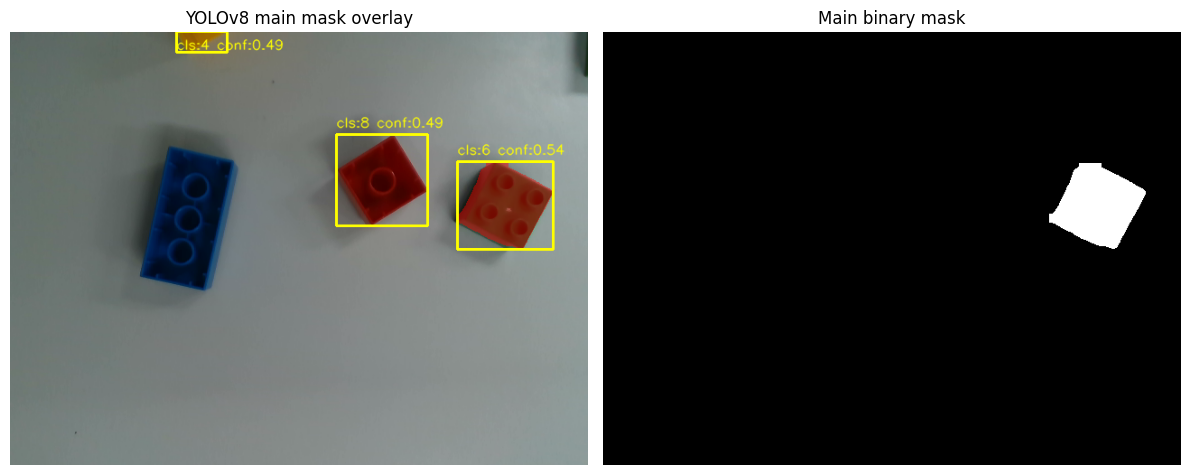

[FLOOR] YOLO mask dilate 영역 제거 후 RANSAC
[FLOOR] sampled points: 17854
[FLOOR] after voxel/outlier: 1042
[FLOOR] normal: [   0.015362 -0.00040953    -0.99988]
[FLOOR] d: 0.2828354709310553
[FLOOR] inliers: 1027 / 1042
[PRE] raw masked points: 4963
[PRE] height filtered points: 4615
[PRE] voxel points: 517
[PRE] statistical outlier points: 479
[PRE] final preprocessed points: 479


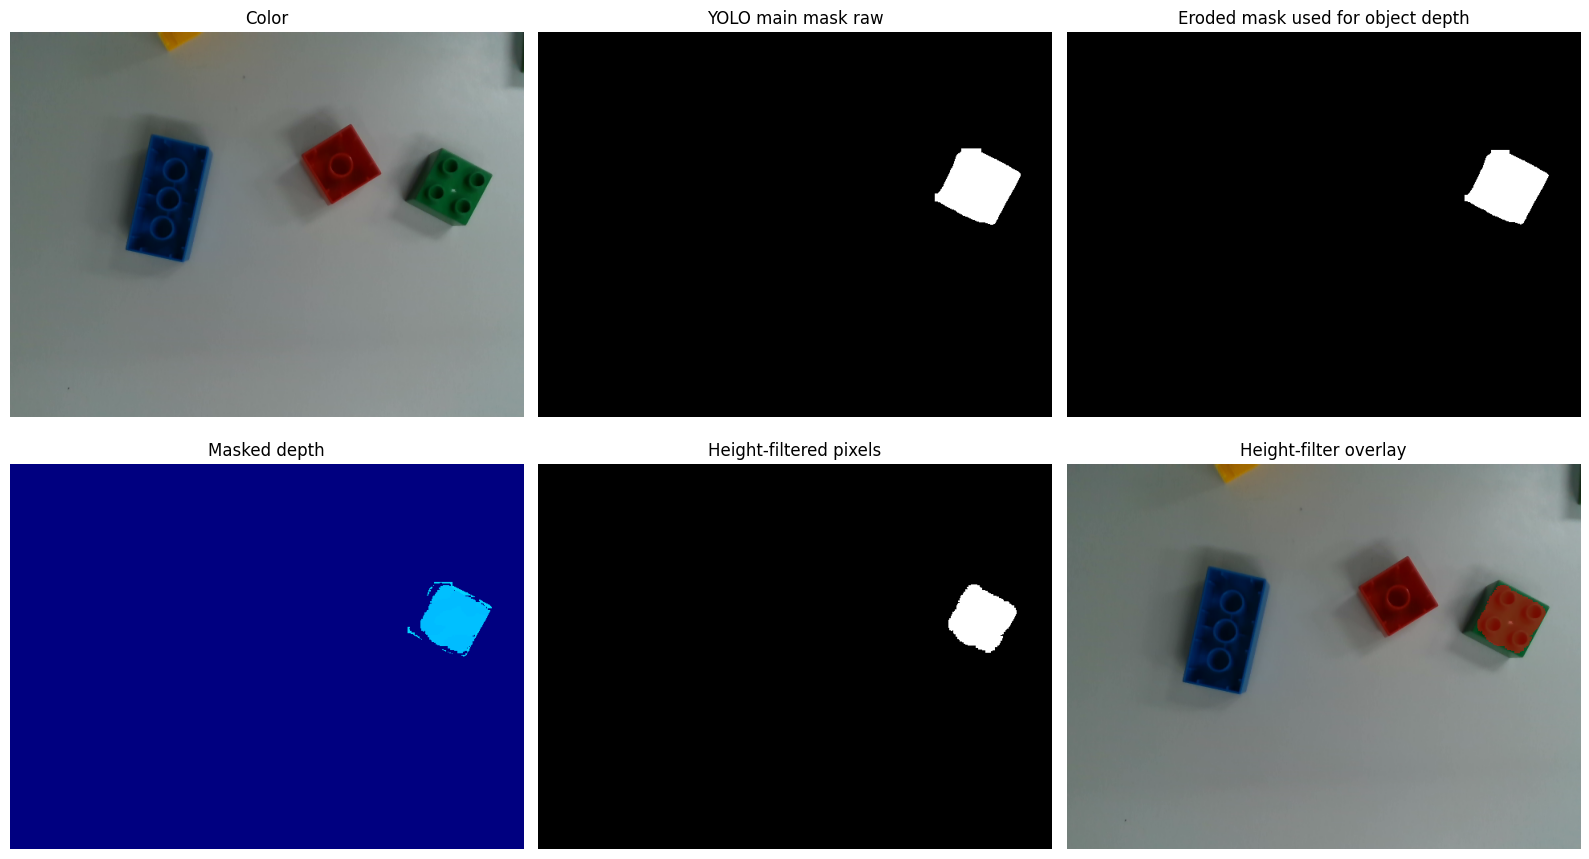

[DBSCAN] cluster count: 1
  label=0, count=479, center=[   0.097495   -0.023883     0.26497]

========== 3D BOUNDING BOX 6D POSE ==========
x  [m]   : 0.096714
y  [m]   : -0.024017
z  [m]   : 0.281864
rx [deg] : 179.288
ry [deg] : -0.518
rz [deg] : 52.405
extent [m] : [   0.035574    0.034922       0.005]
quat xyzw  : [    0.89723      0.4415   0.0068017   0.0035752]
T_cam_obj:
 [[    0.61006     0.79221    0.015362    0.096714]
 [    0.79231    -0.61012 -0.00040953   -0.024017]
 [  0.0090485    0.012422    -0.99988     0.28186]
 [          0           0           0           1]]


[3D STAGE LEGEND]
0: raw_mask   | points=4963 | offset x=0.00 m
1: height     | points=4615 | offset x=0.10 m
2: voxel      | points=517 | offset x=0.20 m
3: stat       | points=479 | offset x=0.30 m
4: final      | points=479 | offset x=0.40 m


In [64]:
# ============================================================
# 실행부
# 카메라 캡처 셀 이후 아래 변수가 있어야 함:
# depth_img, color_img, intrinsics, depth_scale
# ============================================================

required_vars = ["depth_img", "color_img", "intrinsics", "depth_scale"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"{v} 변수가 없습니다. 카메라 캡처 셀을 먼저 실행하세요.")

model_path = Path("../yolo_models/manip_segmentor_0528.pt")

# 보기/안전 옵션
ENABLE_3D_VIEW = True   # 커널 죽으면 False로 바꾸기
MASK_MODE = "largest"   # "largest" 또는 "union"

print("[MODEL]", model_path.resolve())
print("[DEPTH]", depth_img.shape, depth_img.dtype)
print("[COLOR]", color_img.shape, color_img.dtype)
print("[DEPTH SCALE]", depth_scale)


# ------------------------------------------------------------
# 1. YOLOv8 segmentor main mask
# ------------------------------------------------------------
mask_binary, instance_masks, instance_infos, yolo_result = run_yolov8_main_mask(
    color_img=color_img,
    model_path=model_path,
    conf=0.35,
    iou=0.5,
    target_classes=None,
    mask_mode=MASK_MODE,
    yolo_input_is_rgb=True,
)

show_yolo_main_mask_2d(
    color_img=color_img,
    mask_binary=mask_binary,
    instance_infos=instance_infos,
    alpha=0.45,
)


# ------------------------------------------------------------
# 2. YOLO mask를 제외하고 RANSAC 바닥 추정
# ------------------------------------------------------------
floor_result = estimate_floor_plane_by_yolo_mask(
    depth_img=depth_img,
    intrinsics=intrinsics,
    depth_scale=depth_scale,
    yolo_mask=mask_binary,
    min_m=0.10,
    max_m=0.65,
    stride=4,
    max_points=50000,
    mask_dilate_kernel=11,
    mask_dilate_iter=2,
    voxel_size=0.008,
    ransac_dist=0.010,
    num_iter=1000,
)

plane_normal = floor_result["normal"]
plane_d = floor_result["d"]
floor_pcd = floor_result["floor_pcd"]


# ------------------------------------------------------------
# 3. YOLO main mask 기준 포인트클라우드 전처리 단계 생성
# ------------------------------------------------------------
stages = preprocess_object_pointcloud_by_yolo_mask(
    depth_img=depth_img,
    intrinsics=intrinsics,
    depth_scale=depth_scale,
    yolo_mask=mask_binary,
    plane_normal=plane_normal,
    plane_d=plane_d,
    min_m=0.10,
    max_m=0.65,
    mask_erode_kernel=3,
    mask_erode_iter=1,
    height_threshold=0.003,
    stride=1,
    max_points=100000,
    voxel_size=0.0015,
    use_radius_outlier=True,
)


# ------------------------------------------------------------
# 4. 2D 전처리 시각화
# ------------------------------------------------------------
visualize_preprocess_2d(color_img, stages)


# ------------------------------------------------------------
# 5. DBSCAN + PCA OBB + 6D
# ------------------------------------------------------------
clusters, labels = cluster_preprocessed_pcd(
    stages["final_pcd"],
    eps=0.012,
    min_points=15,
    min_cluster_points=30,
)

best_cluster = clusters[0]
best_cluster_pcd = best_cluster["pcd"]
best_cluster_pcd.paint_uniform_color([1.0, 0.0, 0.0])

obb, pose_6d = compute_pca_obb_6d(
    cluster_pcd=best_cluster_pcd,
    plane_normal=plane_normal,
    plane_d=plane_d,
    min_height=0.005,
)

print_pose_6d(pose_6d)


# ------------------------------------------------------------
# 6. 3D 전처리 시각화
# ------------------------------------------------------------
if ENABLE_3D_VIEW:
    visualize_preprocess_3d_stages(
        stages=stages,
        floor_pcd=floor_pcd,
        cluster_pcd=best_cluster_pcd,
        obb=obb,
        pose=pose_6d,
    )